In [ ]:
# %% [markdown]
# # Independent Black Carbon Method Comparison Visualizations
# 
# This notebook creates 6 separate visualizations comparing different BC measurement methods:
# 1. HIPS Fabs vs Aethalometer Attenuation/BCc
# 2. FTIR-BC vs Aethalometer Attenuation/BCc  
# 3. HIPS-derived MAC vs Aethalometer BCc (colored by PM quartiles)
# 4. Correlation matrix of key variables
# 5. Time-series ribbon plot of BC estimates
# 6. Comprehensive correlation heatmap of all species

LOADING ALL DATASETS
Loading Aethalometer data from: /Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Aethelometry Data/Raw/Jacros_MA350_1-min_2022-2024_Cleaned.csv
Loaded 1,095,086 Aethalometer records
Loading FTIR/HIPS data from: /Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/EC-HIPS-Aeth Comparison/Data/Original Data/Combined Database/spartan_ftir_hips.db
Loaded 168 FTIR/HIPS samples
Loading speciation data from: /Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/EC-HIPS-Aeth Comparison/Data/Downloaded Data/SPARTAN/Addis Ababa/FilterBased_ChemSpecPM25_ETAD.csv
Loaded 188 speciation samples

Merging datasets on overlapping dates...
FTIR-Speciation merge: 162 samples
Final merged dataset: 150 samples with overlapping data

Merged dataset columns: ['fil

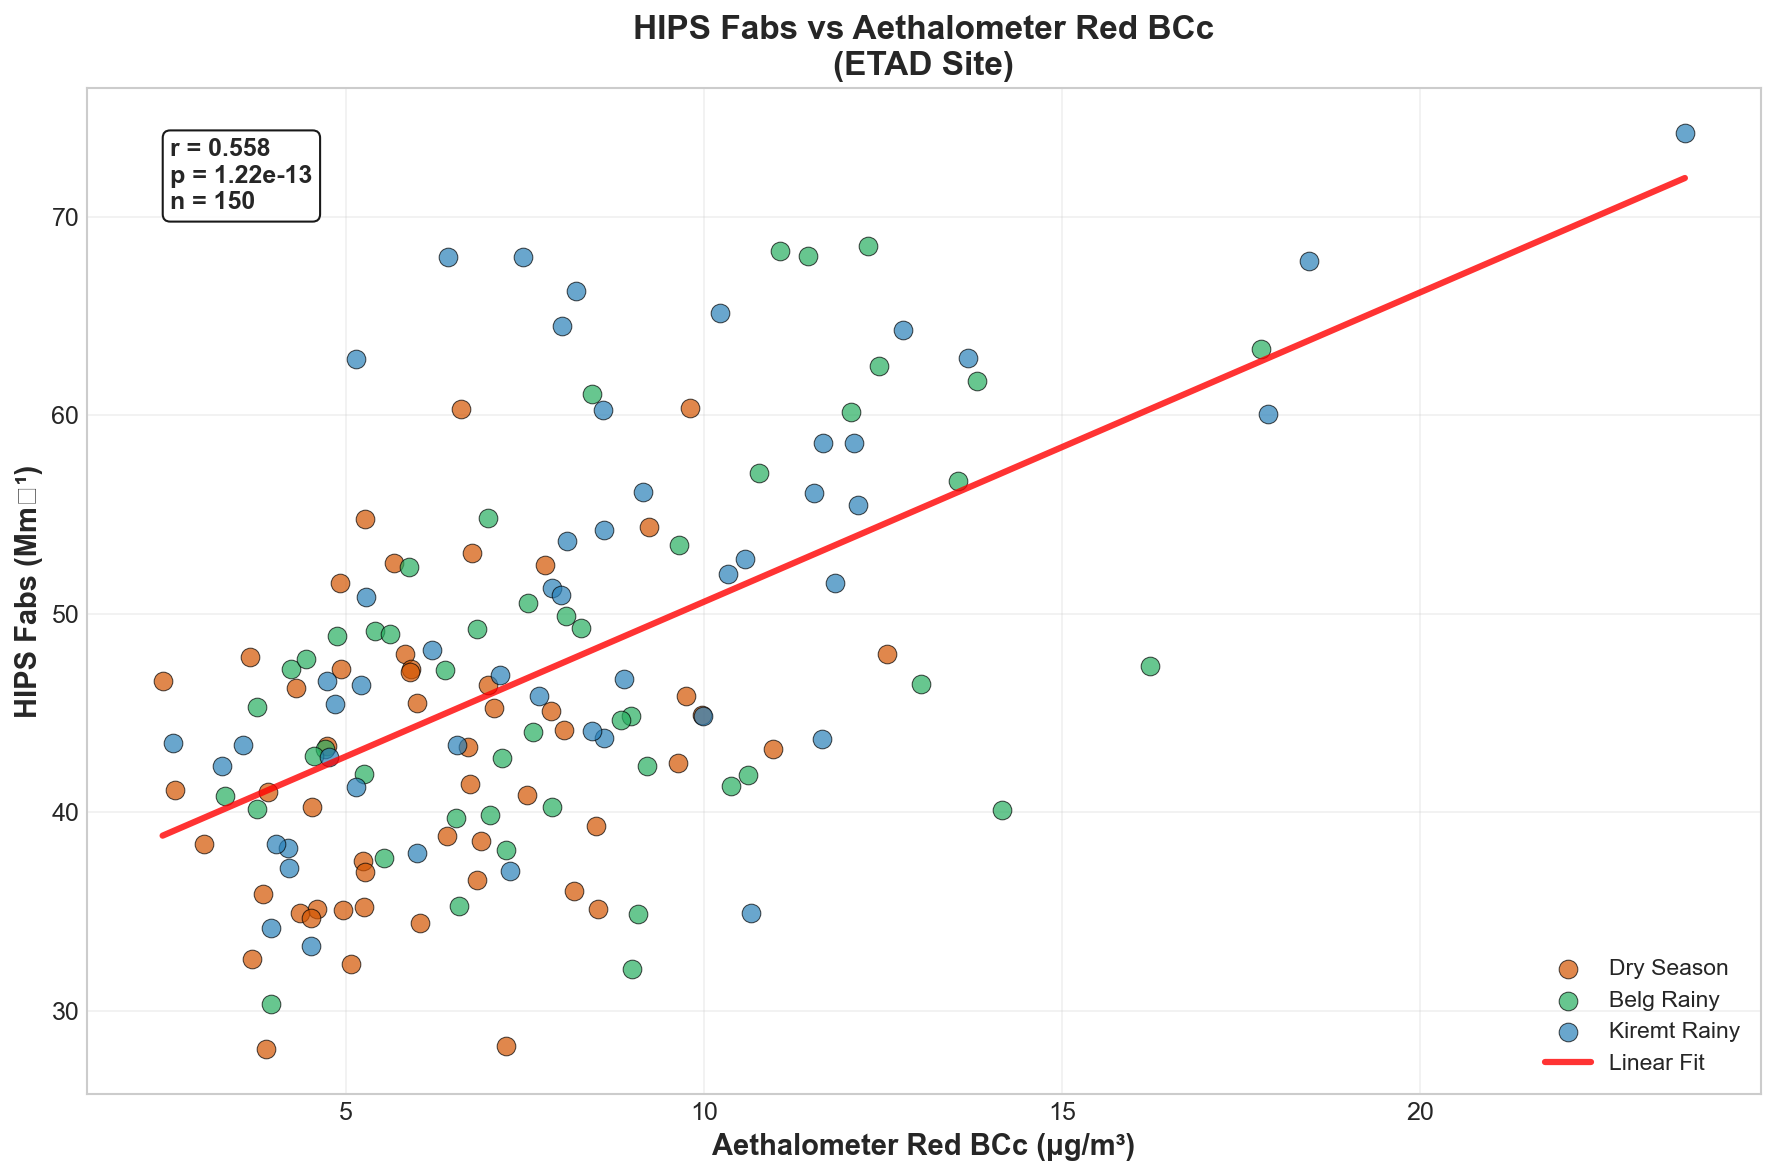

✅ Plot 1 Complete: HIPS Fabs vs Aethalometer Red BCc


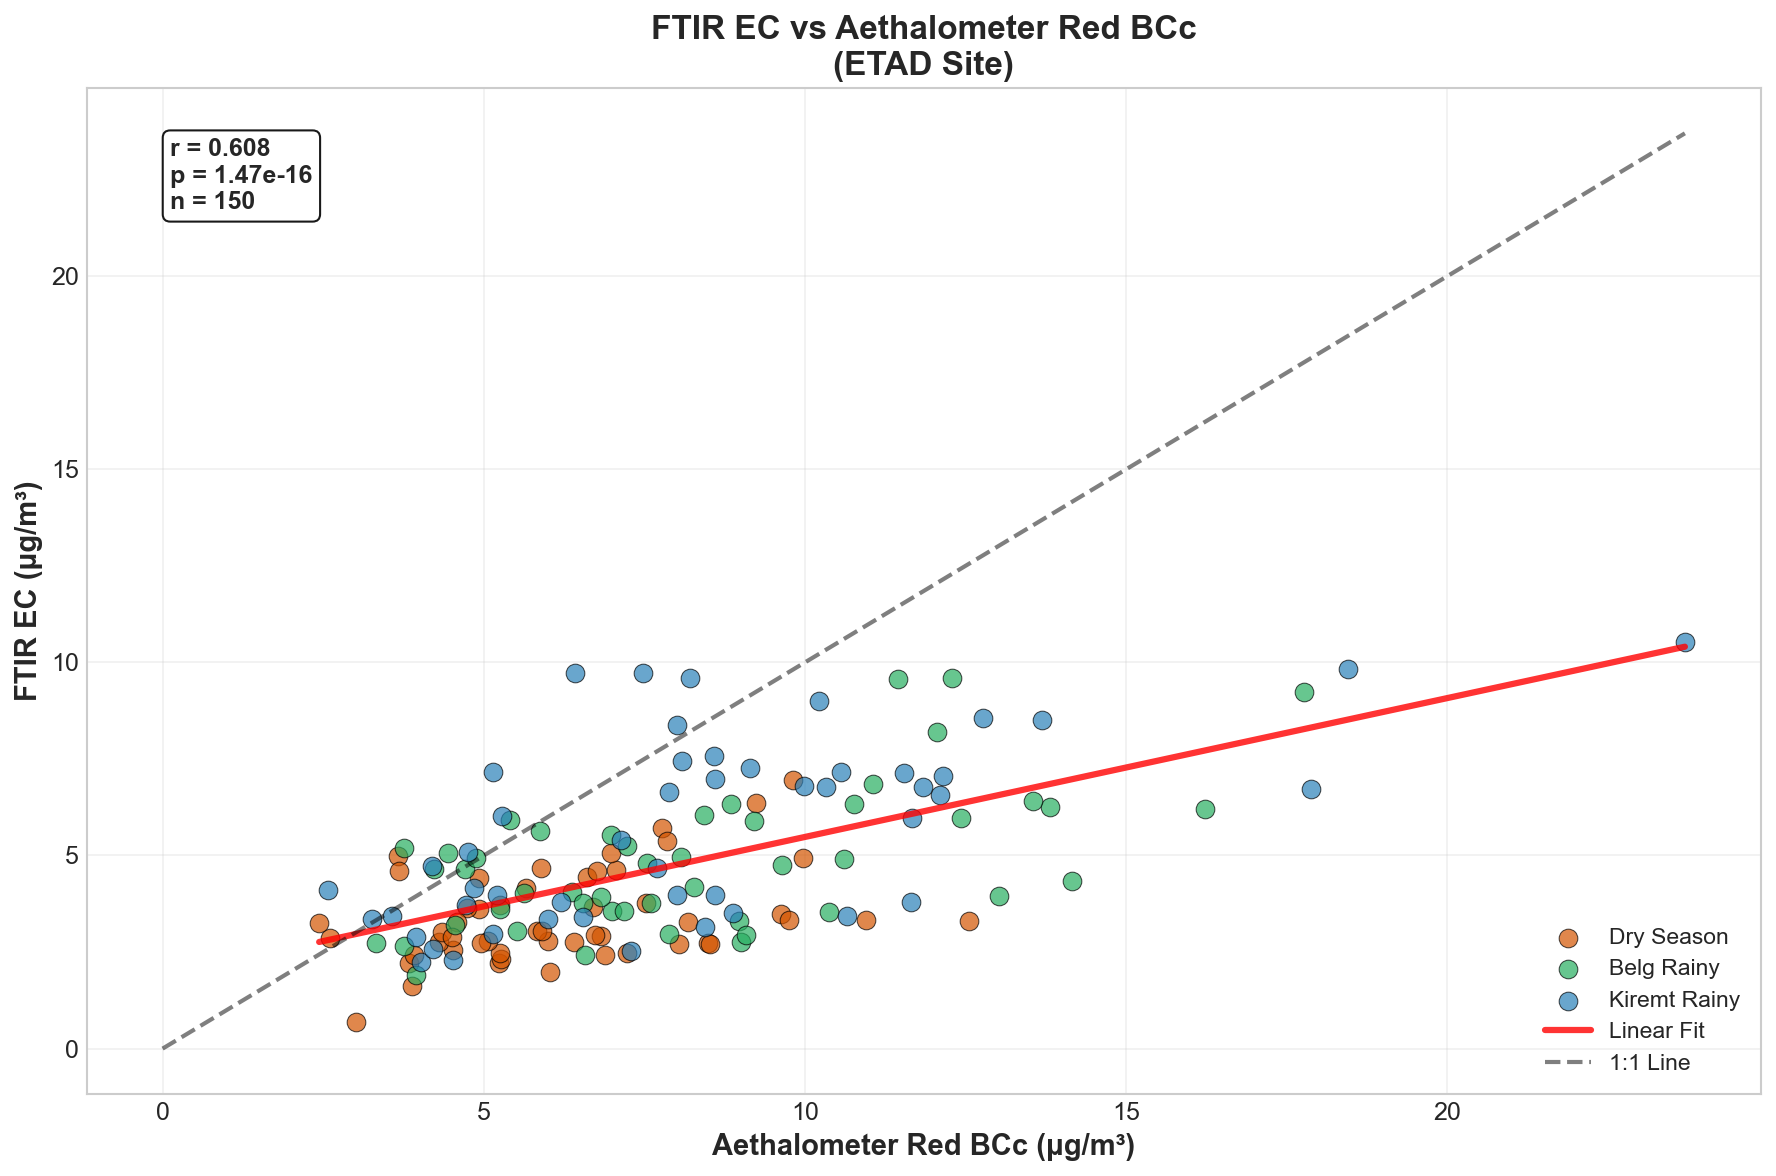

✅ Plot 2 Complete: FTIR EC vs Aethalometer Red BCc


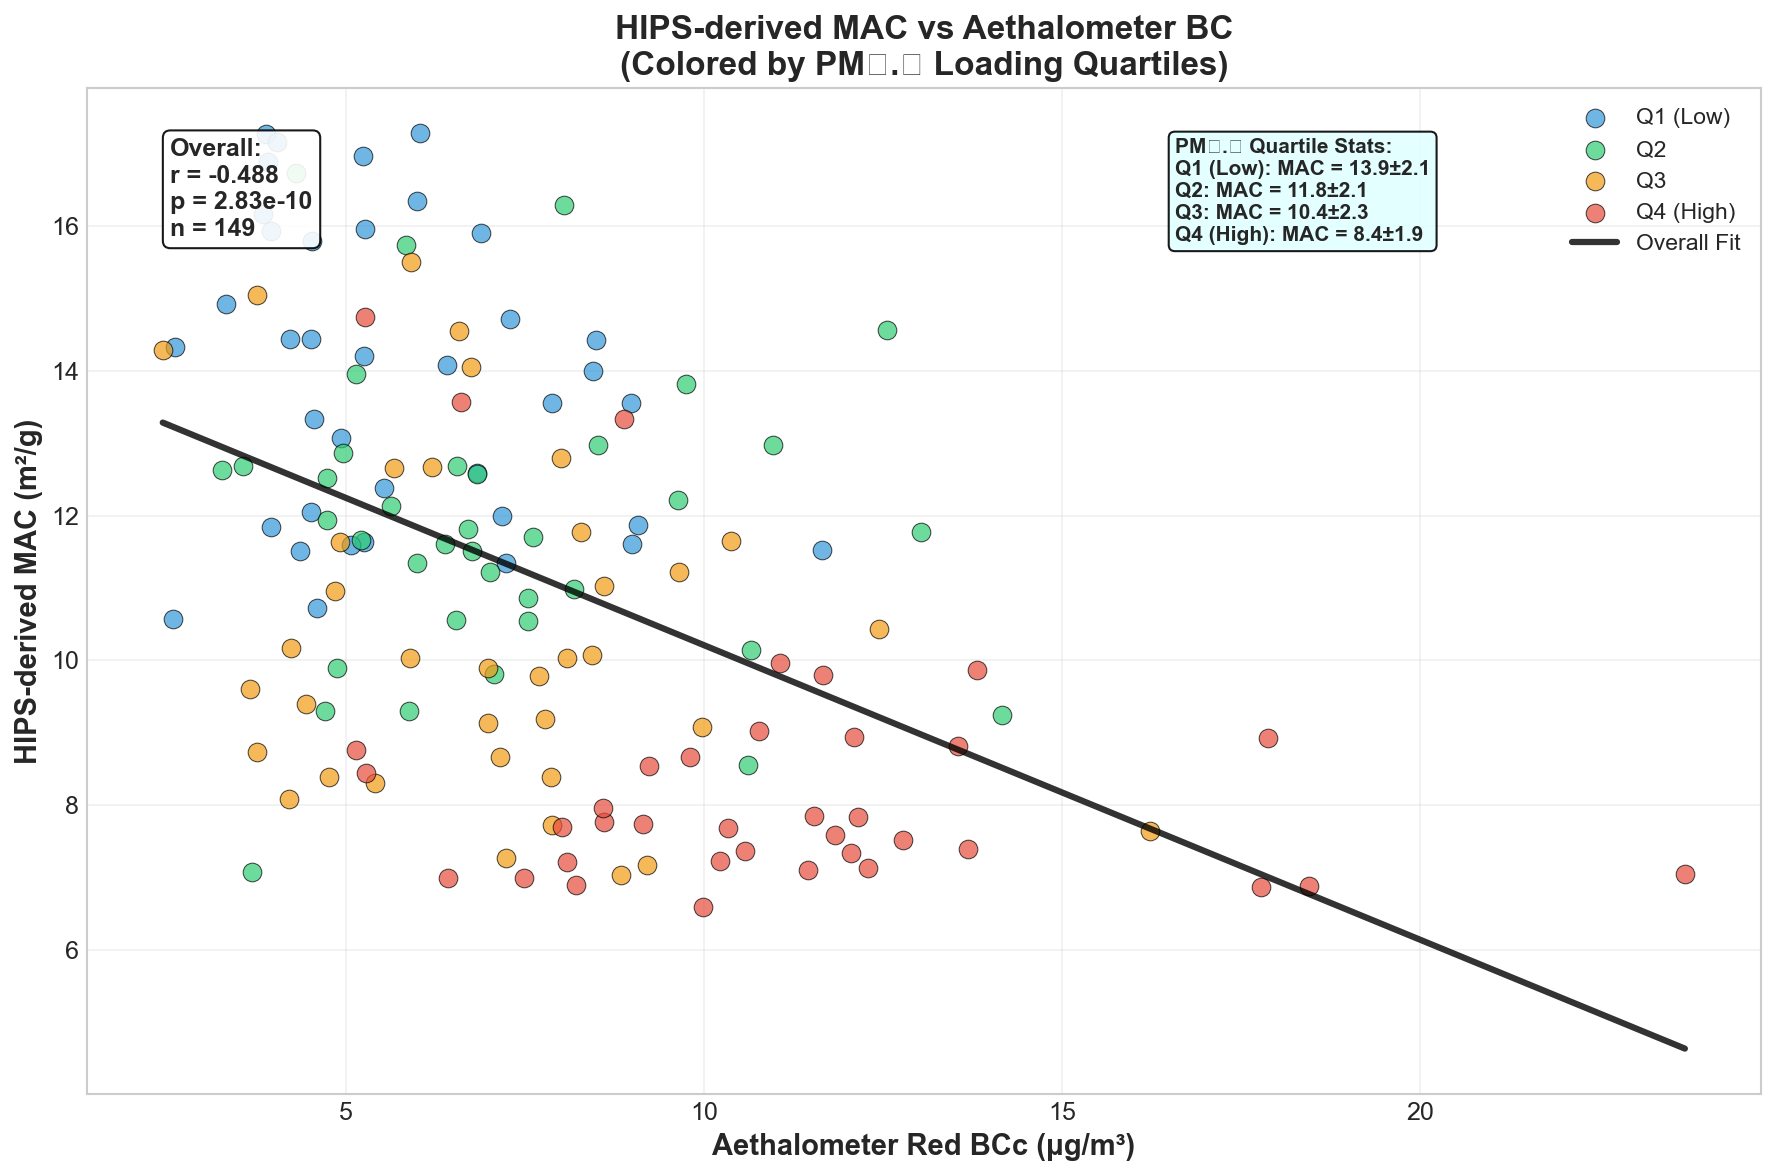

✅ Plot 3 Complete: MAC vs Aethalometer (PM quartiles)


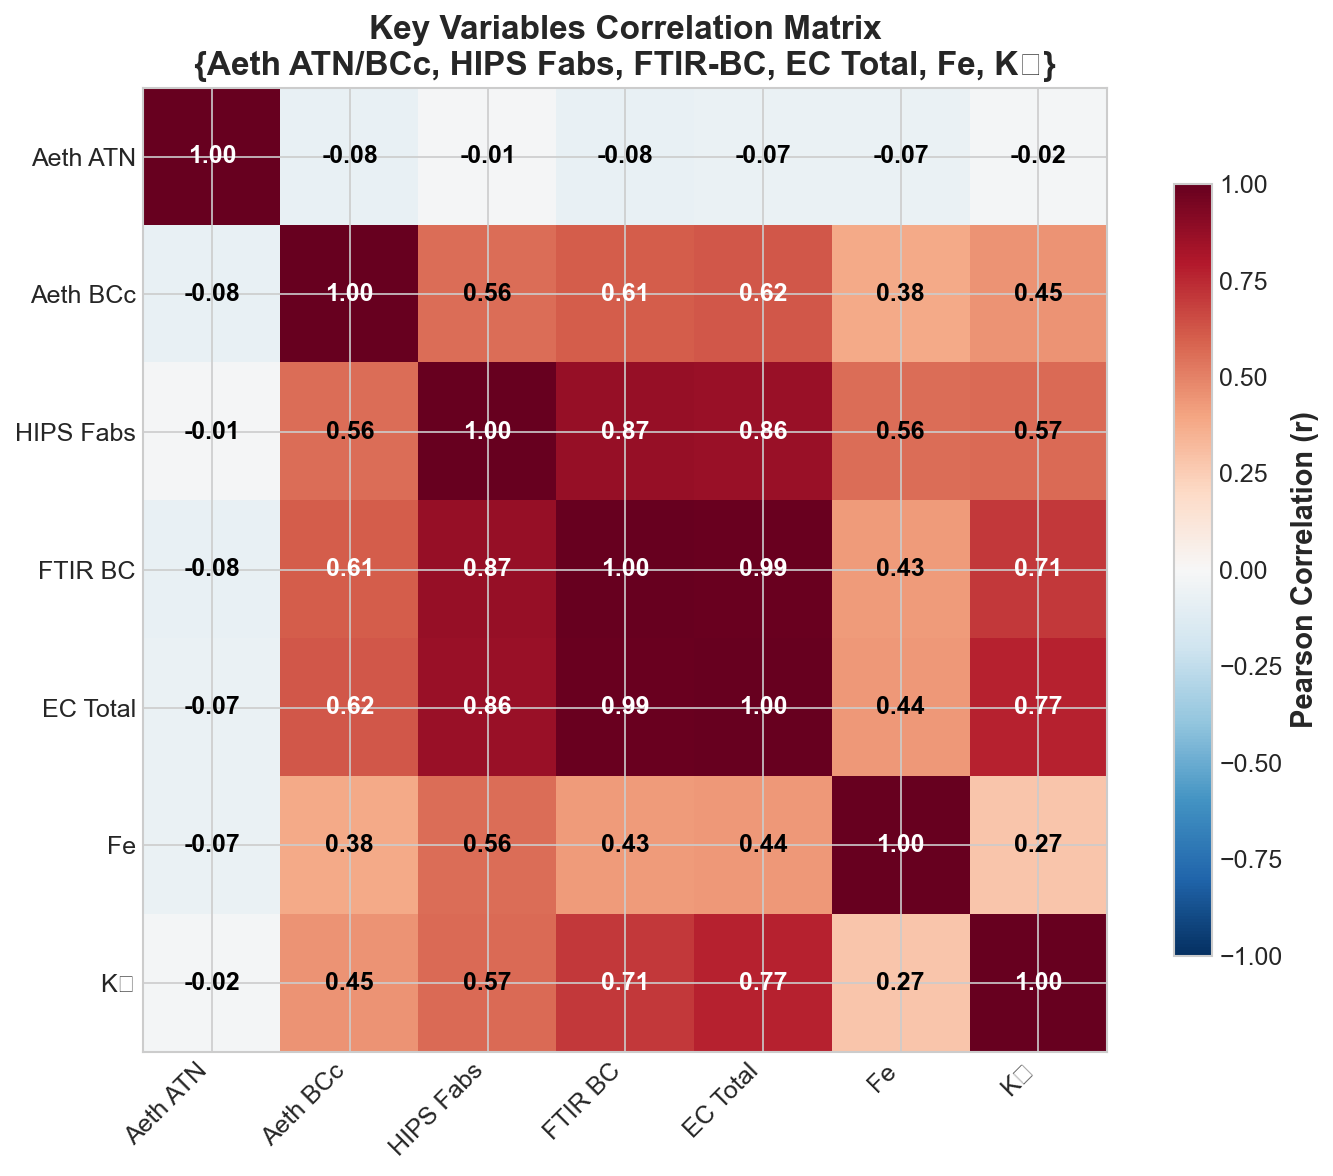

✅ Plot 4 Complete: Key Variables Correlation Matrix

Key Correlations:
  FTIR BC ↔ EC Total: r = 0.986
  HIPS Fabs ↔ FTIR BC: r = 0.871
  HIPS Fabs ↔ EC Total: r = 0.862
  EC Total ↔ K⁺: r = 0.772
  FTIR BC ↔ K⁺: r = 0.708


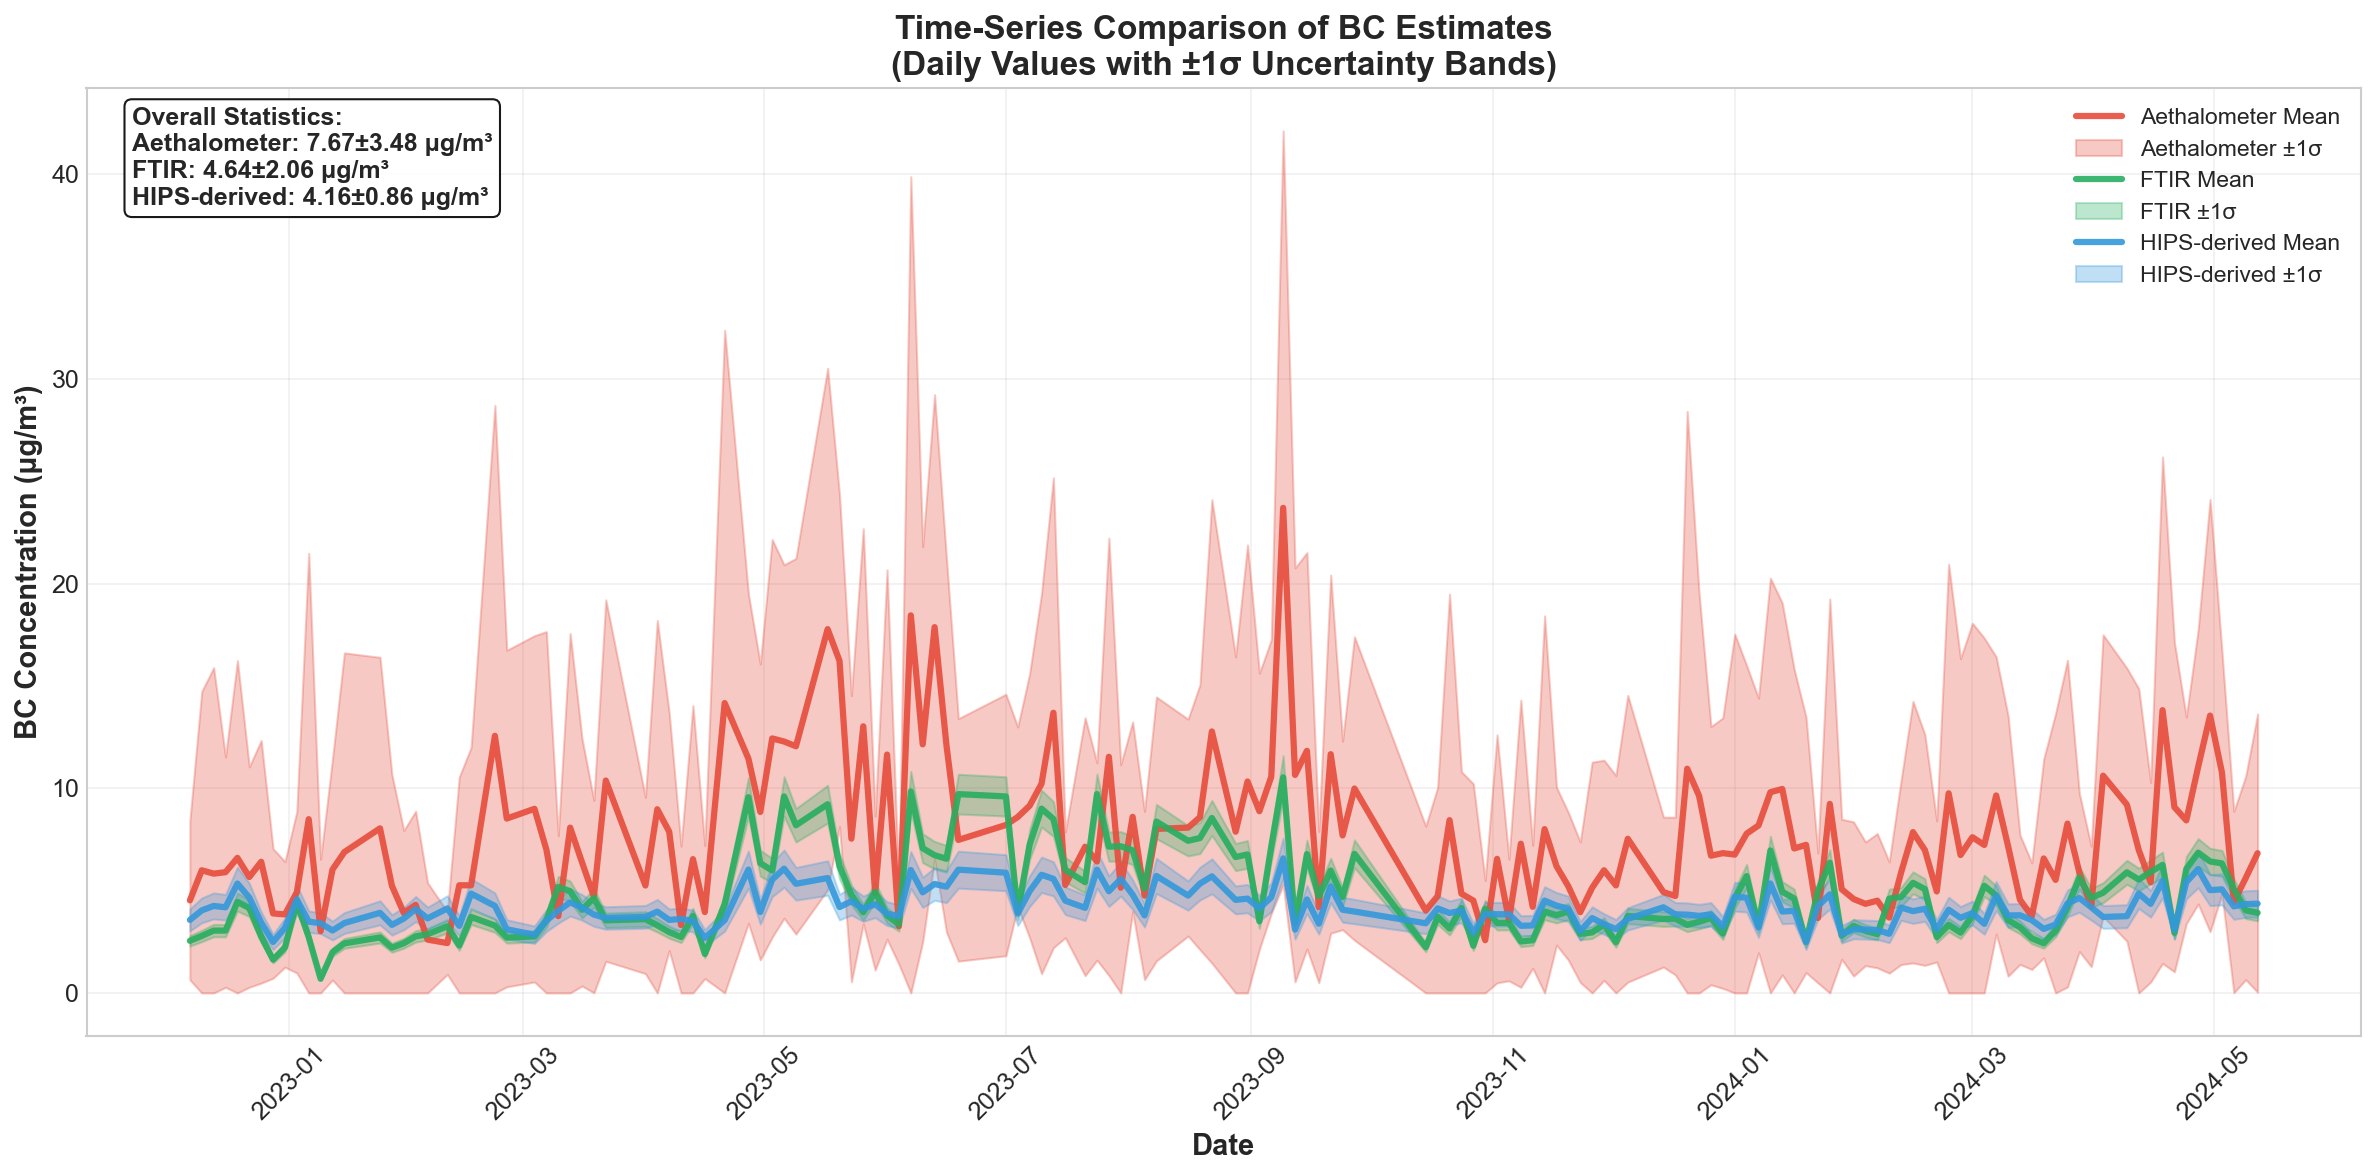

✅ Plot 5 Complete: BC Time-Series Ribbon Plot


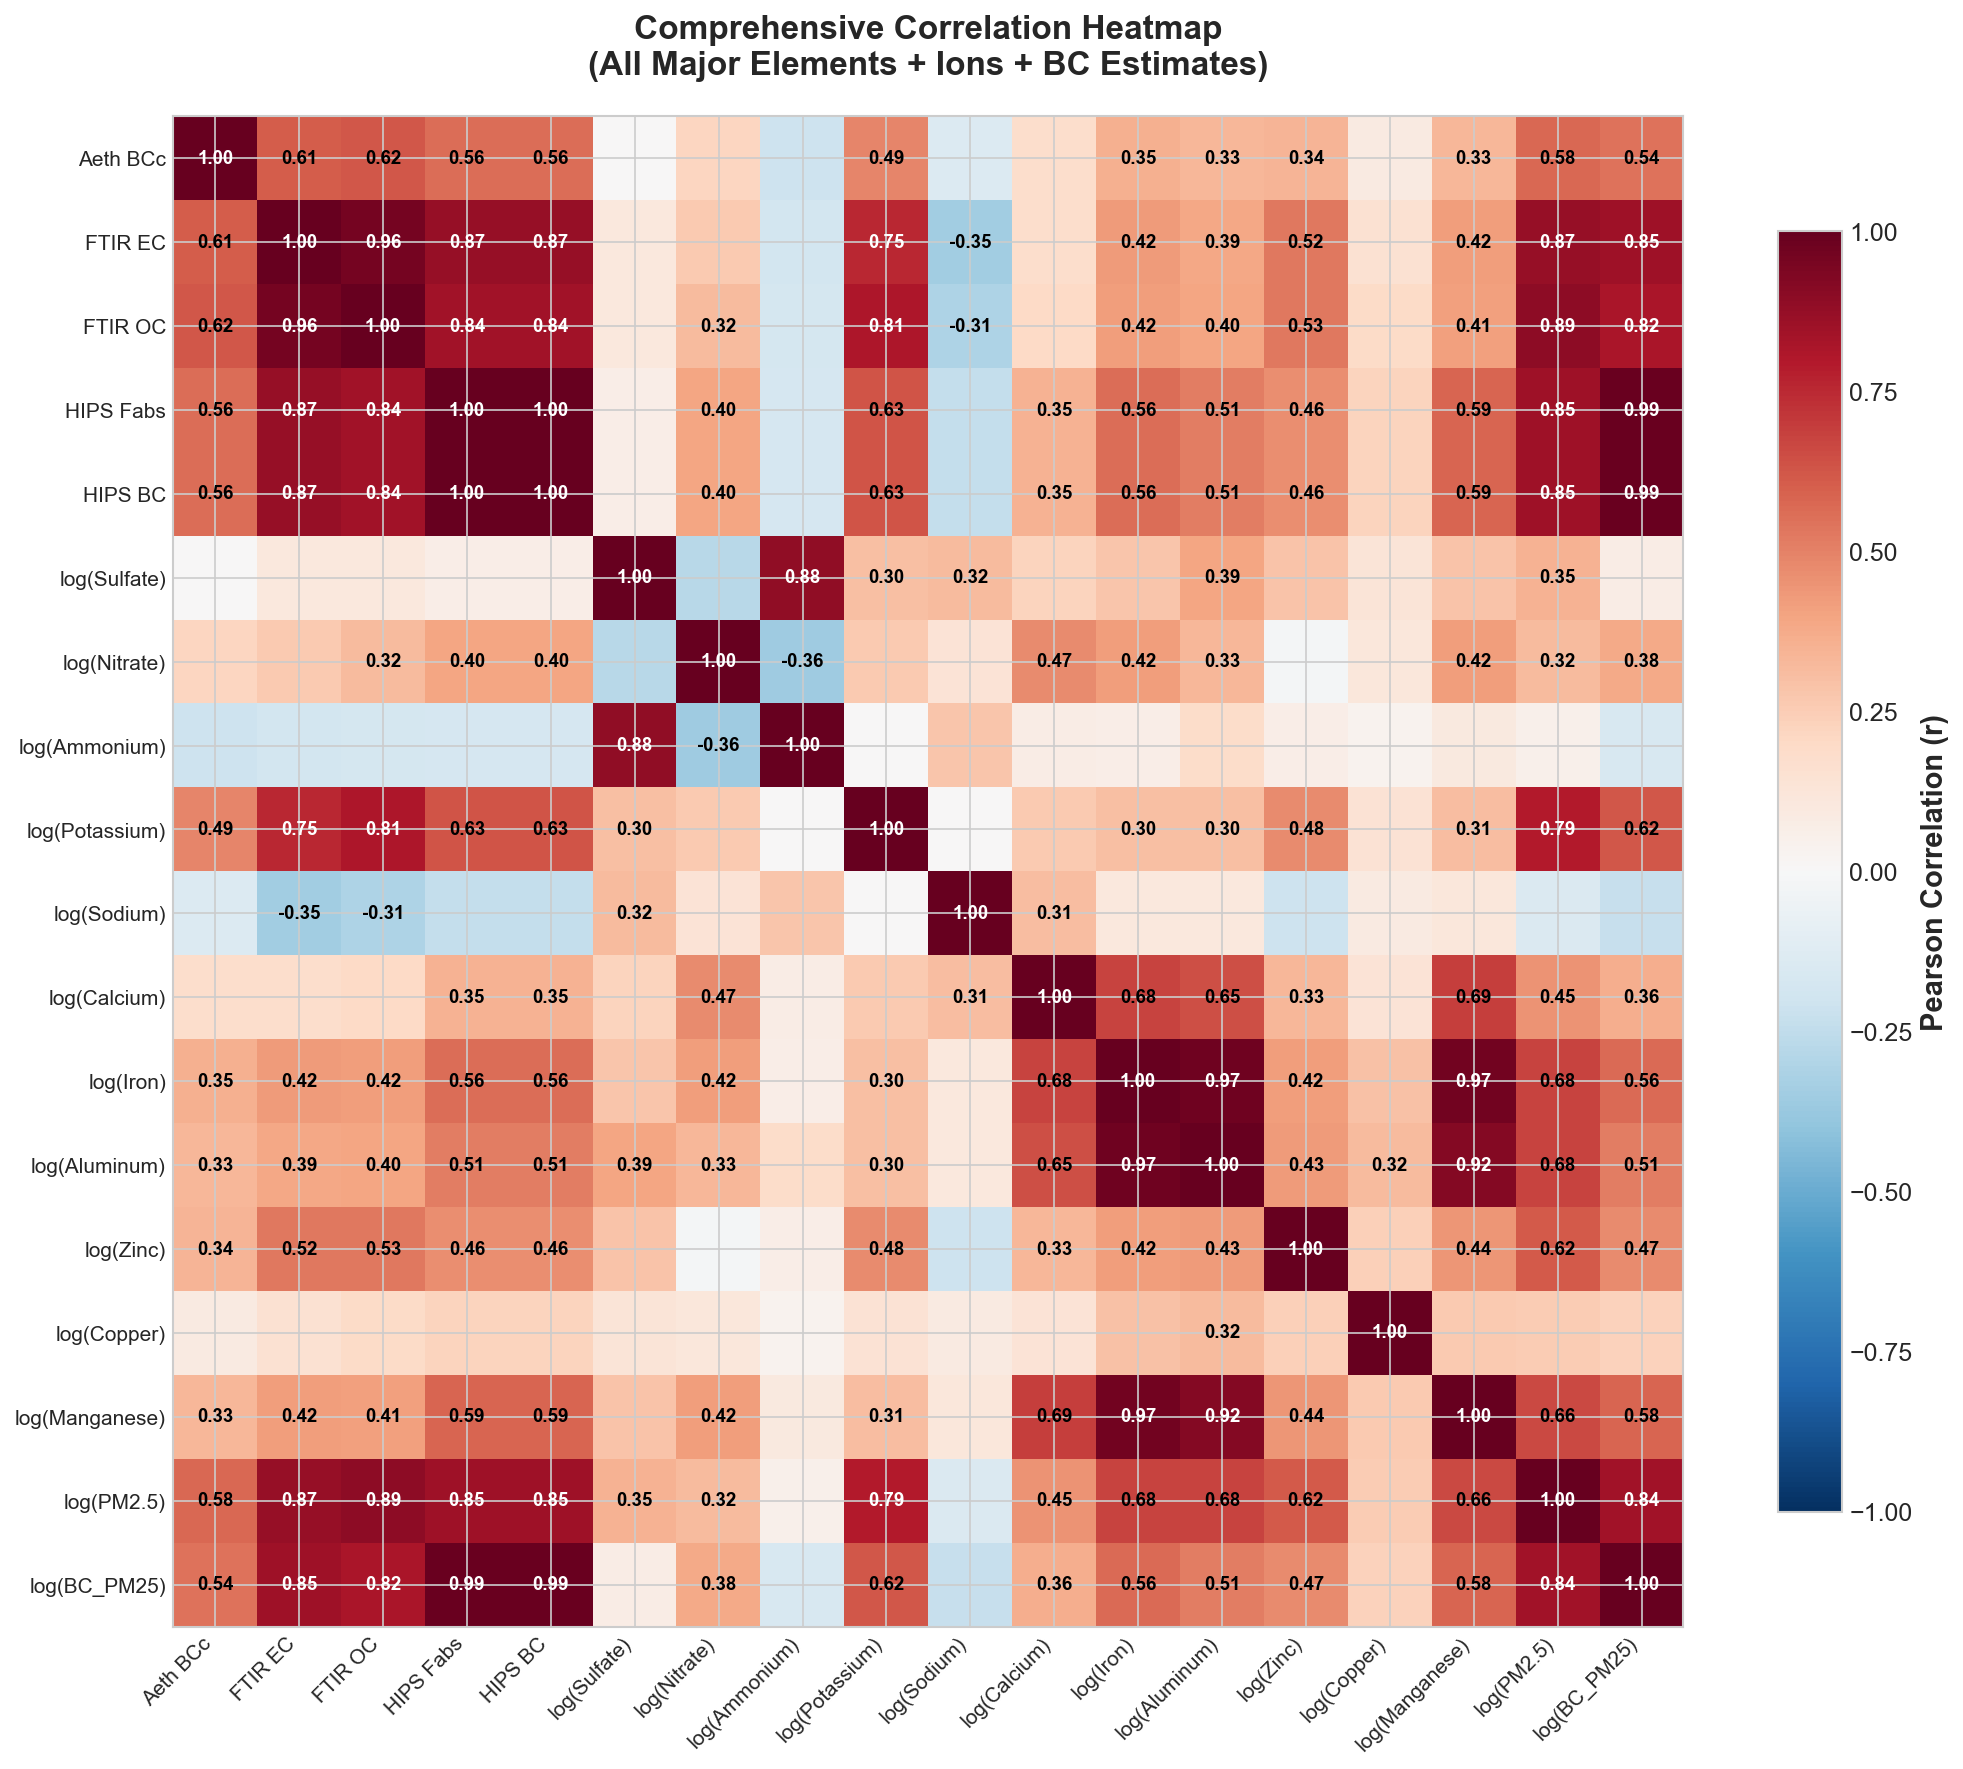

✅ Plot 6 Complete: Comprehensive Correlation Heatmap

Analyzed 18 variables with sufficient data

Strongest Inter-Variable Correlations (|r| > 0.7):
  HIPS Fabs ↔ HIPS BC: r = 1.000
  HIPS BC ↔ log(BC_PM25): r = 0.991
  HIPS Fabs ↔ log(BC_PM25): r = 0.991
  log(Iron) ↔ log(Aluminum): r = 0.973
  log(Iron) ↔ log(Manganese): r = 0.967
  FTIR EC ↔ FTIR OC: r = 0.959
  log(Aluminum) ↔ log(Manganese): r = 0.921
  FTIR OC ↔ log(PM2.5): r = 0.893
  log(Sulfate) ↔ log(Ammonium): r = 0.883
  FTIR EC ↔ HIPS Fabs: r = 0.871
  FTIR EC ↔ HIPS BC: r = 0.871
  FTIR EC ↔ log(PM2.5): r = 0.869
  FTIR EC ↔ log(BC_PM25): r = 0.848
  HIPS BC ↔ log(PM2.5): r = 0.847
  HIPS Fabs ↔ log(PM2.5): r = 0.847
  FTIR OC ↔ HIPS BC: r = 0.841
  FTIR OC ↔ HIPS Fabs: r = 0.841
  log(PM2.5) ↔ log(BC_PM25): r = 0.841
  FTIR OC ↔ log(BC_PM25): r = 0.816
  FTIR OC ↔ log(Potassium): r = 0.811
  log(Potassium) ↔ log(PM2.5): r = 0.792
  FTIR EC ↔ log(Potassium): r = 0.754

Moderate Correlations (0.5 < |r| ≤ 0.7): 0
Weak Corre

In [6]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy.stats import pearsonr
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 18
})

# %% [markdown]
# ## Data Loading Functions
# Using the existing data loading infrastructure

# %%
def load_aethalometer_data(file_path, convert_to_ug=True):
    """Load and prepare Aethalometer data with unit conversion"""
    print(f"Loading Aethalometer data from: {file_path}")
    
    try:
        df = pd.read_csv(file_path)
        
        # Parse datetime
        if 'Date local (yyyy/MM/dd)' in df.columns and 'Time local (hh:mm:ss)' in df.columns:
            try:
                df['datetime_local'] = pd.to_datetime(
                    df['Date local (yyyy/MM/dd)'] + ' ' + df['Time local (hh:mm:ss)'],
                    format='mixed'
                )
                df.set_index('datetime_local', inplace=True)
                df.index = df.index.floor('min')
                df.sort_index(inplace=True)
            except Exception as e:
                print(f"Error parsing datetime: {e}")
                return None
        
        # Convert BC values from ng/m³ to μg/m³ if requested
        if convert_to_ug:
            bc_columns = [col for col in df.columns if 'BC' in col and col != 'BC_PM25']
            for col in bc_columns:
                if col in df.columns:
                    df[col] = df[col] / 1000
        
        print(f"Loaded {len(df):,} Aethalometer records")
        return df
        
    except Exception as e:
        print(f"Error loading Aethalometer data: {e}")
        return None

def load_ftir_hips_data(db_path):
    """Load FTIR/HIPS data from SQLite database"""
    print(f"Loading FTIR/HIPS data from: {db_path}")
    
    try:
        conn = sqlite3.connect(db_path)
        
        query = """
        SELECT 
            f.filter_id, f.sample_date, f.site_code,
            m.ec_ftir, m.oc_ftir, m.fabs, m.volume_m3
        FROM filters f
        JOIN ftir_sample_measurements m USING(filter_id)
        WHERE f.site_code = 'ETAD'
        ORDER BY f.sample_date
        """
        
        df = pd.read_sql_query(query, conn)
        df['sample_date'] = pd.to_datetime(df['sample_date'])
        conn.close()
        
        print(f"Loaded {len(df)} FTIR/HIPS samples")
        return df
        
    except Exception as e:
        print(f"Error loading FTIR/HIPS data: {e}")
        return None

def load_speciation_data(csv_path):
    """Load chemical speciation data"""
    print(f"Loading speciation data from: {csv_path}")
    
    try:
        df = pd.read_csv(csv_path, skiprows=3)
        df = df[df['Site_Code'] == 'ETAD'].copy()
        
        # Create datetime
        def create_timestamp(row):
            try:
                return pd.Timestamp(
                    year=int(row['Start_Year_local']),
                    month=int(row['Start_Month_local']),
                    day=int(row['Start_Day_local']),
                    hour=int(row['Start_hour_local'])
                )
            except:
                return pd.NaT
        
        df['Start_Date'] = df.apply(create_timestamp, axis=1)
        df = df[df['Start_Date'].notna()].copy()
        
        # Parameter mapping
        parameter_mapping = {
            28101: 'PM25_mass',
            28202: 'BC_PM25',
            28401: 'Sulfate_Ion',
            28402: 'Nitrate_Ion',
            28801: 'Sodium_Ion',
            28802: 'Ammonium_Ion',
            28803: 'Potassium_Ion',
            28805: 'Calcium_Ion',
            28908: 'Iron',
            28902: 'Aluminum',
            28912: 'Zinc',
            28911: 'Copper',
            28907: 'Manganese'
        }
        
        df['Parameter_Name_Clean'] = df['Parameter_Code'].map(parameter_mapping)
        df_mapped = df[df['Parameter_Name_Clean'].notna()].copy()
        
        # Convert ng/m³ to μg/m³ for metals
        ng_to_ug_species = ['Iron', 'Aluminum', 'Zinc', 'Copper', 'Manganese']
        
        # Pivot to wide format
        speciation_wide = df_mapped.pivot_table(
            index=['Filter_ID', 'Start_Date'],
            columns='Parameter_Name_Clean',
            values='Value',
            aggfunc='first'
        ).reset_index()
        
        speciation_wide.columns.name = None
        
        # Unit conversions
        for species in ng_to_ug_species:
            if species in speciation_wide.columns:
                speciation_wide[species] = speciation_wide[species] / 1000
        
        print(f"Loaded {len(speciation_wide)} speciation samples")
        return speciation_wide
        
    except Exception as e:
        print(f"Error loading speciation data: {e}")
        return None

# %% [markdown]
# ## Data Loading and Preparation

# %%
# File paths - UPDATE THESE TO YOUR ACTUAL PATHS

AETHALOMETER_PATH = "/Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Aethelometry Data/Raw/Jacros_MA350_1-min_2022-2024_Cleaned.csv"
DB_PATH = "/Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/EC-HIPS-Aeth Comparison/Data/Original Data/Combined Database/spartan_ftir_hips.db"
SPECIATION_PATH = "/Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/EC-HIPS-Aeth Comparison/Data/Downloaded Data/SPARTAN/Addis Ababa/FilterBased_ChemSpecPM25_ETAD.csv"

# Load all datasets
print("="*60)
print("LOADING ALL DATASETS")
print("="*60)

# Load aethalometer data
aeth_df = load_aethalometer_data(AETHALOMETER_PATH)

# Load FTIR/HIPS data
ftir_df = load_ftir_hips_data(DB_PATH)

# Load speciation data
spec_df = load_speciation_data(SPECIATION_PATH)

# %% [markdown]
# ## Data Merging and Alignment

# %%
def merge_all_datasets(aeth_df, ftir_df, spec_df):
    """Merge all three datasets on overlapping dates"""
    print("\nMerging datasets on overlapping dates...")
    
    if any(df is None for df in [aeth_df, ftir_df, spec_df]):
        print("One or more datasets failed to load")
        return None
    
    # Prepare FTIR data for merging
    ftir_merge = ftir_df.copy()
    ftir_merge['date_key'] = ftir_merge['sample_date'].dt.date
    
    # Prepare speciation data for merging  
    spec_merge = spec_df.copy()
    spec_merge['date_key'] = spec_merge['Start_Date'].dt.date
    
    # Merge FTIR and speciation
    merged = pd.merge(ftir_merge, spec_merge, on='date_key', how='inner', suffixes=('_ftir', '_spec'))
    print(f"FTIR-Speciation merge: {len(merged)} samples")
    
    if len(merged) == 0:
        print("No overlapping dates between FTIR and speciation data")
        return None
    
    # For each merged sample, find corresponding aethalometer data (24h periods)
    final_data = []
    
    for _, row in merged.iterrows():
        sample_date = row['sample_date']
        
        # Define 24h period (9am to 9am next day, matching filter collection)
        period_start = sample_date.normalize() + pd.Timedelta(hours=9) - pd.Timedelta(days=1)
        period_end = period_start + pd.Timedelta(days=1)
        
        # Extract aethalometer data for this period
        aeth_period = aeth_df.loc[period_start:period_end]
        
        if len(aeth_period) > 100:  # Minimum data requirement
            # Calculate aethalometer statistics
            aeth_stats = {}
            
            # Check for Red channel data (prioritize BCc, then attenuation)
            if 'Red BCc' in aeth_period.columns:
                red_data = aeth_period['Red BCc'].dropna()
                if len(red_data) > 0:
                    aeth_stats['red_bc_mean'] = red_data.mean()
                    aeth_stats['red_bc_std'] = red_data.std()
                    aeth_stats['red_bc_count'] = len(red_data)
            
            if 'Red ATN1' in aeth_period.columns:
                atn_data = aeth_period['Red ATN1'].dropna()
                if len(atn_data) > 0:
                    aeth_stats['red_atn_mean'] = atn_data.mean()
                    aeth_stats['red_atn_std'] = atn_data.std()
            
            # Add to final dataset
            if aeth_stats:
                row_dict = row.to_dict()
                row_dict.update(aeth_stats)
                row_dict['period_start'] = period_start
                row_dict['period_end'] = period_end
                final_data.append(row_dict)
    
    if final_data:
        result_df = pd.DataFrame(final_data)
        print(f"Final merged dataset: {len(result_df)} samples with overlapping data")
        return result_df
    else:
        print("No samples with sufficient overlapping aethalometer data")
        return None

# Merge all datasets
merged_df = merge_all_datasets(aeth_df, ftir_df, spec_df)

if merged_df is not None:
    print(f"\nMerged dataset columns: {list(merged_df.columns)}")
    print(f"Date range: {merged_df['sample_date'].min()} to {merged_df['sample_date'].max()}")
else:
    print("Failed to create merged dataset")

# %% [markdown]
# ## Visualization 1: HIPS Fabs vs Aethalometer Attenuation/BCc

# %%
def plot_hips_vs_aethalometer(merged_df):
    """Plot HIPS Fabs vs Aethalometer measurements"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Determine which aethalometer measurement to use
    if 'red_bc_mean' in merged_df.columns:
        x_data = merged_df['red_bc_mean']
        x_label = 'Aethalometer Red BCc (μg/m³)'
        x_name = 'Red BCc'
    elif 'red_atn_mean' in merged_df.columns:
        x_data = merged_df['red_atn_mean']
        x_label = 'Aethalometer Red Attenuation'
        x_name = 'Red ATN'
    else:
        print("No suitable aethalometer data found")
        return
    
    y_data = merged_df['fabs']
    
    # Remove NaN values
    mask = x_data.notna() & y_data.notna()
    x_clean = x_data[mask]
    y_clean = y_data[mask]
    
    if len(x_clean) < 3:
        print("Insufficient data for plotting")
        return
    
    # Check for seasonal data
    if 'Start_Date' in merged_df.columns:
        # Create seasons based on month
        dates = merged_df.loc[mask, 'Start_Date']
        months = dates.dt.month
        
        def get_season(month):
            if month in [12, 1, 2]:
                return 'Dry Season'
            elif month in [3, 4, 5]:
                return 'Belg Rainy'
            else:
                return 'Kiremt Rainy'
        
        seasons = months.apply(get_season)
        
        # Plot by season if we have seasonal data
        if len(seasons.unique()) > 1:
            season_colors = {'Dry Season': '#d35400', 'Belg Rainy': '#27ae60', 'Kiremt Rainy': '#2980b9'}
            
            for season in seasons.unique():
                season_mask = seasons == season
                if season_mask.sum() > 0:
                    ax.scatter(x_clean[season_mask], y_clean[season_mask], 
                              c=season_colors.get(season, 'gray'), alpha=0.7, s=80,
                              label=season, edgecolors='black', linewidth=0.5)
        else:
            ax.scatter(x_clean, y_clean, alpha=0.7, s=80, color='blue', 
                      edgecolors='black', linewidth=0.5)
    else:
        ax.scatter(x_clean, y_clean, alpha=0.7, s=80, color='blue', 
                  edgecolors='black', linewidth=0.5)
    
    # Add regression line
    if len(x_clean) > 1:
        z = np.polyfit(x_clean, y_clean, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
        ax.plot(x_line, p(x_line), 'red', linewidth=3, alpha=0.8, label='Linear Fit')
        
        # Calculate correlation
        r, p_val = pearsonr(x_clean, y_clean)
        
        # Add statistics box
        stats_text = f'r = {r:.3f}\np = {p_val:.2e}\nn = {len(x_clean)}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                fontweight='bold', va='top')
    
    ax.set_xlabel(x_label, fontweight='bold')
    ax.set_ylabel('HIPS Fabs (Mm⁻¹)', fontweight='bold')
    ax.set_title(f'HIPS Fabs vs Aethalometer {x_name}\n(ETAD Site)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    if len(ax.get_legend_handles_labels()[0]) > 0:
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Plot 1 Complete: HIPS Fabs vs Aethalometer {x_name}")

# Create the plot
plot_hips_vs_aethalometer(merged_df)

# %% [markdown]
# ## Visualization 2: FTIR-BC vs Aethalometer Attenuation/BCc

# %%
def plot_ftir_vs_aethalometer(merged_df):
    """Plot FTIR-BC vs Aethalometer measurements"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Determine which aethalometer measurement to use
    if 'red_bc_mean' in merged_df.columns:
        x_data = merged_df['red_bc_mean']
        x_label = 'Aethalometer Red BCc (μg/m³)'
        x_name = 'Red BCc'
    elif 'red_atn_mean' in merged_df.columns:
        x_data = merged_df['red_atn_mean']
        x_label = 'Aethalometer Red Attenuation'
        x_name = 'Red ATN'
    else:
        print("No suitable aethalometer data found")
        return
    
    y_data = merged_df['ec_ftir']
    
    # Remove NaN values
    mask = x_data.notna() & y_data.notna()
    x_clean = x_data[mask]
    y_clean = y_data[mask]
    
    if len(x_clean) < 3:
        print("Insufficient data for plotting")
        return
    
    # Check for seasonal data
    if 'Start_Date' in merged_df.columns:
        dates = merged_df.loc[mask, 'Start_Date']
        months = dates.dt.month
        
        def get_season(month):
            if month in [12, 1, 2]:
                return 'Dry Season'
            elif month in [3, 4, 5]:
                return 'Belg Rainy'
            else:
                return 'Kiremt Rainy'
        
        seasons = months.apply(get_season)
        
        # Plot by season if we have seasonal data
        if len(seasons.unique()) > 1:
            season_colors = {'Dry Season': '#d35400', 'Belg Rainy': '#27ae60', 'Kiremt Rainy': '#2980b9'}
            
            for season in seasons.unique():
                season_mask = seasons == season
                if season_mask.sum() > 0:
                    ax.scatter(x_clean[season_mask], y_clean[season_mask], 
                              c=season_colors.get(season, 'gray'), alpha=0.7, s=80,
                              label=season, edgecolors='black', linewidth=0.5)
        else:
            ax.scatter(x_clean, y_clean, alpha=0.7, s=80, color='green', 
                      edgecolors='black', linewidth=0.5)
    else:
        ax.scatter(x_clean, y_clean, alpha=0.7, s=80, color='green', 
                  edgecolors='black', linewidth=0.5)
    
    # Add regression line
    if len(x_clean) > 1:
        z = np.polyfit(x_clean, y_clean, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
        ax.plot(x_line, p(x_line), 'red', linewidth=3, alpha=0.8, label='Linear Fit')
        
        # Calculate correlation
        r, p_val = pearsonr(x_clean, y_clean)
        
        # Add statistics box
        stats_text = f'r = {r:.3f}\np = {p_val:.2e}\nn = {len(x_clean)}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                fontweight='bold', va='top')
        
        # Add 1:1 line for reference
        max_val = max(x_clean.max(), y_clean.max())
        ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=2, label='1:1 Line')
    
    ax.set_xlabel(x_label, fontweight='bold')
    ax.set_ylabel('FTIR EC (μg/m³)', fontweight='bold')
    ax.set_title(f'FTIR EC vs Aethalometer {x_name}\n(ETAD Site)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    if len(ax.get_legend_handles_labels()[0]) > 0:
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Plot 2 Complete: FTIR EC vs Aethalometer {x_name}")

# Create the plot
plot_ftir_vs_aethalometer(merged_df)

# %% [markdown]
# ## Visualization 3: HIPS-derived MAC vs Aethalometer BCc (colored by PM quartiles)

# %%
def plot_mac_vs_aethalometer_pm_quartiles(merged_df):
    """Plot HIPS-derived MAC vs Aethalometer BCc, colored by PM loading quartiles"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    # Calculate HIPS-derived MAC (Fabs/EC)
    mac_hips = merged_df['fabs'] / merged_df['ec_ftir']
    
    # Get aethalometer BC data
    if 'red_bc_mean' in merged_df.columns:
        aeth_bc = merged_df['red_bc_mean']
        x_label = 'Aethalometer Red BCc (μg/m³)'
    else:
        print("No aethalometer BC data available")
        return
    
    # Get PM2.5 data for quartiles
    if 'PM25_mass' not in merged_df.columns:
        print("No PM2.5 data available for quartiles")
        return
    
    pm25_data = merged_df['PM25_mass']
    
    # Remove NaN values
    mask = mac_hips.notna() & aeth_bc.notna() & pm25_data.notna()
    mac_clean = mac_hips[mask]
    aeth_clean = aeth_bc[mask]
    pm25_clean = pm25_data[mask]
    
    # Filter reasonable MAC values
    reasonable_mask = (mac_clean > 0) & (mac_clean < 30)
    mac_clean = mac_clean[reasonable_mask]
    aeth_clean = aeth_clean[reasonable_mask]
    pm25_clean = pm25_clean[reasonable_mask]
    
    if len(mac_clean) < 5:
        print("Insufficient data for plotting")
        return
    
    # Create PM2.5 quartiles
    pm25_quartiles = pd.qcut(pm25_clean, q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Colors for quartiles
    quartile_colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
    
    # Plot each quartile
    for i, quartile in enumerate(['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']):
        quartile_mask = pm25_quartiles == quartile
        if quartile_mask.sum() > 0:
            ax.scatter(aeth_clean[quartile_mask], mac_clean[quartile_mask], 
                      c=quartile_colors[i], alpha=0.7, s=80, label=quartile,
                      edgecolors='black', linewidth=0.5)
    
    # Add overall regression line
    if len(aeth_clean) > 1:
        z = np.polyfit(aeth_clean, mac_clean, 1)
        p = np.poly1d(z)
        x_line = np.linspace(aeth_clean.min(), aeth_clean.max(), 100)
        ax.plot(x_line, p(x_line), 'black', linewidth=3, alpha=0.8, label='Overall Fit')
        
        # Calculate correlation
        r, p_val = pearsonr(aeth_clean, mac_clean)
        
        # Add statistics box
        stats_text = f'Overall:\nr = {r:.3f}\np = {p_val:.2e}\nn = {len(aeth_clean)}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                fontweight='bold', va='top')
        
        # Add quartile statistics
        quartile_stats = []
        for quartile in ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']:
            quartile_mask = pm25_quartiles == quartile
            if quartile_mask.sum() > 2:
                q_mac = mac_clean[quartile_mask]
                quartile_stats.append(f'{quartile}: MAC = {q_mac.mean():.1f}±{q_mac.std():.1f}')
        
        if quartile_stats:
            quartile_text = '\n'.join(quartile_stats)
            ax.text(0.65, 0.95, f'PM₂.₅ Quartile Stats:\n{quartile_text}', 
                   transform=ax.transAxes,
                   bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.9),
                   fontweight='bold', va='top', fontsize=10)
    
    ax.set_xlabel(x_label, fontweight='bold')
    ax.set_ylabel('HIPS-derived MAC (m²/g)', fontweight='bold')
    ax.set_title('HIPS-derived MAC vs Aethalometer BC\n(Colored by PM₂.₅ Loading Quartiles)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Plot 3 Complete: MAC vs Aethalometer (PM quartiles)")

# Create the plot
plot_mac_vs_aethalometer_pm_quartiles(merged_df)

# %% [markdown]
# ## Visualization 4: Key Variables Correlation Matrix

# %%
def plot_key_correlation_matrix(merged_df):
    """Create correlation matrix of key BC and chemical variables"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    # Define key variables for correlation matrix
    key_vars = {}
    
    # Aethalometer data
    if 'red_atn_mean' in merged_df.columns:
        key_vars['Aeth ATN'] = merged_df['red_atn_mean']
    if 'red_bc_mean' in merged_df.columns:
        key_vars['Aeth BCc'] = merged_df['red_bc_mean']
    
    # HIPS/FTIR data
    if 'fabs' in merged_df.columns:
        key_vars['HIPS Fabs'] = merged_df['fabs']
    if 'ec_ftir' in merged_df.columns:
        key_vars['FTIR BC'] = merged_df['ec_ftir']
    
    # Calculate total EC if we have OC and EC
    if 'oc_ftir' in merged_df.columns and 'ec_ftir' in merged_df.columns:
        key_vars['EC Total'] = merged_df['oc_ftir'] + merged_df['ec_ftir']
    
    # Chemical species
    if 'Iron' in merged_df.columns:
        key_vars['Fe'] = merged_df['Iron']
    if 'Potassium_Ion' in merged_df.columns:
        key_vars['K⁺'] = merged_df['Potassium_Ion']
    
    # Create correlation matrix
    if len(key_vars) < 3:
        print("Insufficient variables for correlation matrix")
        return
    
    # Convert to DataFrame
    corr_df = pd.DataFrame(key_vars)
    
    # Calculate correlation matrix
    corr_matrix = corr_df.corr()
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Create heatmap
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
    
    # Set ticks and labels
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.columns)
    
    # Add correlation values
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            value = corr_matrix.iloc[i, j]
            text_color = 'white' if abs(value) > 0.6 else 'black'
            ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                   color=text_color, fontweight='bold', fontsize=12)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Pearson Correlation (r)', fontweight='bold')
    
    ax.set_title('Key Variables Correlation Matrix\n{Aeth ATN/BCc, HIPS Fabs, FTIR-BC, EC Total, Fe, K⁺}', 
                fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation summary
    print("✅ Plot 4 Complete: Key Variables Correlation Matrix")
    print("\nKey Correlations:")
    
    # Find strongest correlations (excluding self-correlations)
    correlations = []
    for i, var1 in enumerate(corr_matrix.columns):
        for j, var2 in enumerate(corr_matrix.columns):
            if i < j:  # Avoid duplicates and self-correlations
                r_val = corr_matrix.iloc[i, j]
                correlations.append((var1, var2, r_val))
    
    # Sort by absolute correlation strength
    correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    
    # Print top correlations
    for var1, var2, r_val in correlations[:5]:
        print(f"  {var1} ↔ {var2}: r = {r_val:.3f}")

# Create the plot
plot_key_correlation_matrix(merged_df)

# %% [markdown]
# ## Visualization 5: Time-series Ribbon Plot of BC Estimates

# %%
def plot_bc_timeseries_ribbon(merged_df):
    """Create time-series ribbon plot with daily BC estimates and ±1σ bands"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    # Prepare data for time series
    ts_data = merged_df.copy()
    ts_data['date'] = pd.to_datetime(ts_data['sample_date']).dt.date
    
    # BC estimates
    bc_estimates = {}
    
    if 'red_bc_mean' in ts_data.columns and 'red_bc_std' in ts_data.columns:
        bc_estimates['Aethalometer'] = {
            'mean': ts_data['red_bc_mean'],
            'std': ts_data['red_bc_std'],
            'color': '#e74c3c'
        }
    
    if 'ec_ftir' in ts_data.columns:
        # For FTIR, we don't have std, so we'll estimate it or use a fixed percentage
        ftir_std = ts_data['ec_ftir'] * 0.1  # Assume 10% uncertainty
        bc_estimates['FTIR'] = {
            'mean': ts_data['ec_ftir'],
            'std': ftir_std,
            'color': '#27ae60'
        }
    
    # HIPS-derived BC (using typical MAC)
    if 'fabs' in ts_data.columns and 'ec_ftir' in ts_data.columns:
        # Calculate typical MAC from the data
        mac_values = ts_data['fabs'] / ts_data['ec_ftir']
        typical_mac = mac_values.median()
        
        hips_bc = ts_data['fabs'] / typical_mac
        hips_std = hips_bc * 0.15  # Assume 15% uncertainty
        
        bc_estimates['HIPS-derived'] = {
            'mean': hips_bc,
            'std': hips_std,
            'color': '#3498db'
        }
    
    if len(bc_estimates) < 2:
        print("Insufficient BC estimates for time series plot")
        return
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    
    dates = pd.to_datetime(ts_data['sample_date'])
    
    # Plot each BC estimate with ribbon
    for method, data in bc_estimates.items():
        mean_vals = data['mean']
        std_vals = data['std']
        color = data['color']
        
        # Remove NaN values
        mask = mean_vals.notna() & std_vals.notna()
        if mask.sum() < 2:
            continue
            
        dates_clean = dates[mask]
        mean_clean = mean_vals[mask]
        std_clean = std_vals[mask]
        
        # Sort by date
        sort_idx = dates_clean.argsort()
        dates_sorted = dates_clean.iloc[sort_idx]
        mean_sorted = mean_clean.iloc[sort_idx]
        std_sorted = std_clean.iloc[sort_idx]
        
        # Plot mean line
        ax.plot(dates_sorted, mean_sorted, color=color, linewidth=3, 
               label=f'{method} Mean', alpha=0.9)
        
        # Plot ±1σ ribbon
        upper = mean_sorted + std_sorted
        lower = np.maximum(mean_sorted - std_sorted, 0)  # Don't go below zero
        
        ax.fill_between(dates_sorted, lower, upper, 
                       color=color, alpha=0.3, label=f'{method} ±1σ')
    
    ax.set_xlabel('Date', fontweight='bold')
    ax.set_ylabel('BC Concentration (μg/m³)', fontweight='bold')
    ax.set_title('Time-Series Comparison of BC Estimates\n(Daily Values with ±1σ Uncertainty Bands)', 
                fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Format x-axis
    ax.tick_params(axis='x', rotation=45)
    
    # Add summary statistics
    stats_text = []
    for method, data in bc_estimates.items():
        mean_vals = data['mean'].dropna()
        if len(mean_vals) > 0:
            stats_text.append(f'{method}: {mean_vals.mean():.2f}±{mean_vals.std():.2f} μg/m³')
    
    if stats_text:
        ax.text(0.02, 0.98, 'Overall Statistics:\n' + '\n'.join(stats_text), 
               transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
               fontweight='bold', va='top')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Plot 5 Complete: BC Time-Series Ribbon Plot")

# Create the plot
plot_bc_timeseries_ribbon(merged_df)

# %% [markdown]
# ## Visualization 6: Comprehensive Correlation Heatmap

# %%
def plot_comprehensive_correlation_heatmap(merged_df):
    """Create comprehensive correlation heatmap of all major elements, ions, and BC estimates"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    # Collect all available variables
    all_vars = {}
    
    # BC estimates
    if 'red_bc_mean' in merged_df.columns:
        all_vars['Aeth BCc'] = merged_df['red_bc_mean']
    if 'ec_ftir' in merged_df.columns:
        all_vars['FTIR EC'] = merged_df['ec_ftir']
    if 'oc_ftir' in merged_df.columns:
        all_vars['FTIR OC'] = merged_df['oc_ftir']
    if 'fabs' in merged_df.columns:
        all_vars['HIPS Fabs'] = merged_df['fabs']
    
    # Calculate HIPS-derived BC if possible
    if 'fabs' in merged_df.columns and 'ec_ftir' in merged_df.columns:
        mac_median = (merged_df['fabs'] / merged_df['ec_ftir']).median()
        all_vars['HIPS BC'] = merged_df['fabs'] / mac_median
    
    # Major ions
    ion_species = ['Sulfate_Ion', 'Nitrate_Ion', 'Ammonium_Ion', 'Potassium_Ion', 
                   'Sodium_Ion', 'Calcium_Ion']
    for ion in ion_species:
        if ion in merged_df.columns:
            # Log transform for ions (add 0.01 to handle zeros)
            ion_data = merged_df[ion] + 0.01
            all_vars[f'log({ion.replace("_Ion", "")})'] = np.log10(ion_data)
    
    # Metals (log transformed)
    metal_species = ['Iron', 'Aluminum', 'Zinc', 'Copper', 'Manganese']
    for metal in metal_species:
        if metal in merged_df.columns:
            # Log transform for metals (add 0.001 to handle zeros)
            metal_data = merged_df[metal] + 0.001
            all_vars[f'log({metal})'] = np.log10(metal_data)
    
    # PM2.5 and BC_PM25
    if 'PM25_mass' in merged_df.columns:
        pm25_data = merged_df['PM25_mass'] + 0.1
        all_vars['log(PM2.5)'] = np.log10(pm25_data)
    
    if 'BC_PM25' in merged_df.columns:
        bc_pm25_data = merged_df['BC_PM25'] + 0.01
        all_vars['log(BC_PM25)'] = np.log10(bc_pm25_data)
    
    if len(all_vars) < 5:
        print("Insufficient variables for comprehensive correlation heatmap")
        return
    
    # Create DataFrame and calculate correlations
    corr_df = pd.DataFrame(all_vars)
    
    # Remove columns with too many NaN values
    min_data_threshold = len(corr_df) * 0.3  # At least 30% valid data
    valid_cols = []
    for col in corr_df.columns:
        if corr_df[col].notna().sum() >= min_data_threshold:
            valid_cols.append(col)
    
    if len(valid_cols) < 5:
        print("Insufficient valid data for correlation analysis")
        return
    
    corr_df_clean = corr_df[valid_cols]
    corr_matrix = corr_df_clean.corr()
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    
    # Create heatmap with diverging colormap
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
    
    # Set ticks and labels
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(corr_matrix.columns, fontsize=10)
    
    # Add correlation values (only for significant correlations to avoid clutter)
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            value = corr_matrix.iloc[i, j]
            if abs(value) > 0.3 or i == j:  # Show strong correlations and diagonal
                text_color = 'white' if abs(value) > 0.7 else 'black'
                fontsize = 9 if len(corr_matrix.columns) > 15 else 10
                ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                       color=text_color, fontweight='bold', fontsize=fontsize)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Pearson Correlation (r)', fontweight='bold')
    
    ax.set_title('Comprehensive Correlation Heatmap\n(All Major Elements + Ions + BC Estimates)', 
                fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Print strongest correlations
    print("✅ Plot 6 Complete: Comprehensive Correlation Heatmap")
    print(f"\nAnalyzed {len(valid_cols)} variables with sufficient data")
    print("\nStrongest Inter-Variable Correlations (|r| > 0.7):")
    
    correlations = []
    for i, var1 in enumerate(corr_matrix.columns):
        for j, var2 in enumerate(corr_matrix.columns):
            if i < j:  # Avoid duplicates and self-correlations
                r_val = corr_matrix.iloc[i, j]
                if abs(r_val) > 0.7:
                    correlations.append((var1, var2, r_val))
    
    if correlations:
        correlations.sort(key=lambda x: abs(x[2]), reverse=True)
        for var1, var2, r_val in correlations:
            print(f"  {var1} ↔ {var2}: r = {r_val:.3f}")
    else:
        print("  No correlations with |r| > 0.7 found")
    
    print(f"\nModerate Correlations (0.5 < |r| ≤ 0.7): {len([c for c in correlations if 0.5 < abs(c[2]) <= 0.7])}")
    print(f"Weak Correlations (|r| ≤ 0.5): {len([c for c in correlations if abs(c[2]) <= 0.5])}")

# Create the plot
plot_comprehensive_correlation_heatmap(merged_df)

# %% [markdown]
# ## Summary

# %%
if merged_df is not None:
    print("="*80)
    print("VISUALIZATION SUMMARY")
    print("="*80)
    print("✅ All 6 requested visualizations completed successfully!")
    print()
    print("Generated plots:")
    print("1. HIPS Fabs vs Aethalometer Attenuation/BCc (with seasonal colors)")
    print("2. FTIR-BC vs Aethalometer Attenuation/BCc (with seasonal colors)")
    print("3. HIPS-derived MAC vs Aethalometer BCc (colored by PM quartiles)")
    print("4. Key Variables Correlation Matrix")
    print("5. Time-Series Ribbon Plot of BC Estimates (with ±1σ bands)")
    print("6. Comprehensive Correlation Heatmap (log-scaled elements/ions)")
    print()
    print(f"Dataset summary:")
    print(f"• Total samples analyzed: {len(merged_df)}")
    print(f"• Date range: {merged_df['sample_date'].min().date()} to {merged_df['sample_date'].max().date()}")
    print(f"• Available BC methods: Aethalometer, FTIR, HIPS-derived")
    print(f"• Chemical species included: {len([c for c in merged_df.columns if any(x in c for x in ['Iron', 'Potassium', 'Sulfate', 'PM25'])])}")
    print()
    print("Key findings visible in the plots:")
    print("• Day-to-day variability patterns between BC methods")
    print("• Impact of PM loading on MAC values") 
    print("• Seasonal patterns in BC measurements")
    print("• Chemical species correlations with BC estimates")
    print("• Method agreement and disagreement periods")
else:
    print("❌ Unable to create visualizations due to data loading issues")
    print("Please check your file paths and data format")

# %%

LOADING ALL DATASETS
Loading Aethalometer data from: /Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Aethelometry Data/Raw/Jacros_MA350_1-min_2022-2024_Cleaned.csv
Loaded 1,095,086 Aethalometer records
Loading FTIR/HIPS data from: /Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/EC-HIPS-Aeth Comparison/Data/Original Data/Combined Database/spartan_ftir_hips.db
Loaded 168 FTIR/HIPS samples
Loading speciation data from: /Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/EC-HIPS-Aeth Comparison/Data/Downloaded Data/SPARTAN/Addis Ababa/FilterBased_ChemSpecPM25_ETAD.csv
Loaded 188 speciation samples

Merging datasets on overlapping dates...
FTIR-Speciation merge: 162 samples
Final merged dataset: 150 samples with overlapping data

Merged dataset columns: ['fil

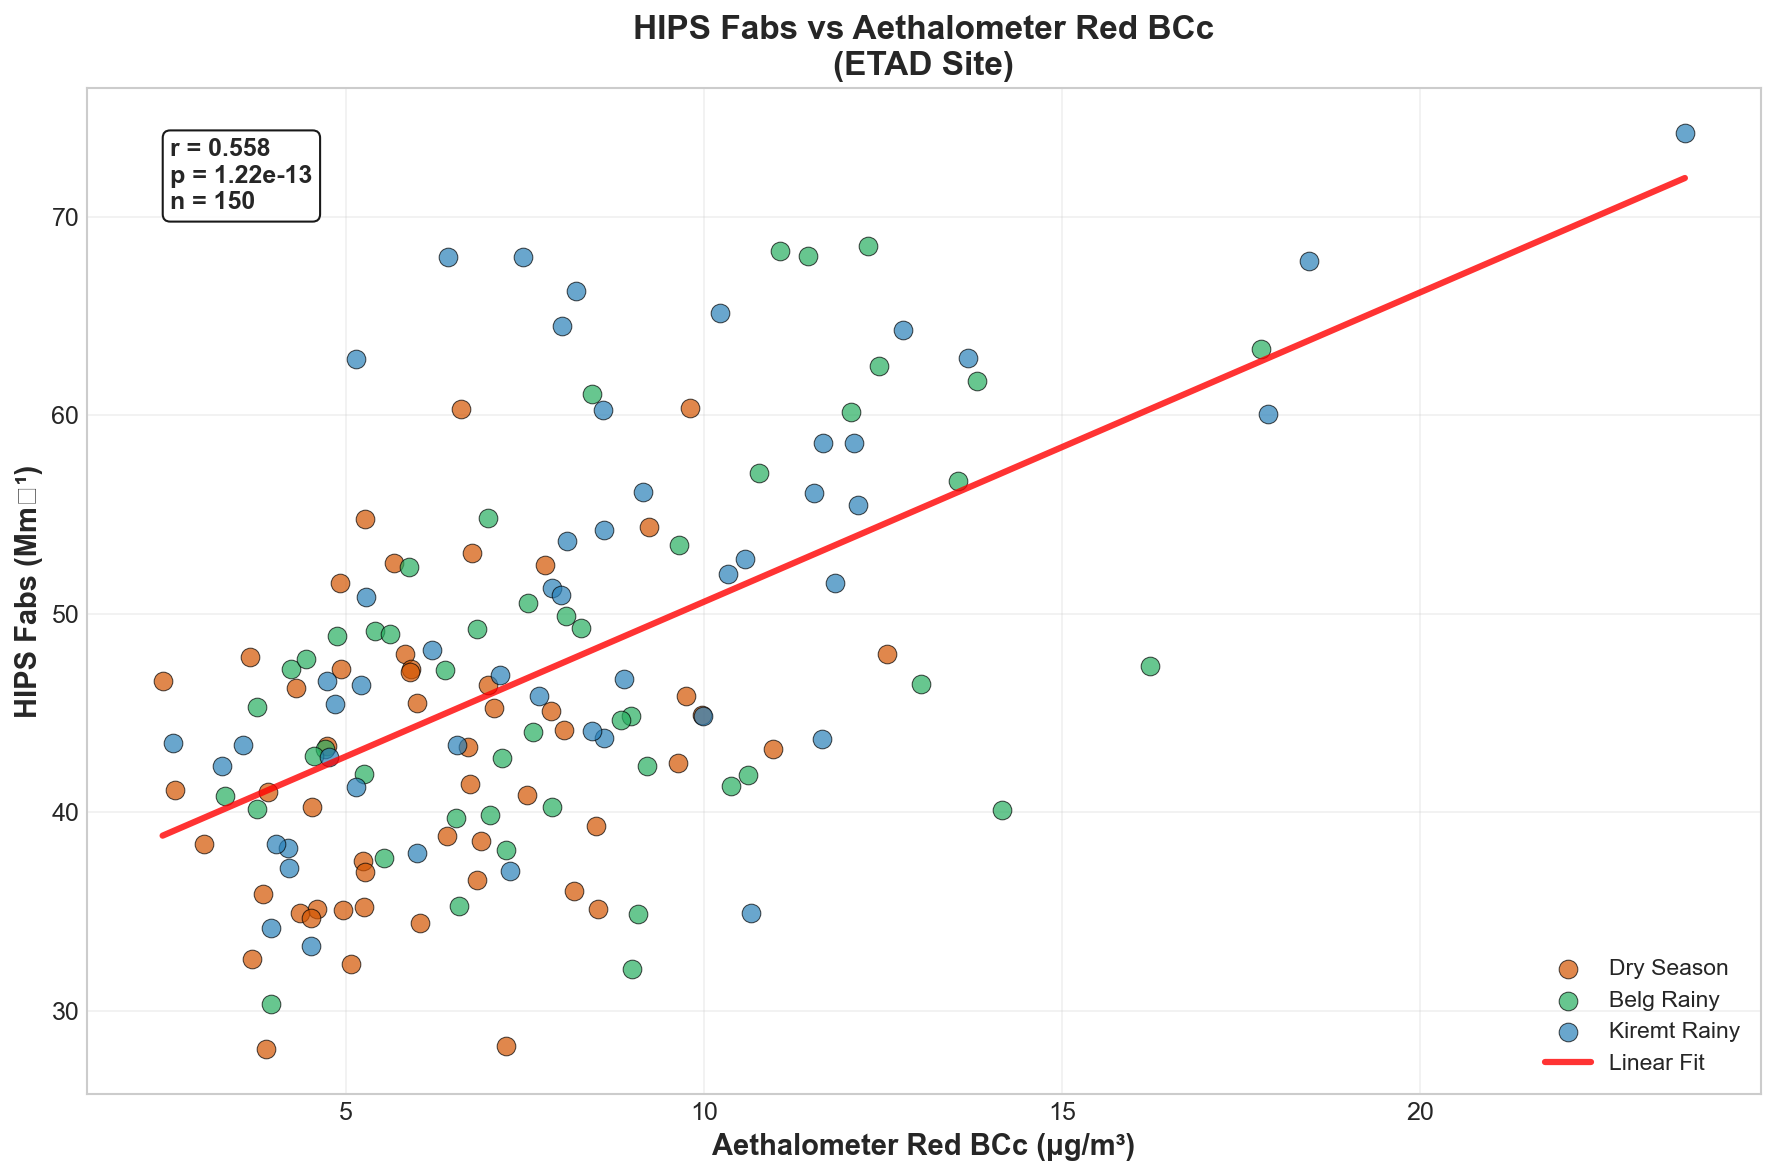

✅ Plot 1 Complete: HIPS Fabs vs Aethalometer Red BCc


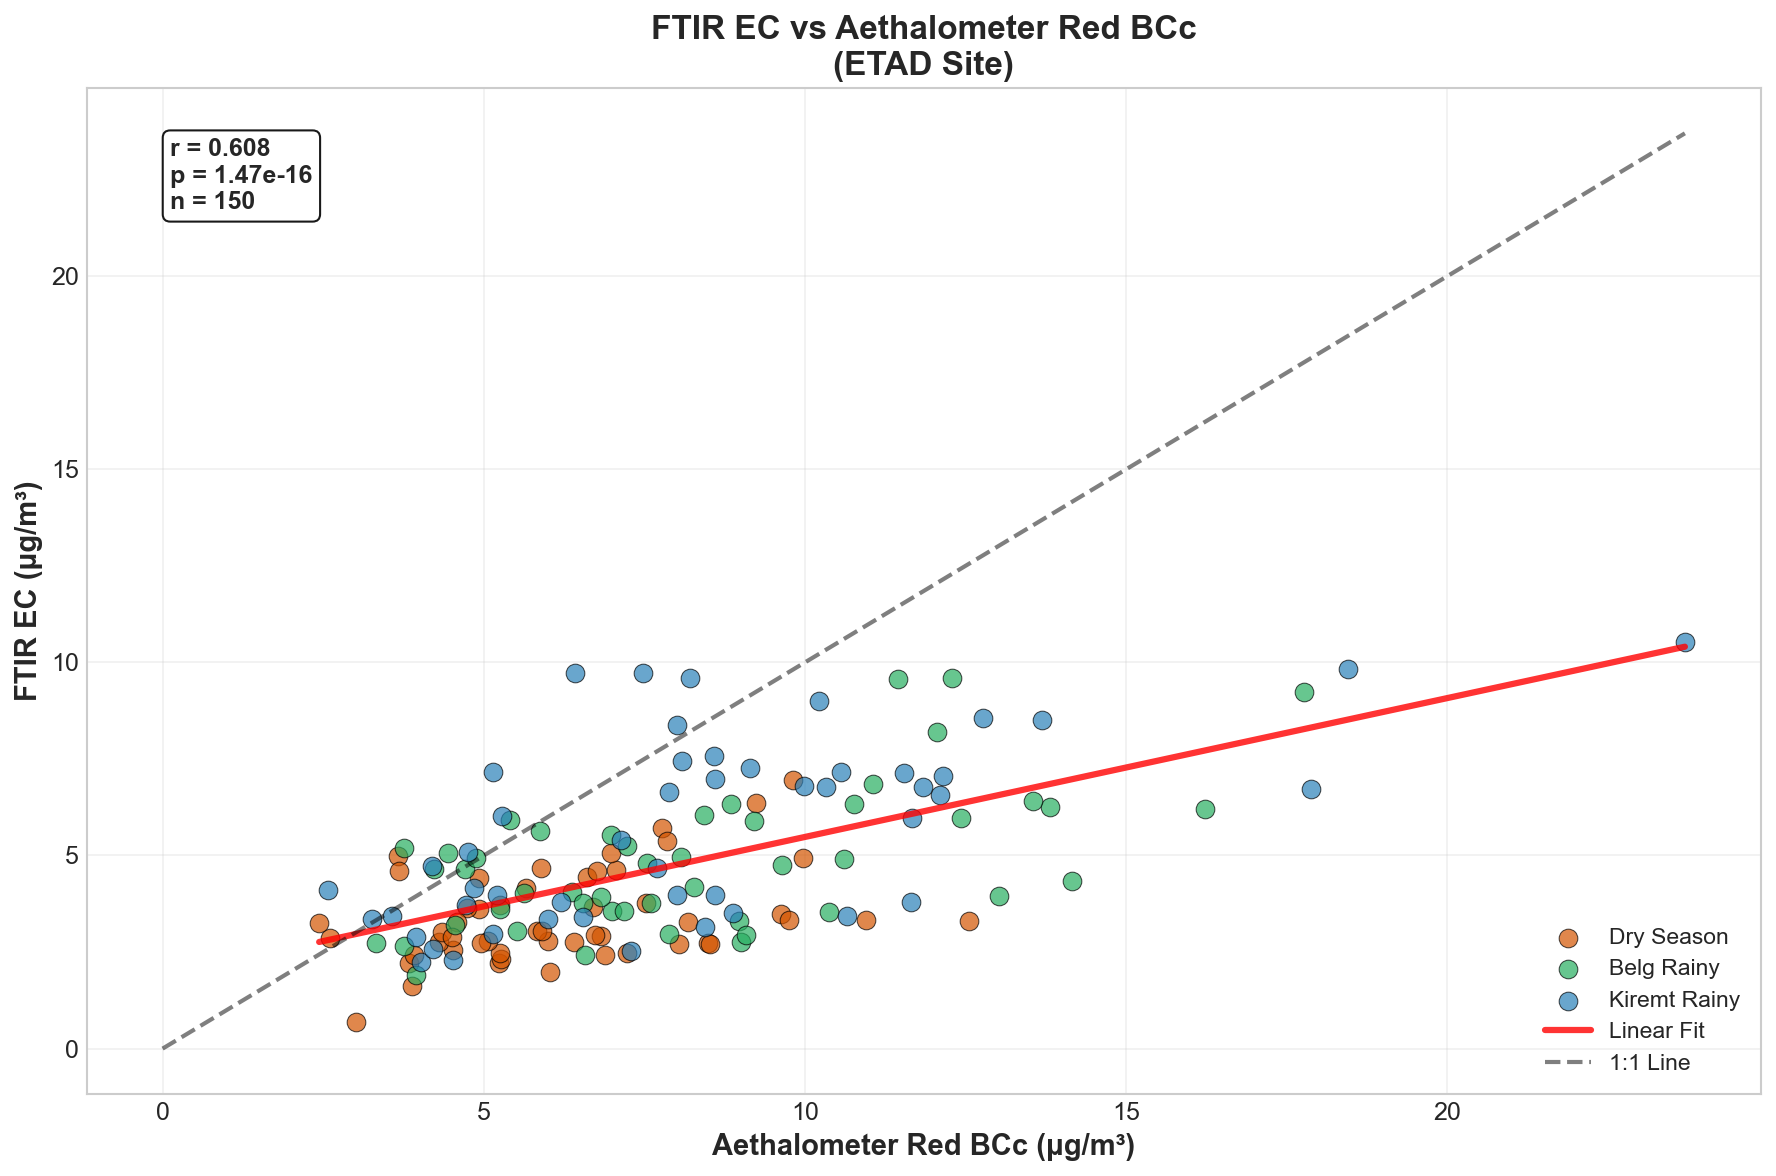

✅ Plot 2 Complete: FTIR EC vs Aethalometer Red BCc


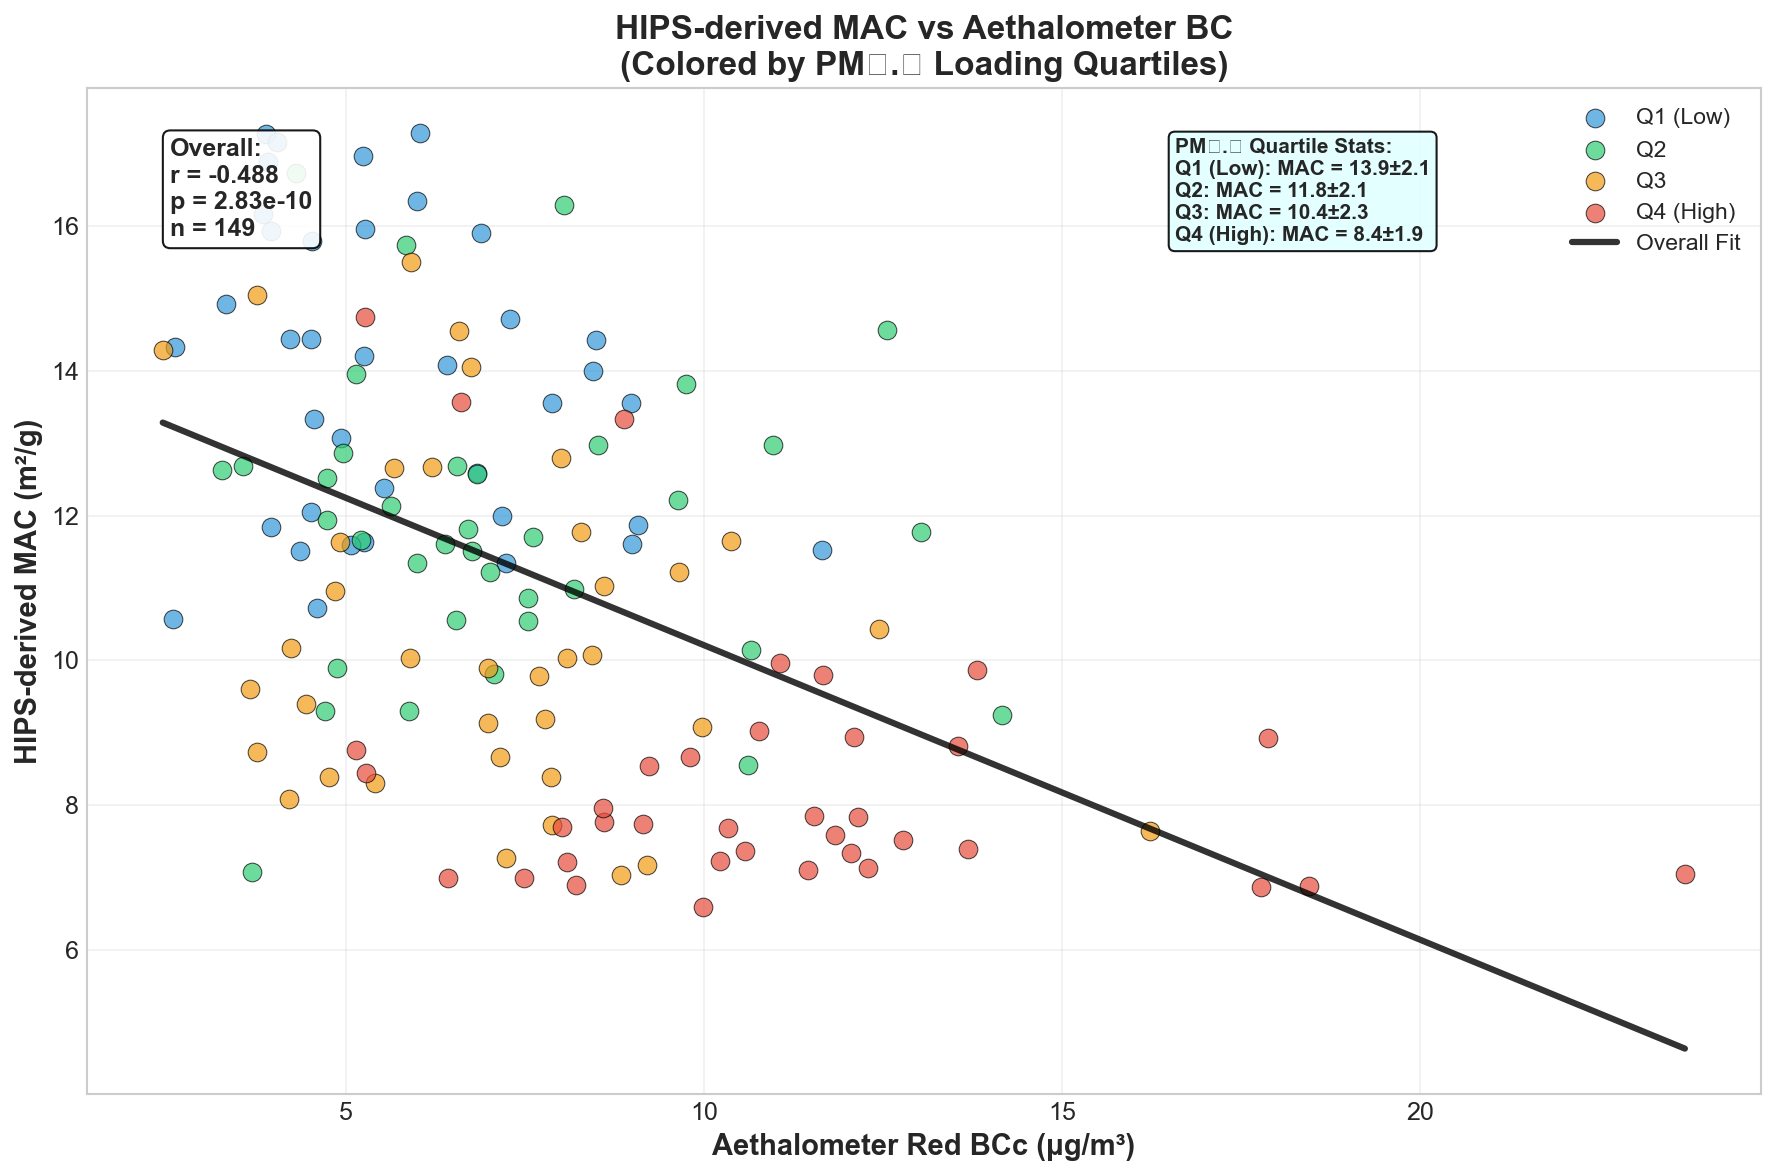

✅ Plot 3 Complete: MAC vs Aethalometer (PM quartiles)


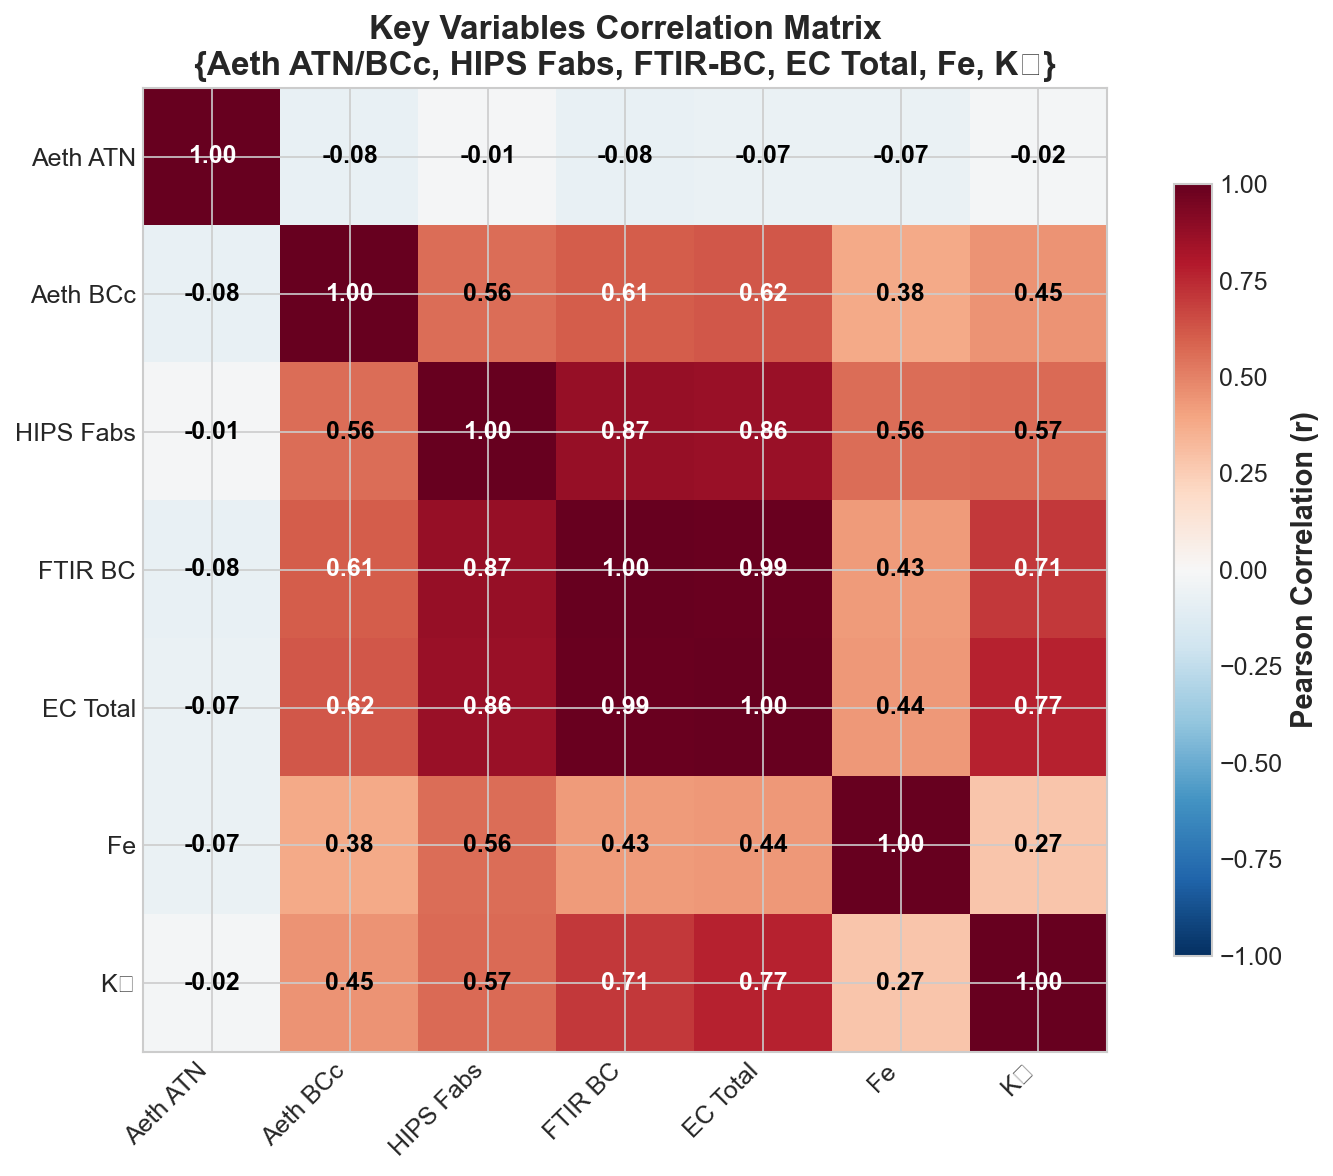

✅ Plot 4 Complete: Key Variables Correlation Matrix

Key Correlations:
  FTIR BC ↔ EC Total: r = 0.986
  HIPS Fabs ↔ FTIR BC: r = 0.871
  HIPS Fabs ↔ EC Total: r = 0.862
  EC Total ↔ K⁺: r = 0.772
  FTIR BC ↔ K⁺: r = 0.708


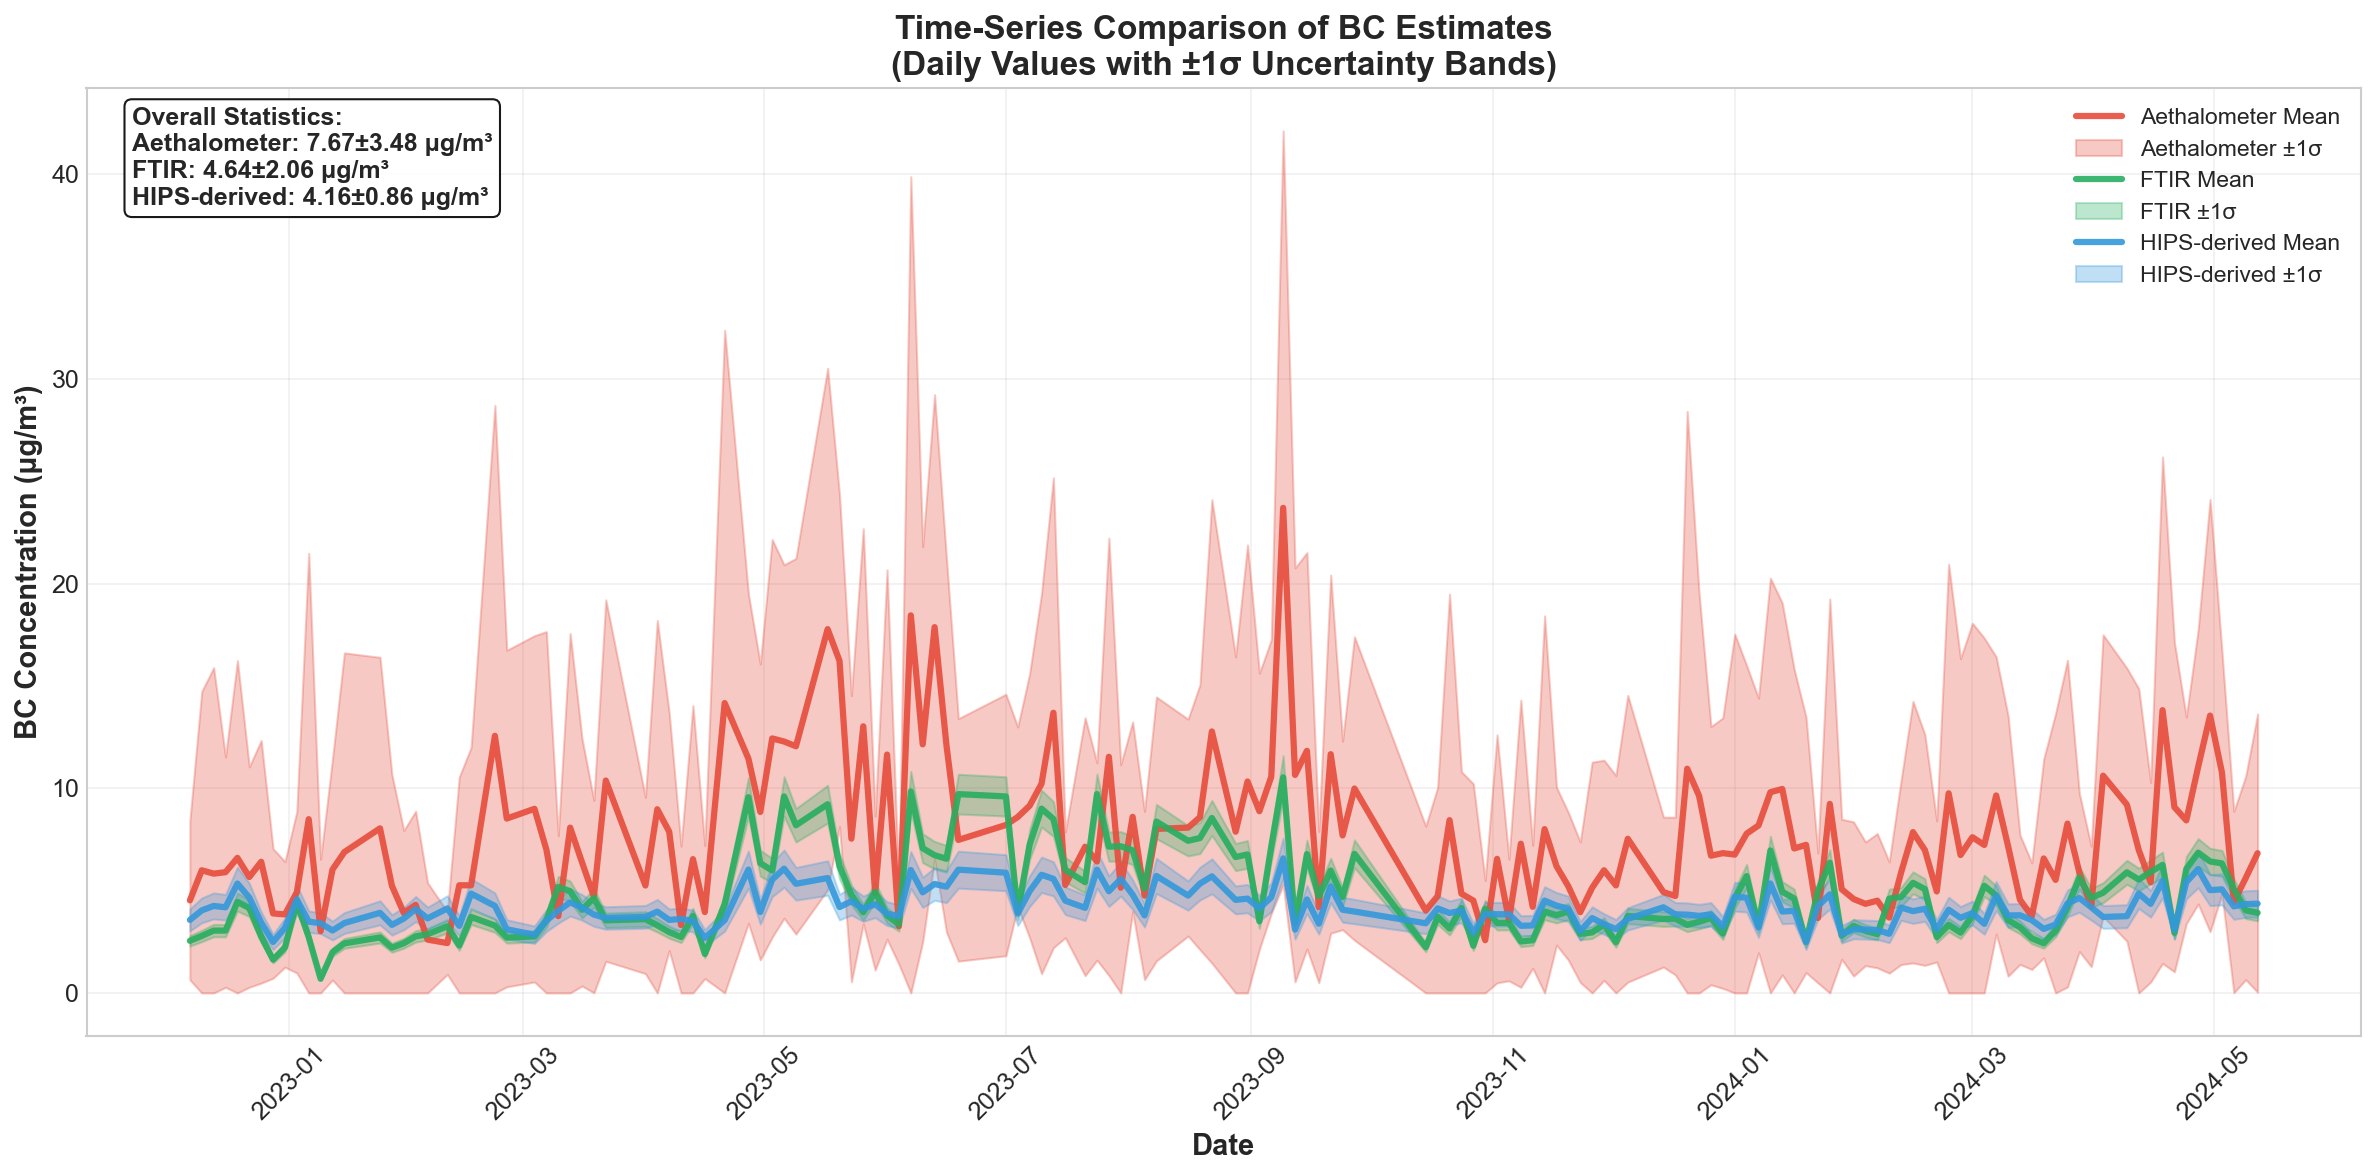

✅ Plot 5 Complete: BC Time-Series Ribbon Plot


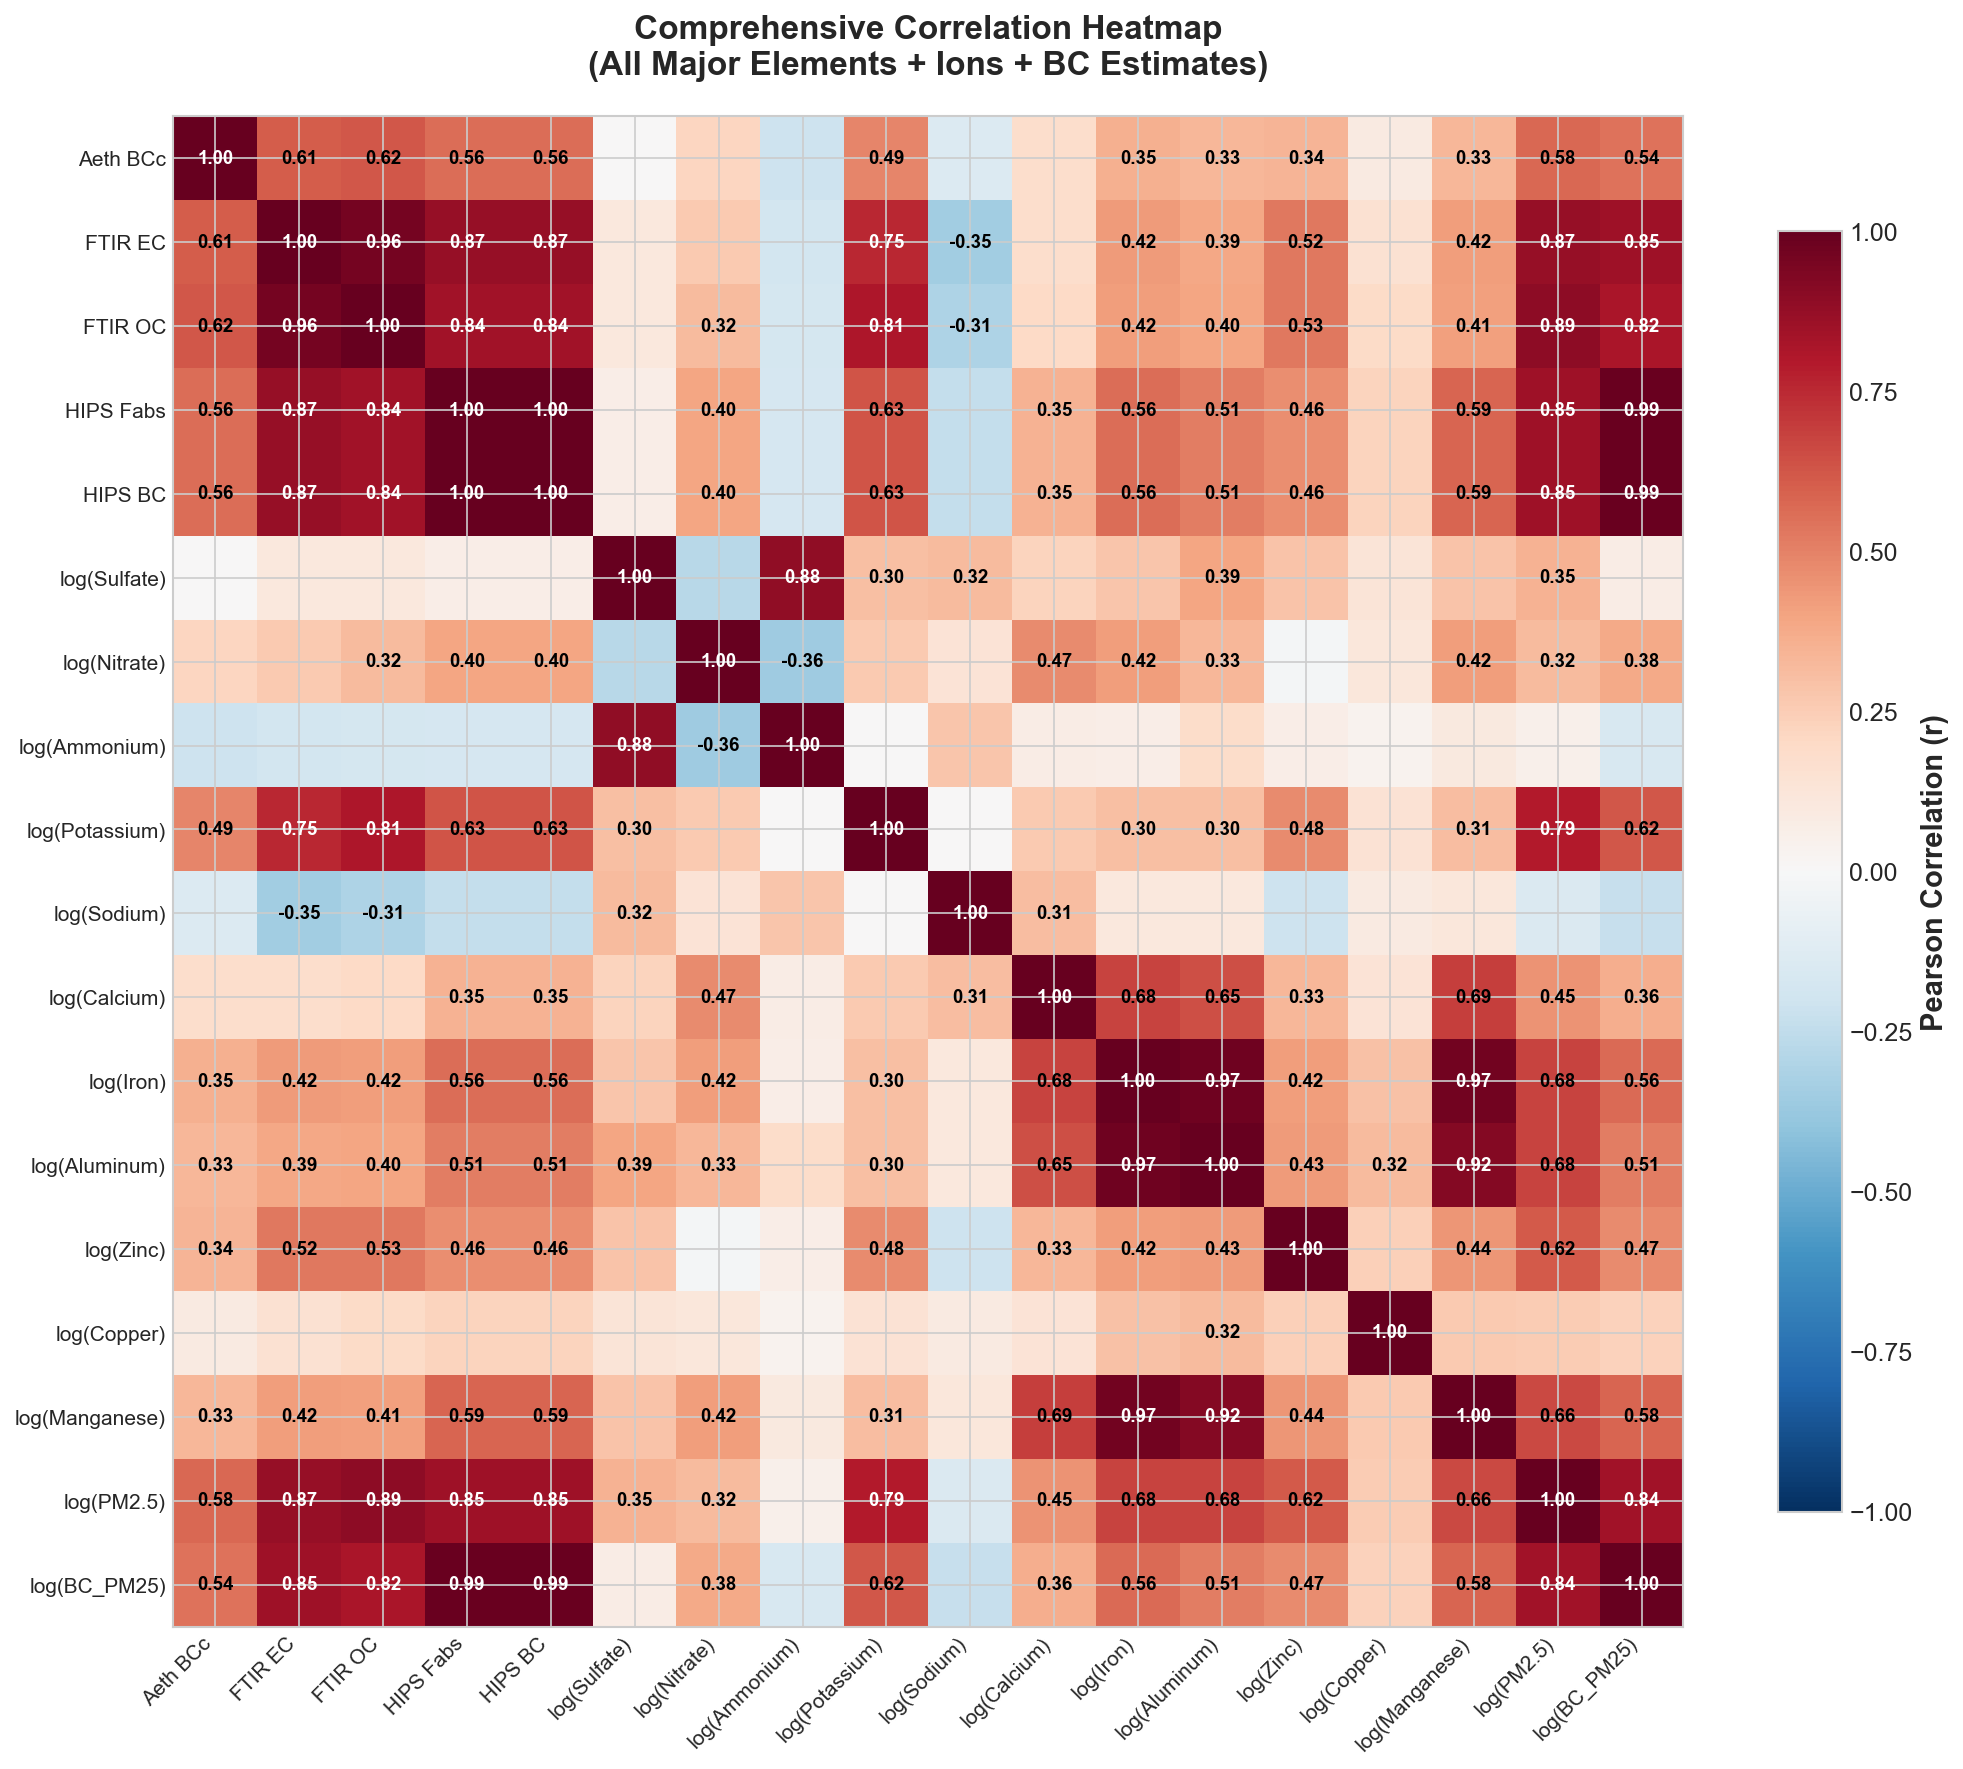

✅ Plot 6 Complete: Comprehensive Correlation Heatmap

Analyzed 18 variables with sufficient data

Strongest Inter-Variable Correlations (|r| > 0.7):
  HIPS Fabs ↔ HIPS BC: r = 1.000
  HIPS BC ↔ log(BC_PM25): r = 0.991
  HIPS Fabs ↔ log(BC_PM25): r = 0.991
  log(Iron) ↔ log(Aluminum): r = 0.973
  log(Iron) ↔ log(Manganese): r = 0.967
  FTIR EC ↔ FTIR OC: r = 0.959
  log(Aluminum) ↔ log(Manganese): r = 0.921
  FTIR OC ↔ log(PM2.5): r = 0.893
  log(Sulfate) ↔ log(Ammonium): r = 0.883
  FTIR EC ↔ HIPS Fabs: r = 0.871
  FTIR EC ↔ HIPS BC: r = 0.871
  FTIR EC ↔ log(PM2.5): r = 0.869
  FTIR EC ↔ log(BC_PM25): r = 0.848
  HIPS BC ↔ log(PM2.5): r = 0.847
  HIPS Fabs ↔ log(PM2.5): r = 0.847
  FTIR OC ↔ HIPS BC: r = 0.841
  FTIR OC ↔ HIPS Fabs: r = 0.841
  log(PM2.5) ↔ log(BC_PM25): r = 0.841
  FTIR OC ↔ log(BC_PM25): r = 0.816
  FTIR OC ↔ log(Potassium): r = 0.811
  log(Potassium) ↔ log(PM2.5): r = 0.792
  FTIR EC ↔ log(Potassium): r = 0.754

Moderate Correlations (0.5 < |r| ≤ 0.7): 0
Weak Corre

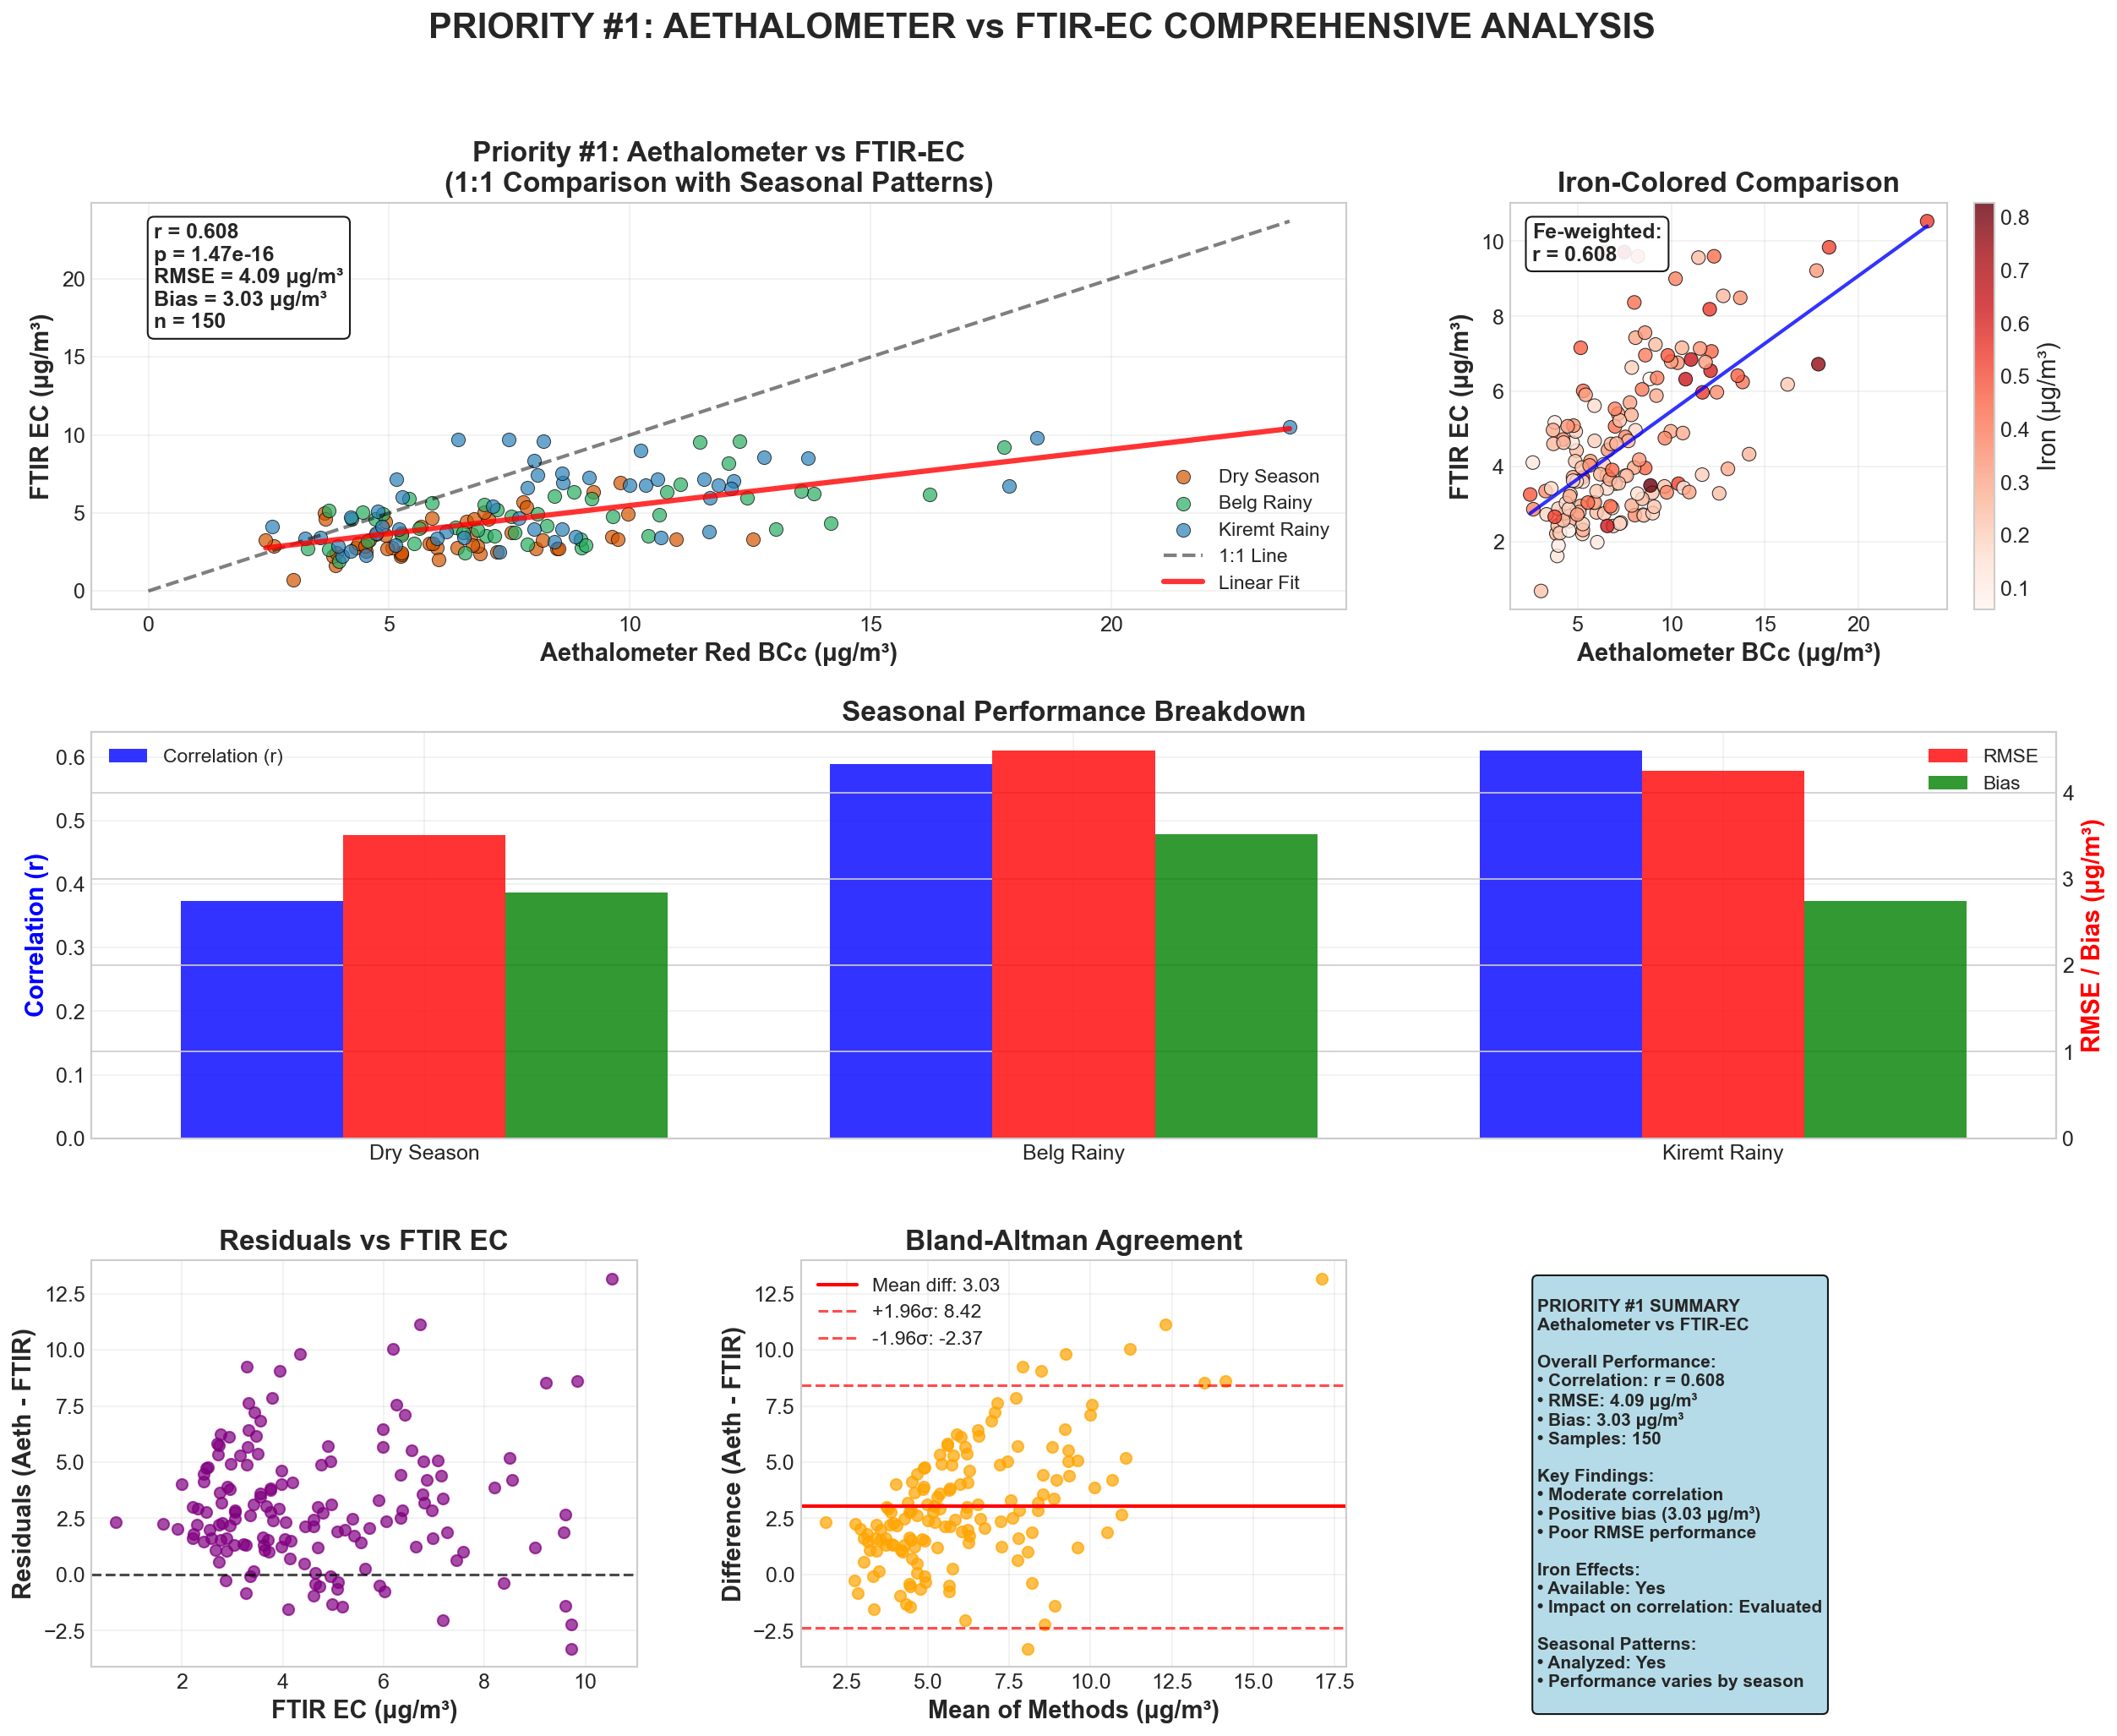

✅ Priority #1 Analysis Complete: Aethalometer vs FTIR-EC
🎯 PRIORITY #2: AETHALOMETER vs HIPS OPTICAL COMPARISON


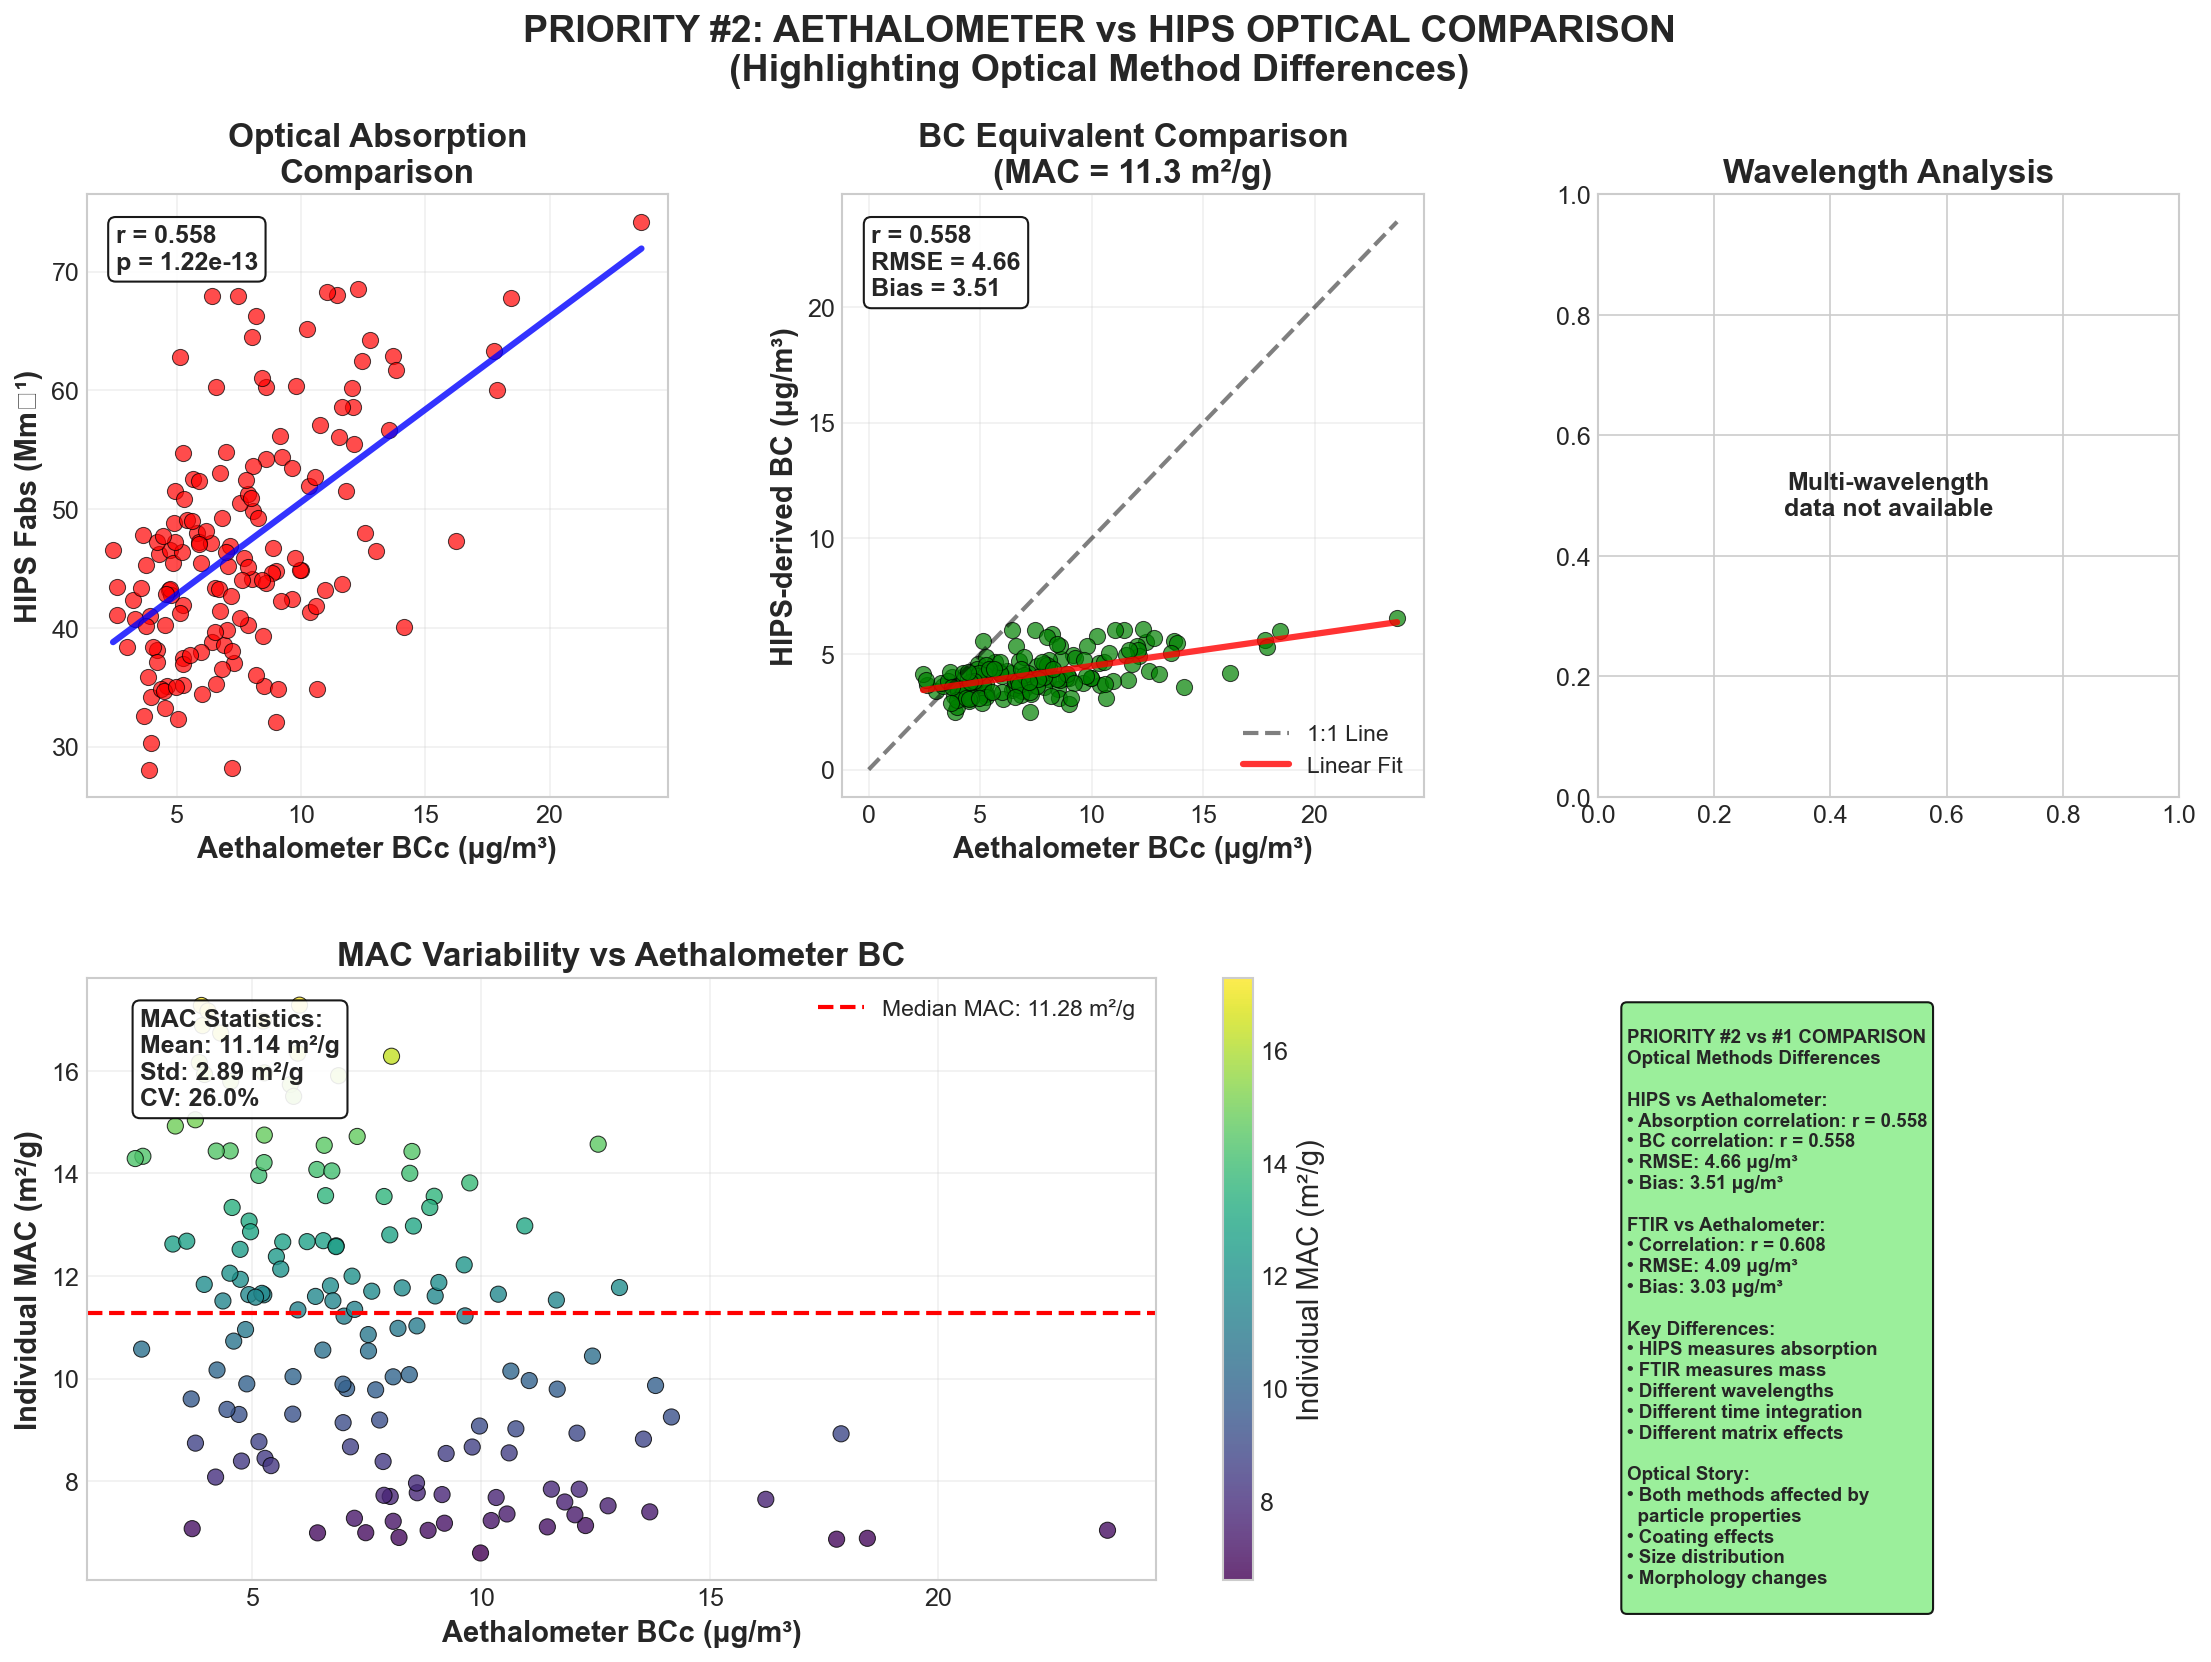

✅ Priority #2 Analysis Complete: Aethalometer vs HIPS
🌍 SEASONAL MAC RECALCULATIONS


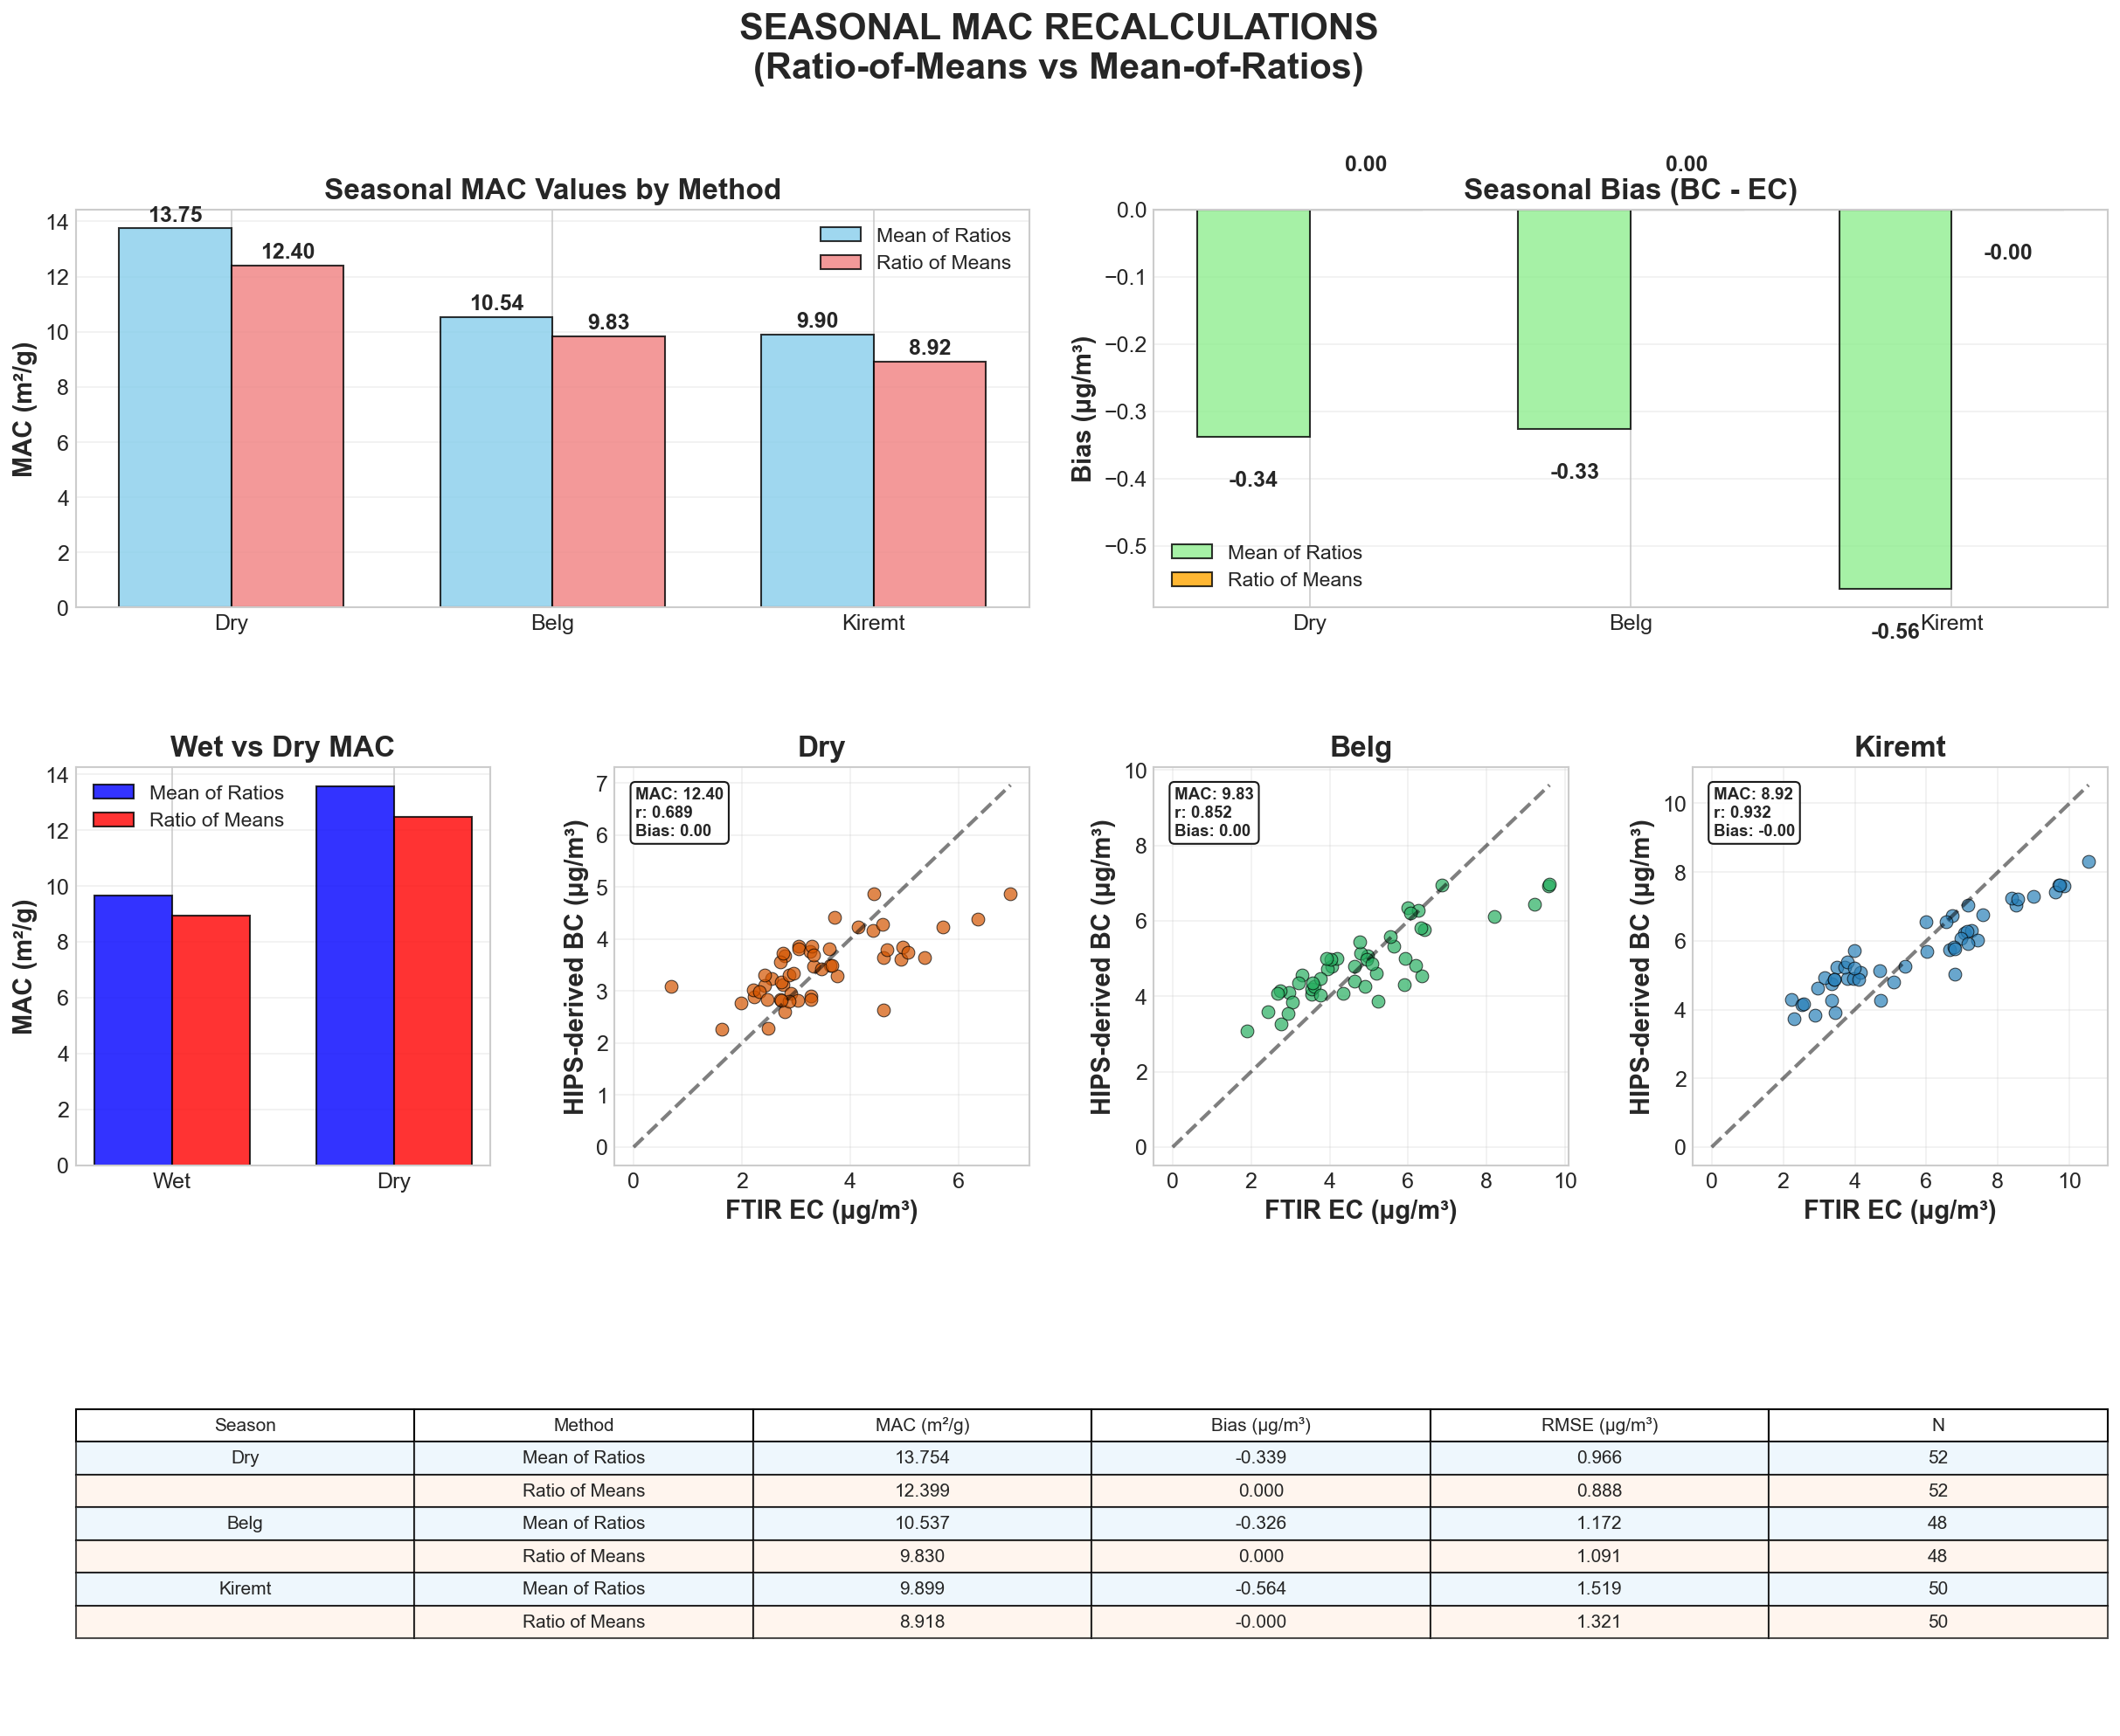

✅ Seasonal MAC Recalculations Complete
🧪 COMPOSITION EFFECTS ON MAC DEVIATIONS


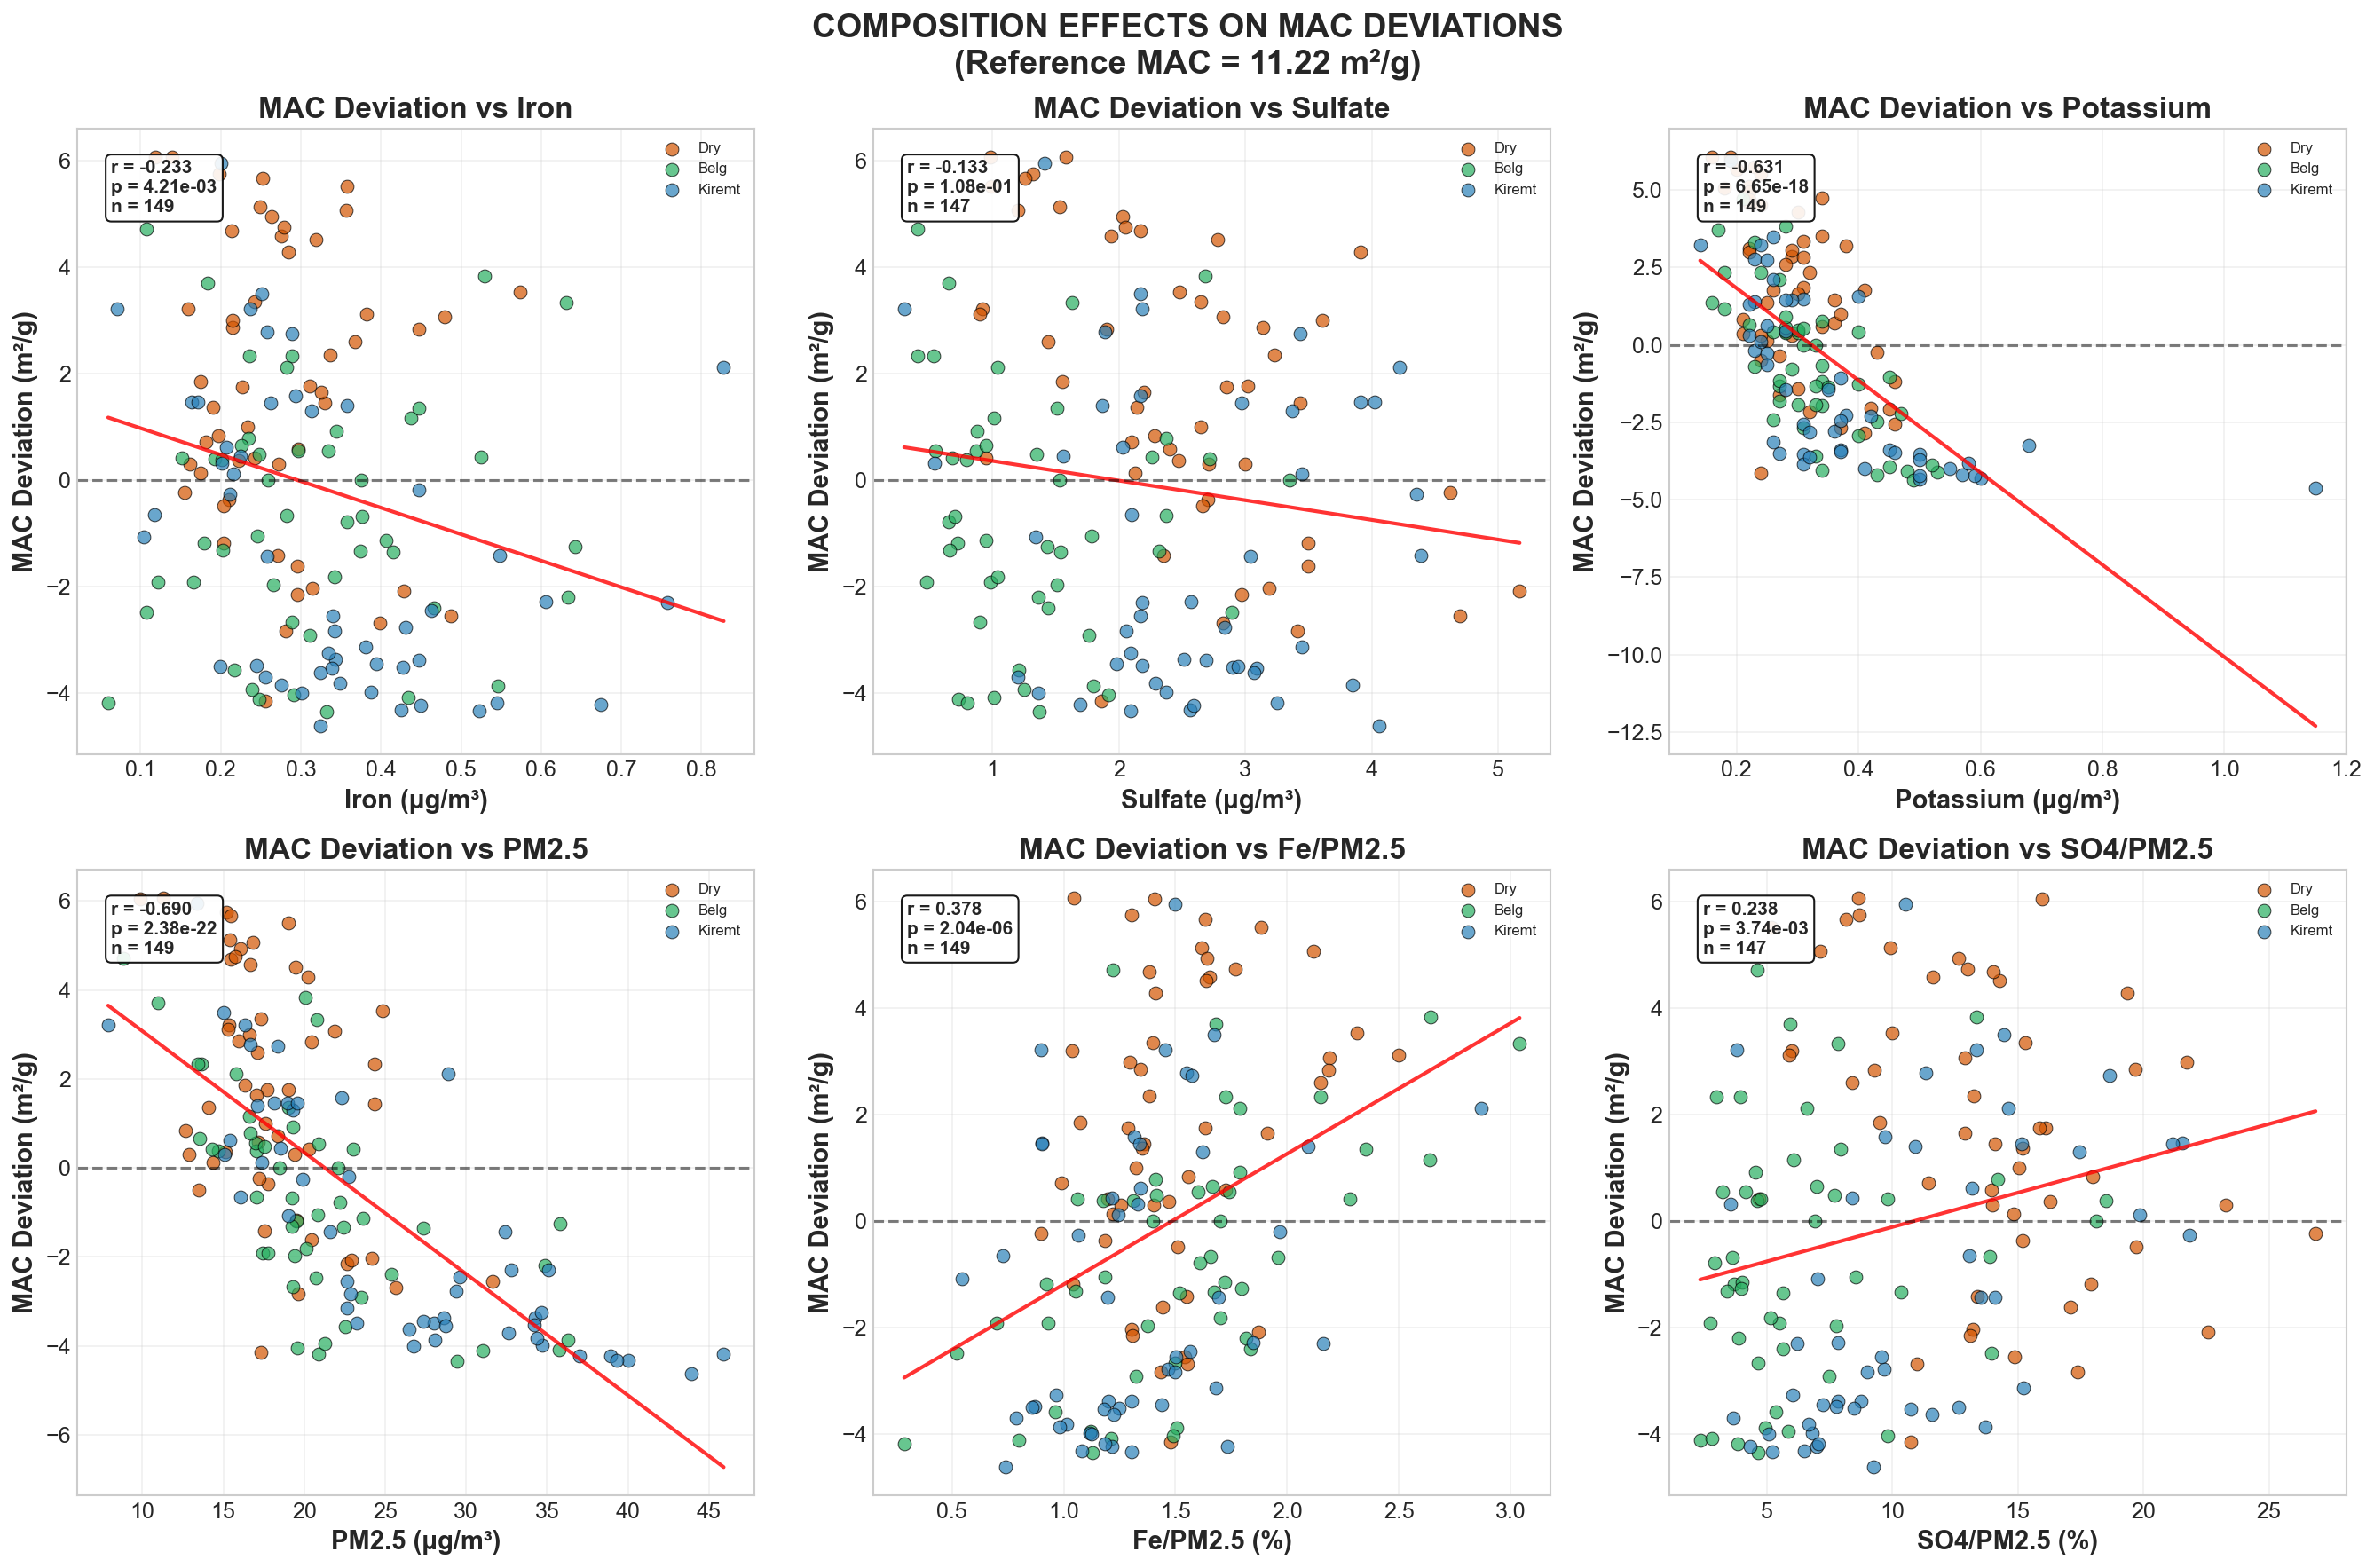


📊 COMPOSITION EFFECTS SUMMARY:
Reference MAC: 11.224 m²/g
MAC deviation range: -4.62 to 6.06 m²/g
MAC deviation std: 2.89 m²/g

🔗 CORRELATIONS WITH MAC DEVIATIONS:
  • PM2.5 (μg/m³): r = -0.690*** (Strong, n=149)
  • Potassium (μg/m³): r = -0.631*** (Strong, n=149)
  • Fe/PM2.5 (%): r =  0.378*** (Moderate, n=149)
  • SO4/PM2.5 (%): r =  0.238**  (Weak, n=147)
  • Iron (μg/m³): r = -0.233**  (Weak, n=149)
  • Sulfate (μg/m³): r = -0.133    (Weak, n=147)

💡 INTERPRETATION GUIDE:
  • Positive correlation: Higher concentration → Higher MAC
  • Negative correlation: Higher concentration → Lower MAC
  • Strong |r| > 0.5, Moderate 0.3 < |r| ≤ 0.5, Weak |r| ≤ 0.3
  • *** p<0.001, ** p<0.01, * p<0.05
🌈 MULTI-WAVELENGTH AETHALOMETER ANALYSIS
Available wavelengths: ['UV', 'Blue', 'Green', 'Red', 'IR']
Multi-wavelength dataset: 150 samples


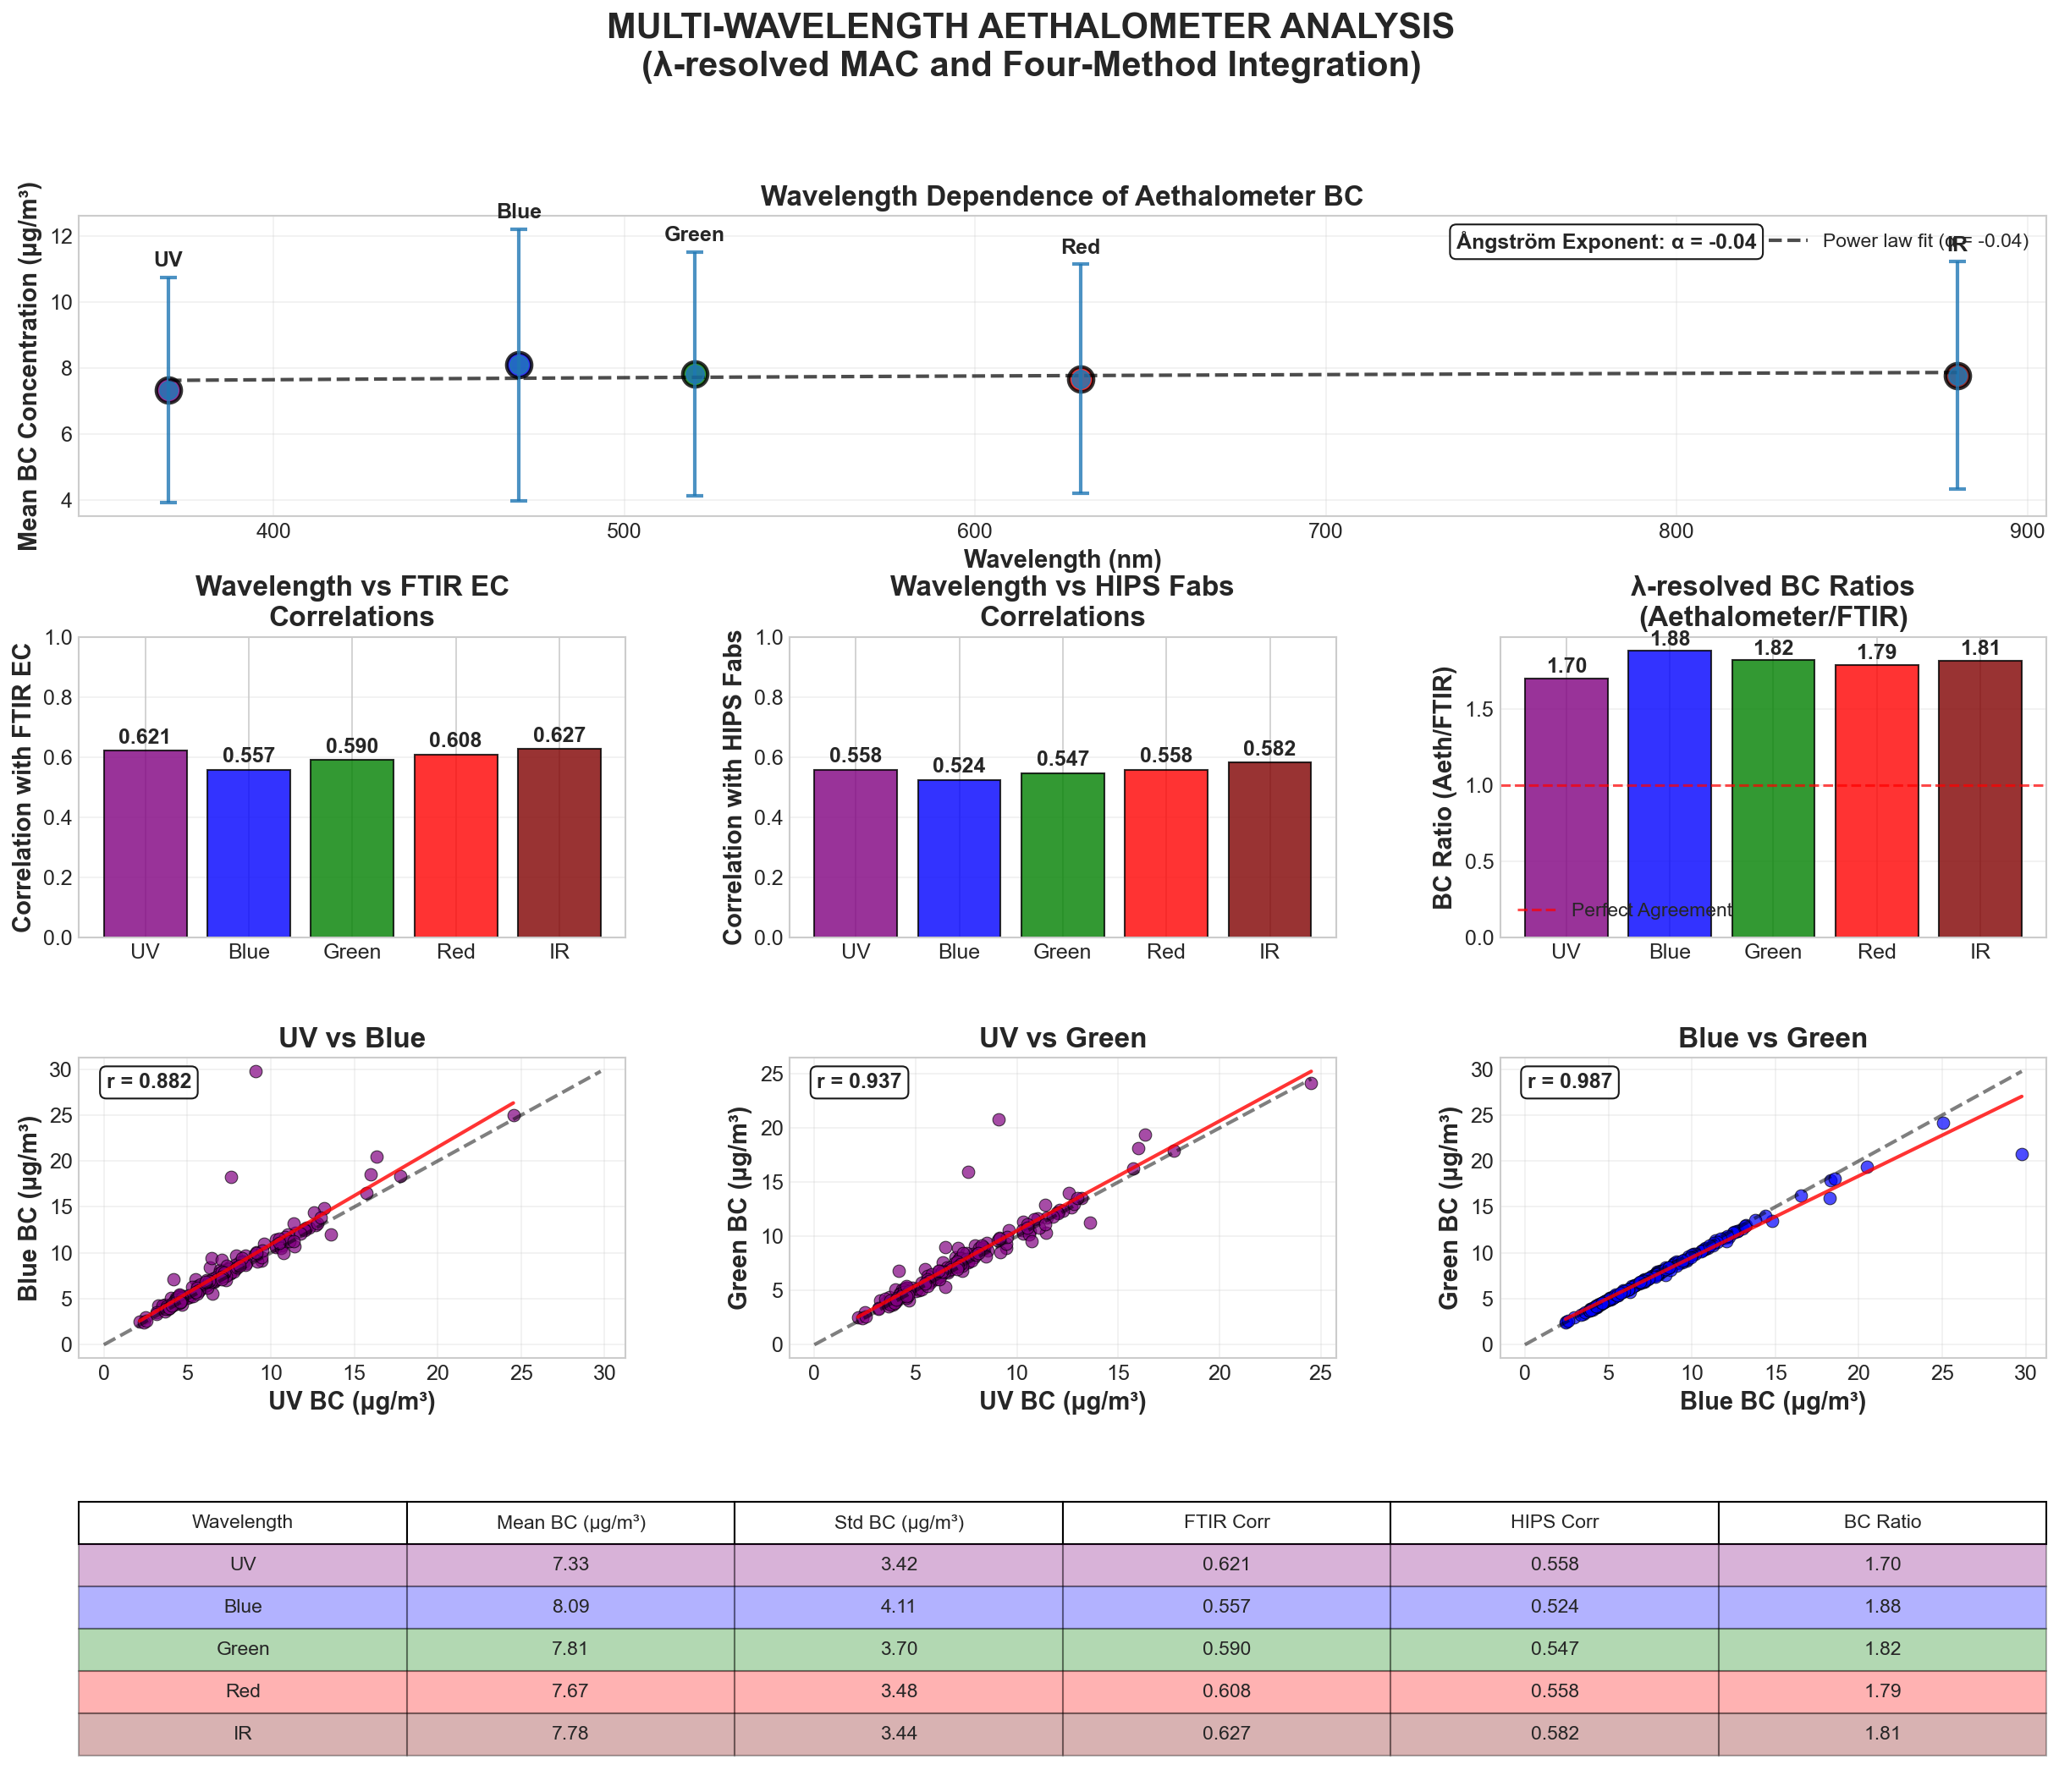

✅ Multi-wavelength Analysis Complete
COMPLETE PRIORITY DELIVERABLES SUMMARY
✅ All requested priority analyses completed successfully!

PRIORITY #1 - Aethalometer vs FTIR-EC:
• End-to-end 1:1 comparison plots
• RMSE/bias analysis with seasonal breakdown
• Iron-colored scatter plots
• Residuals and Bland-Altman analysis

PRIORITY #2 - Aethalometer vs HIPS:
• Optical absorption comparison (Fabs)
• BC-equivalent comparison with MAC
• Wavelength dependence analysis
• Method differences highlighting

SEASONAL ANALYSIS:
• MAC recalculations (wet vs dry)
• Ratio-of-means vs mean-of-ratios methods
• Seasonal bias and RMSE analysis

COMPOSITION EFFECTS:
• MAC deviation correlations with Fe, SO₄²⁻
• Chemical species scatter plots
• Seasonal composition patterns

MULTI-WAVELENGTH INTEGRATION:
• λ-resolved MAC analysis
• Four-method pipeline integration
• Ångström exponent calculation
• Inter-wavelength correlations

📊 COMPREHENSIVE DATASET ANALYSIS:
• Total samples: 150
• Date range: 2022-12-07 to

In [2]:
# %% [markdown]
# # Independent Black Carbon Method Comparison Visualizations
# 
# This notebook creates 6 separate visualizations comparing different BC measurement methods:
# 1. HIPS Fabs vs Aethalometer Attenuation/BCc
# 2. FTIR-BC vs Aethalometer Attenuation/BCc  
# 3. HIPS-derived MAC vs Aethalometer BCc (colored by PM quartiles)
# 4. Correlation matrix of key variables
# 5. Time-series ribbon plot of BC estimates
# 6. Comprehensive correlation heatmap of all species

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy.stats import pearsonr
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 18
})

# %% [markdown]
# ## Data Loading Functions
# Using the existing data loading infrastructure

# %%
def load_aethalometer_data(file_path, convert_to_ug=True):
    """Load and prepare Aethalometer data with unit conversion"""
    print(f"Loading Aethalometer data from: {file_path}")
    
    try:
        df = pd.read_csv(file_path)
        
        # Parse datetime
        if 'Date local (yyyy/MM/dd)' in df.columns and 'Time local (hh:mm:ss)' in df.columns:
            try:
                df['datetime_local'] = pd.to_datetime(
                    df['Date local (yyyy/MM/dd)'] + ' ' + df['Time local (hh:mm:ss)'],
                    format='mixed'
                )
                df.set_index('datetime_local', inplace=True)
                df.index = df.index.floor('min')
                df.sort_index(inplace=True)
            except Exception as e:
                print(f"Error parsing datetime: {e}")
                return None
        
        # Convert BC values from ng/m³ to μg/m³ if requested
        if convert_to_ug:
            bc_columns = [col for col in df.columns if 'BC' in col and col != 'BC_PM25']
            for col in bc_columns:
                if col in df.columns:
                    df[col] = df[col] / 1000
        
        print(f"Loaded {len(df):,} Aethalometer records")
        return df
        
    except Exception as e:
        print(f"Error loading Aethalometer data: {e}")
        return None

def load_ftir_hips_data(db_path):
    """Load FTIR/HIPS data from SQLite database"""
    print(f"Loading FTIR/HIPS data from: {db_path}")
    
    try:
        conn = sqlite3.connect(db_path)
        
        query = """
        SELECT 
            f.filter_id, f.sample_date, f.site_code,
            m.ec_ftir, m.oc_ftir, m.fabs, m.volume_m3
        FROM filters f
        JOIN ftir_sample_measurements m USING(filter_id)
        WHERE f.site_code = 'ETAD'
        ORDER BY f.sample_date
        """
        
        df = pd.read_sql_query(query, conn)
        df['sample_date'] = pd.to_datetime(df['sample_date'])
        conn.close()
        
        print(f"Loaded {len(df)} FTIR/HIPS samples")
        return df
        
    except Exception as e:
        print(f"Error loading FTIR/HIPS data: {e}")
        return None

def load_speciation_data(csv_path):
    """Load chemical speciation data"""
    print(f"Loading speciation data from: {csv_path}")
    
    try:
        df = pd.read_csv(csv_path, skiprows=3)
        df = df[df['Site_Code'] == 'ETAD'].copy()
        
        # Create datetime
        def create_timestamp(row):
            try:
                return pd.Timestamp(
                    year=int(row['Start_Year_local']),
                    month=int(row['Start_Month_local']),
                    day=int(row['Start_Day_local']),
                    hour=int(row['Start_hour_local'])
                )
            except:
                return pd.NaT
        
        df['Start_Date'] = df.apply(create_timestamp, axis=1)
        df = df[df['Start_Date'].notna()].copy()
        
        # Parameter mapping
        parameter_mapping = {
            28101: 'PM25_mass',
            28202: 'BC_PM25',
            28401: 'Sulfate_Ion',
            28402: 'Nitrate_Ion',
            28801: 'Sodium_Ion',
            28802: 'Ammonium_Ion',
            28803: 'Potassium_Ion',
            28805: 'Calcium_Ion',
            28908: 'Iron',
            28902: 'Aluminum',
            28912: 'Zinc',
            28911: 'Copper',
            28907: 'Manganese'
        }
        
        df['Parameter_Name_Clean'] = df['Parameter_Code'].map(parameter_mapping)
        df_mapped = df[df['Parameter_Name_Clean'].notna()].copy()
        
        # Convert ng/m³ to μg/m³ for metals
        ng_to_ug_species = ['Iron', 'Aluminum', 'Zinc', 'Copper', 'Manganese']
        
        # Pivot to wide format
        speciation_wide = df_mapped.pivot_table(
            index=['Filter_ID', 'Start_Date'],
            columns='Parameter_Name_Clean',
            values='Value',
            aggfunc='first'
        ).reset_index()
        
        speciation_wide.columns.name = None
        
        # Unit conversions
        for species in ng_to_ug_species:
            if species in speciation_wide.columns:
                speciation_wide[species] = speciation_wide[species] / 1000
        
        print(f"Loaded {len(speciation_wide)} speciation samples")
        return speciation_wide
        
    except Exception as e:
        print(f"Error loading speciation data: {e}")
        return None

# %% [markdown]
# ## Data Loading and Preparation

# %%
# File paths - UPDATE THESE TO YOUR ACTUAL PATHS
AETHALOMETER_PATH = "/Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Aethelometry Data/Raw/Jacros_MA350_1-min_2022-2024_Cleaned.csv"
DB_PATH = "/Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/EC-HIPS-Aeth Comparison/Data/Original Data/Combined Database/spartan_ftir_hips.db"
SPECIATION_PATH = "/Users/ahzs645/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/EC-HIPS-Aeth Comparison/Data/Downloaded Data/SPARTAN/Addis Ababa/FilterBased_ChemSpecPM25_ETAD.csv"

# Load all datasets
print("="*60)
print("LOADING ALL DATASETS")
print("="*60)

# Load aethalometer data
aeth_df = load_aethalometer_data(AETHALOMETER_PATH)

# Load FTIR/HIPS data
ftir_df = load_ftir_hips_data(DB_PATH)

# Load speciation data
spec_df = load_speciation_data(SPECIATION_PATH)

# %% [markdown]
# ## Data Merging and Alignment

# %%
def merge_all_datasets(aeth_df, ftir_df, spec_df):
    """Merge all three datasets on overlapping dates"""
    print("\nMerging datasets on overlapping dates...")
    
    if any(df is None for df in [aeth_df, ftir_df, spec_df]):
        print("One or more datasets failed to load")
        return None
    
    # Prepare FTIR data for merging
    ftir_merge = ftir_df.copy()
    ftir_merge['date_key'] = ftir_merge['sample_date'].dt.date
    
    # Prepare speciation data for merging  
    spec_merge = spec_df.copy()
    spec_merge['date_key'] = spec_merge['Start_Date'].dt.date
    
    # Merge FTIR and speciation
    merged = pd.merge(ftir_merge, spec_merge, on='date_key', how='inner', suffixes=('_ftir', '_spec'))
    print(f"FTIR-Speciation merge: {len(merged)} samples")
    
    if len(merged) == 0:
        print("No overlapping dates between FTIR and speciation data")
        return None
    
    # For each merged sample, find corresponding aethalometer data (24h periods)
    final_data = []
    
    for _, row in merged.iterrows():
        sample_date = row['sample_date']
        
        # Define 24h period (9am to 9am next day, matching filter collection)
        period_start = sample_date.normalize() + pd.Timedelta(hours=9) - pd.Timedelta(days=1)
        period_end = period_start + pd.Timedelta(days=1)
        
        # Extract aethalometer data for this period
        aeth_period = aeth_df.loc[period_start:period_end]
        
        if len(aeth_period) > 100:  # Minimum data requirement
            # Calculate aethalometer statistics
            aeth_stats = {}
            
            # Check for Red channel data (prioritize BCc, then attenuation)
            if 'Red BCc' in aeth_period.columns:
                red_data = aeth_period['Red BCc'].dropna()
                if len(red_data) > 0:
                    aeth_stats['red_bc_mean'] = red_data.mean()
                    aeth_stats['red_bc_std'] = red_data.std()
                    aeth_stats['red_bc_count'] = len(red_data)
            
            if 'Red ATN1' in aeth_period.columns:
                atn_data = aeth_period['Red ATN1'].dropna()
                if len(atn_data) > 0:
                    aeth_stats['red_atn_mean'] = atn_data.mean()
                    aeth_stats['red_atn_std'] = atn_data.std()
            
            # Add to final dataset
            if aeth_stats:
                row_dict = row.to_dict()
                row_dict.update(aeth_stats)
                row_dict['period_start'] = period_start
                row_dict['period_end'] = period_end
                final_data.append(row_dict)
    
    if final_data:
        result_df = pd.DataFrame(final_data)
        print(f"Final merged dataset: {len(result_df)} samples with overlapping data")
        return result_df
    else:
        print("No samples with sufficient overlapping aethalometer data")
        return None

# Merge all datasets
merged_df = merge_all_datasets(aeth_df, ftir_df, spec_df)

if merged_df is not None:
    print(f"\nMerged dataset columns: {list(merged_df.columns)}")
    print(f"Date range: {merged_df['sample_date'].min()} to {merged_df['sample_date'].max()}")
else:
    print("Failed to create merged dataset")

# %% [markdown]
# ## Visualization 1: HIPS Fabs vs Aethalometer Attenuation/BCc

# %%
def plot_hips_vs_aethalometer(merged_df):
    """Plot HIPS Fabs vs Aethalometer measurements"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Determine which aethalometer measurement to use
    if 'red_bc_mean' in merged_df.columns:
        x_data = merged_df['red_bc_mean']
        x_label = 'Aethalometer Red BCc (μg/m³)'
        x_name = 'Red BCc'
    elif 'red_atn_mean' in merged_df.columns:
        x_data = merged_df['red_atn_mean']
        x_label = 'Aethalometer Red Attenuation'
        x_name = 'Red ATN'
    else:
        print("No suitable aethalometer data found")
        return
    
    y_data = merged_df['fabs']
    
    # Remove NaN values
    mask = x_data.notna() & y_data.notna()
    x_clean = x_data[mask]
    y_clean = y_data[mask]
    
    if len(x_clean) < 3:
        print("Insufficient data for plotting")
        return
    
    # Check for seasonal data
    if 'Start_Date' in merged_df.columns:
        # Create seasons based on month
        dates = merged_df.loc[mask, 'Start_Date']
        months = dates.dt.month
        
        def get_season(month):
            if month in [12, 1, 2]:
                return 'Dry Season'
            elif month in [3, 4, 5]:
                return 'Belg Rainy'
            else:
                return 'Kiremt Rainy'
        
        seasons = months.apply(get_season)
        
        # Plot by season if we have seasonal data
        if len(seasons.unique()) > 1:
            season_colors = {'Dry Season': '#d35400', 'Belg Rainy': '#27ae60', 'Kiremt Rainy': '#2980b9'}
            
            for season in seasons.unique():
                season_mask = seasons == season
                if season_mask.sum() > 0:
                    ax.scatter(x_clean[season_mask], y_clean[season_mask], 
                              c=season_colors.get(season, 'gray'), alpha=0.7, s=80,
                              label=season, edgecolors='black', linewidth=0.5)
        else:
            ax.scatter(x_clean, y_clean, alpha=0.7, s=80, color='blue', 
                      edgecolors='black', linewidth=0.5)
    else:
        ax.scatter(x_clean, y_clean, alpha=0.7, s=80, color='blue', 
                  edgecolors='black', linewidth=0.5)
    
    # Add regression line
    if len(x_clean) > 1:
        z = np.polyfit(x_clean, y_clean, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
        ax.plot(x_line, p(x_line), 'red', linewidth=3, alpha=0.8, label='Linear Fit')
        
        # Calculate correlation
        r, p_val = pearsonr(x_clean, y_clean)
        
        # Add statistics box
        stats_text = f'r = {r:.3f}\np = {p_val:.2e}\nn = {len(x_clean)}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                fontweight='bold', va='top')
    
    ax.set_xlabel(x_label, fontweight='bold')
    ax.set_ylabel('HIPS Fabs (Mm⁻¹)', fontweight='bold')
    ax.set_title(f'HIPS Fabs vs Aethalometer {x_name}\n(ETAD Site)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    if len(ax.get_legend_handles_labels()[0]) > 0:
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Plot 1 Complete: HIPS Fabs vs Aethalometer {x_name}")

# Create the plot
plot_hips_vs_aethalometer(merged_df)

# %% [markdown]
# ## Visualization 2: FTIR-BC vs Aethalometer Attenuation/BCc

# %%
def plot_ftir_vs_aethalometer(merged_df):
    """Plot FTIR-BC vs Aethalometer measurements"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Determine which aethalometer measurement to use
    if 'red_bc_mean' in merged_df.columns:
        x_data = merged_df['red_bc_mean']
        x_label = 'Aethalometer Red BCc (μg/m³)'
        x_name = 'Red BCc'
    elif 'red_atn_mean' in merged_df.columns:
        x_data = merged_df['red_atn_mean']
        x_label = 'Aethalometer Red Attenuation'
        x_name = 'Red ATN'
    else:
        print("No suitable aethalometer data found")
        return
    
    y_data = merged_df['ec_ftir']
    
    # Remove NaN values
    mask = x_data.notna() & y_data.notna()
    x_clean = x_data[mask]
    y_clean = y_data[mask]
    
    if len(x_clean) < 3:
        print("Insufficient data for plotting")
        return
    
    # Check for seasonal data
    if 'Start_Date' in merged_df.columns:
        dates = merged_df.loc[mask, 'Start_Date']
        months = dates.dt.month
        
        def get_season(month):
            if month in [12, 1, 2]:
                return 'Dry Season'
            elif month in [3, 4, 5]:
                return 'Belg Rainy'
            else:
                return 'Kiremt Rainy'
        
        seasons = months.apply(get_season)
        
        # Plot by season if we have seasonal data
        if len(seasons.unique()) > 1:
            season_colors = {'Dry Season': '#d35400', 'Belg Rainy': '#27ae60', 'Kiremt Rainy': '#2980b9'}
            
            for season in seasons.unique():
                season_mask = seasons == season
                if season_mask.sum() > 0:
                    ax.scatter(x_clean[season_mask], y_clean[season_mask], 
                              c=season_colors.get(season, 'gray'), alpha=0.7, s=80,
                              label=season, edgecolors='black', linewidth=0.5)
        else:
            ax.scatter(x_clean, y_clean, alpha=0.7, s=80, color='green', 
                      edgecolors='black', linewidth=0.5)
    else:
        ax.scatter(x_clean, y_clean, alpha=0.7, s=80, color='green', 
                  edgecolors='black', linewidth=0.5)
    
    # Add regression line
    if len(x_clean) > 1:
        z = np.polyfit(x_clean, y_clean, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
        ax.plot(x_line, p(x_line), 'red', linewidth=3, alpha=0.8, label='Linear Fit')
        
        # Calculate correlation
        r, p_val = pearsonr(x_clean, y_clean)
        
        # Add statistics box
        stats_text = f'r = {r:.3f}\np = {p_val:.2e}\nn = {len(x_clean)}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                fontweight='bold', va='top')
        
        # Add 1:1 line for reference
        max_val = max(x_clean.max(), y_clean.max())
        ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=2, label='1:1 Line')
    
    ax.set_xlabel(x_label, fontweight='bold')
    ax.set_ylabel('FTIR EC (μg/m³)', fontweight='bold')
    ax.set_title(f'FTIR EC vs Aethalometer {x_name}\n(ETAD Site)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    if len(ax.get_legend_handles_labels()[0]) > 0:
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Plot 2 Complete: FTIR EC vs Aethalometer {x_name}")

# Create the plot
plot_ftir_vs_aethalometer(merged_df)

# %% [markdown]
# ## Visualization 3: HIPS-derived MAC vs Aethalometer BCc (colored by PM quartiles)

# %%
def plot_mac_vs_aethalometer_pm_quartiles(merged_df):
    """Plot HIPS-derived MAC vs Aethalometer BCc, colored by PM loading quartiles"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    # Calculate HIPS-derived MAC (Fabs/EC)
    mac_hips = merged_df['fabs'] / merged_df['ec_ftir']
    
    # Get aethalometer BC data
    if 'red_bc_mean' in merged_df.columns:
        aeth_bc = merged_df['red_bc_mean']
        x_label = 'Aethalometer Red BCc (μg/m³)'
    else:
        print("No aethalometer BC data available")
        return
    
    # Get PM2.5 data for quartiles
    if 'PM25_mass' not in merged_df.columns:
        print("No PM2.5 data available for quartiles")
        return
    
    pm25_data = merged_df['PM25_mass']
    
    # Remove NaN values
    mask = mac_hips.notna() & aeth_bc.notna() & pm25_data.notna()
    mac_clean = mac_hips[mask]
    aeth_clean = aeth_bc[mask]
    pm25_clean = pm25_data[mask]
    
    # Filter reasonable MAC values
    reasonable_mask = (mac_clean > 0) & (mac_clean < 30)
    mac_clean = mac_clean[reasonable_mask]
    aeth_clean = aeth_clean[reasonable_mask]
    pm25_clean = pm25_clean[reasonable_mask]
    
    if len(mac_clean) < 5:
        print("Insufficient data for plotting")
        return
    
    # Create PM2.5 quartiles
    pm25_quartiles = pd.qcut(pm25_clean, q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Colors for quartiles
    quartile_colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
    
    # Plot each quartile
    for i, quartile in enumerate(['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']):
        quartile_mask = pm25_quartiles == quartile
        if quartile_mask.sum() > 0:
            ax.scatter(aeth_clean[quartile_mask], mac_clean[quartile_mask], 
                      c=quartile_colors[i], alpha=0.7, s=80, label=quartile,
                      edgecolors='black', linewidth=0.5)
    
    # Add overall regression line
    if len(aeth_clean) > 1:
        z = np.polyfit(aeth_clean, mac_clean, 1)
        p = np.poly1d(z)
        x_line = np.linspace(aeth_clean.min(), aeth_clean.max(), 100)
        ax.plot(x_line, p(x_line), 'black', linewidth=3, alpha=0.8, label='Overall Fit')
        
        # Calculate correlation
        r, p_val = pearsonr(aeth_clean, mac_clean)
        
        # Add statistics box
        stats_text = f'Overall:\nr = {r:.3f}\np = {p_val:.2e}\nn = {len(aeth_clean)}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                fontweight='bold', va='top')
        
        # Add quartile statistics
        quartile_stats = []
        for quartile in ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']:
            quartile_mask = pm25_quartiles == quartile
            if quartile_mask.sum() > 2:
                q_mac = mac_clean[quartile_mask]
                quartile_stats.append(f'{quartile}: MAC = {q_mac.mean():.1f}±{q_mac.std():.1f}')
        
        if quartile_stats:
            quartile_text = '\n'.join(quartile_stats)
            ax.text(0.65, 0.95, f'PM₂.₅ Quartile Stats:\n{quartile_text}', 
                   transform=ax.transAxes,
                   bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.9),
                   fontweight='bold', va='top', fontsize=10)
    
    ax.set_xlabel(x_label, fontweight='bold')
    ax.set_ylabel('HIPS-derived MAC (m²/g)', fontweight='bold')
    ax.set_title('HIPS-derived MAC vs Aethalometer BC\n(Colored by PM₂.₅ Loading Quartiles)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Plot 3 Complete: MAC vs Aethalometer (PM quartiles)")

# Create the plot
plot_mac_vs_aethalometer_pm_quartiles(merged_df)

# %% [markdown]
# ## Visualization 4: Key Variables Correlation Matrix

# %%
def plot_key_correlation_matrix(merged_df):
    """Create correlation matrix of key BC and chemical variables"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    # Define key variables for correlation matrix
    key_vars = {}
    
    # Aethalometer data
    if 'red_atn_mean' in merged_df.columns:
        key_vars['Aeth ATN'] = merged_df['red_atn_mean']
    if 'red_bc_mean' in merged_df.columns:
        key_vars['Aeth BCc'] = merged_df['red_bc_mean']
    
    # HIPS/FTIR data
    if 'fabs' in merged_df.columns:
        key_vars['HIPS Fabs'] = merged_df['fabs']
    if 'ec_ftir' in merged_df.columns:
        key_vars['FTIR BC'] = merged_df['ec_ftir']
    
    # Calculate total EC if we have OC and EC
    if 'oc_ftir' in merged_df.columns and 'ec_ftir' in merged_df.columns:
        key_vars['EC Total'] = merged_df['oc_ftir'] + merged_df['ec_ftir']
    
    # Chemical species
    if 'Iron' in merged_df.columns:
        key_vars['Fe'] = merged_df['Iron']
    if 'Potassium_Ion' in merged_df.columns:
        key_vars['K⁺'] = merged_df['Potassium_Ion']
    
    # Create correlation matrix
    if len(key_vars) < 3:
        print("Insufficient variables for correlation matrix")
        return
    
    # Convert to DataFrame
    corr_df = pd.DataFrame(key_vars)
    
    # Calculate correlation matrix
    corr_matrix = corr_df.corr()
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Create heatmap
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
    
    # Set ticks and labels
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.columns)
    
    # Add correlation values
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            value = corr_matrix.iloc[i, j]
            text_color = 'white' if abs(value) > 0.6 else 'black'
            ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                   color=text_color, fontweight='bold', fontsize=12)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Pearson Correlation (r)', fontweight='bold')
    
    ax.set_title('Key Variables Correlation Matrix\n{Aeth ATN/BCc, HIPS Fabs, FTIR-BC, EC Total, Fe, K⁺}', 
                fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation summary
    print("✅ Plot 4 Complete: Key Variables Correlation Matrix")
    print("\nKey Correlations:")
    
    # Find strongest correlations (excluding self-correlations)
    correlations = []
    for i, var1 in enumerate(corr_matrix.columns):
        for j, var2 in enumerate(corr_matrix.columns):
            if i < j:  # Avoid duplicates and self-correlations
                r_val = corr_matrix.iloc[i, j]
                correlations.append((var1, var2, r_val))
    
    # Sort by absolute correlation strength
    correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    
    # Print top correlations
    for var1, var2, r_val in correlations[:5]:
        print(f"  {var1} ↔ {var2}: r = {r_val:.3f}")

# Create the plot
plot_key_correlation_matrix(merged_df)

# %% [markdown]
# ## Visualization 5: Time-series Ribbon Plot of BC Estimates

# %%
def plot_bc_timeseries_ribbon(merged_df):
    """Create time-series ribbon plot with daily BC estimates and ±1σ bands"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    # Prepare data for time series
    ts_data = merged_df.copy()
    ts_data['date'] = pd.to_datetime(ts_data['sample_date']).dt.date
    
    # BC estimates
    bc_estimates = {}
    
    if 'red_bc_mean' in ts_data.columns and 'red_bc_std' in ts_data.columns:
        bc_estimates['Aethalometer'] = {
            'mean': ts_data['red_bc_mean'],
            'std': ts_data['red_bc_std'],
            'color': '#e74c3c'
        }
    
    if 'ec_ftir' in ts_data.columns:
        # For FTIR, we don't have std, so we'll estimate it or use a fixed percentage
        ftir_std = ts_data['ec_ftir'] * 0.1  # Assume 10% uncertainty
        bc_estimates['FTIR'] = {
            'mean': ts_data['ec_ftir'],
            'std': ftir_std,
            'color': '#27ae60'
        }
    
    # HIPS-derived BC (using typical MAC)
    if 'fabs' in ts_data.columns and 'ec_ftir' in ts_data.columns:
        # Calculate typical MAC from the data
        mac_values = ts_data['fabs'] / ts_data['ec_ftir']
        typical_mac = mac_values.median()
        
        hips_bc = ts_data['fabs'] / typical_mac
        hips_std = hips_bc * 0.15  # Assume 15% uncertainty
        
        bc_estimates['HIPS-derived'] = {
            'mean': hips_bc,
            'std': hips_std,
            'color': '#3498db'
        }
    
    if len(bc_estimates) < 2:
        print("Insufficient BC estimates for time series plot")
        return
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    
    dates = pd.to_datetime(ts_data['sample_date'])
    
    # Plot each BC estimate with ribbon
    for method, data in bc_estimates.items():
        mean_vals = data['mean']
        std_vals = data['std']
        color = data['color']
        
        # Remove NaN values
        mask = mean_vals.notna() & std_vals.notna()
        if mask.sum() < 2:
            continue
            
        dates_clean = dates[mask]
        mean_clean = mean_vals[mask]
        std_clean = std_vals[mask]
        
        # Sort by date
        sort_idx = dates_clean.argsort()
        dates_sorted = dates_clean.iloc[sort_idx]
        mean_sorted = mean_clean.iloc[sort_idx]
        std_sorted = std_clean.iloc[sort_idx]
        
        # Plot mean line
        ax.plot(dates_sorted, mean_sorted, color=color, linewidth=3, 
               label=f'{method} Mean', alpha=0.9)
        
        # Plot ±1σ ribbon
        upper = mean_sorted + std_sorted
        lower = np.maximum(mean_sorted - std_sorted, 0)  # Don't go below zero
        
        ax.fill_between(dates_sorted, lower, upper, 
                       color=color, alpha=0.3, label=f'{method} ±1σ')
    
    ax.set_xlabel('Date', fontweight='bold')
    ax.set_ylabel('BC Concentration (μg/m³)', fontweight='bold')
    ax.set_title('Time-Series Comparison of BC Estimates\n(Daily Values with ±1σ Uncertainty Bands)', 
                fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Format x-axis
    ax.tick_params(axis='x', rotation=45)
    
    # Add summary statistics
    stats_text = []
    for method, data in bc_estimates.items():
        mean_vals = data['mean'].dropna()
        if len(mean_vals) > 0:
            stats_text.append(f'{method}: {mean_vals.mean():.2f}±{mean_vals.std():.2f} μg/m³')
    
    if stats_text:
        ax.text(0.02, 0.98, 'Overall Statistics:\n' + '\n'.join(stats_text), 
               transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
               fontweight='bold', va='top')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Plot 5 Complete: BC Time-Series Ribbon Plot")

# Create the plot
plot_bc_timeseries_ribbon(merged_df)

# %% [markdown]
# ## Visualization 6: Comprehensive Correlation Heatmap

# %%
def plot_comprehensive_correlation_heatmap(merged_df):
    """Create comprehensive correlation heatmap of all major elements, ions, and BC estimates"""
    
    if merged_df is None:
        print("No data available for plotting")
        return
    
    # Collect all available variables
    all_vars = {}
    
    # BC estimates
    if 'red_bc_mean' in merged_df.columns:
        all_vars['Aeth BCc'] = merged_df['red_bc_mean']
    if 'ec_ftir' in merged_df.columns:
        all_vars['FTIR EC'] = merged_df['ec_ftir']
    if 'oc_ftir' in merged_df.columns:
        all_vars['FTIR OC'] = merged_df['oc_ftir']
    if 'fabs' in merged_df.columns:
        all_vars['HIPS Fabs'] = merged_df['fabs']
    
    # Calculate HIPS-derived BC if possible
    if 'fabs' in merged_df.columns and 'ec_ftir' in merged_df.columns:
        mac_median = (merged_df['fabs'] / merged_df['ec_ftir']).median()
        all_vars['HIPS BC'] = merged_df['fabs'] / mac_median
    
    # Major ions
    ion_species = ['Sulfate_Ion', 'Nitrate_Ion', 'Ammonium_Ion', 'Potassium_Ion', 
                   'Sodium_Ion', 'Calcium_Ion']
    for ion in ion_species:
        if ion in merged_df.columns:
            # Log transform for ions (add 0.01 to handle zeros)
            ion_data = merged_df[ion] + 0.01
            all_vars[f'log({ion.replace("_Ion", "")})'] = np.log10(ion_data)
    
    # Metals (log transformed)
    metal_species = ['Iron', 'Aluminum', 'Zinc', 'Copper', 'Manganese']
    for metal in metal_species:
        if metal in merged_df.columns:
            # Log transform for metals (add 0.001 to handle zeros)
            metal_data = merged_df[metal] + 0.001
            all_vars[f'log({metal})'] = np.log10(metal_data)
    
    # PM2.5 and BC_PM25
    if 'PM25_mass' in merged_df.columns:
        pm25_data = merged_df['PM25_mass'] + 0.1
        all_vars['log(PM2.5)'] = np.log10(pm25_data)
    
    if 'BC_PM25' in merged_df.columns:
        bc_pm25_data = merged_df['BC_PM25'] + 0.01
        all_vars['log(BC_PM25)'] = np.log10(bc_pm25_data)
    
    if len(all_vars) < 5:
        print("Insufficient variables for comprehensive correlation heatmap")
        return
    
    # Create DataFrame and calculate correlations
    corr_df = pd.DataFrame(all_vars)
    
    # Remove columns with too many NaN values
    min_data_threshold = len(corr_df) * 0.3  # At least 30% valid data
    valid_cols = []
    for col in corr_df.columns:
        if corr_df[col].notna().sum() >= min_data_threshold:
            valid_cols.append(col)
    
    if len(valid_cols) < 5:
        print("Insufficient valid data for correlation analysis")
        return
    
    corr_df_clean = corr_df[valid_cols]
    corr_matrix = corr_df_clean.corr()
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    
    # Create heatmap with diverging colormap
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
    
    # Set ticks and labels
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(corr_matrix.columns, fontsize=10)
    
    # Add correlation values (only for significant correlations to avoid clutter)
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            value = corr_matrix.iloc[i, j]
            if abs(value) > 0.3 or i == j:  # Show strong correlations and diagonal
                text_color = 'white' if abs(value) > 0.7 else 'black'
                fontsize = 9 if len(corr_matrix.columns) > 15 else 10
                ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                       color=text_color, fontweight='bold', fontsize=fontsize)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Pearson Correlation (r)', fontweight='bold')
    
    ax.set_title('Comprehensive Correlation Heatmap\n(All Major Elements + Ions + BC Estimates)', 
                fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Print strongest correlations
    print("✅ Plot 6 Complete: Comprehensive Correlation Heatmap")
    print(f"\nAnalyzed {len(valid_cols)} variables with sufficient data")
    print("\nStrongest Inter-Variable Correlations (|r| > 0.7):")
    
    correlations = []
    for i, var1 in enumerate(corr_matrix.columns):
        for j, var2 in enumerate(corr_matrix.columns):
            if i < j:  # Avoid duplicates and self-correlations
                r_val = corr_matrix.iloc[i, j]
                if abs(r_val) > 0.7:
                    correlations.append((var1, var2, r_val))
    
    if correlations:
        correlations.sort(key=lambda x: abs(x[2]), reverse=True)
        for var1, var2, r_val in correlations:
            print(f"  {var1} ↔ {var2}: r = {r_val:.3f}")
    else:
        print("  No correlations with |r| > 0.7 found")
    
    print(f"\nModerate Correlations (0.5 < |r| ≤ 0.7): {len([c for c in correlations if 0.5 < abs(c[2]) <= 0.7])}")
    print(f"Weak Correlations (|r| ≤ 0.5): {len([c for c in correlations if abs(c[2]) <= 0.5])}")

# Create the plot
plot_comprehensive_correlation_heatmap(merged_df)

# %% [markdown]
# ## Summary

# %% [markdown]
# ## PRIORITY DELIVERABLES - ADDITIONAL ANALYSES

# %% [markdown]
# ## Section 7: Aethalometer vs FTIR-EC Priority Analysis (Priority #1)
# **End-to-end plots mirroring HIPS work: 1:1, RMSE/bias, Fe-colored, seasonal splits**

# %%
def priority_1_aeth_vs_ftir_analysis(merged_df):
    """Priority #1: Comprehensive Aethalometer vs FTIR-EC analysis"""
    
    if merged_df is None:
        print("No data available for priority analysis")
        return
    
    print("🎯 PRIORITY #1: AETHALOMETER vs FTIR-EC COMPREHENSIVE ANALYSIS")
    print("="*80)
    
    # Get clean data
    aeth_data = merged_df['red_bc_mean']
    ftir_data = merged_df['ec_ftir']
    
    mask = aeth_data.notna() & ftir_data.notna()
    aeth_clean = aeth_data[mask]
    ftir_clean = ftir_data[mask]
    
    if len(aeth_clean) < 5:
        print("Insufficient data for analysis")
        return
    
    # Create comprehensive analysis figure
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Main 1:1 comparison plot
    ax1 = fig.add_subplot(gs[0, :2])
    
    # Seasonal colors if available
    if 'Start_Date' in merged_df.columns:
        dates = merged_df.loc[mask, 'Start_Date']
        months = dates.dt.month
        
        def get_season(month):
            if month in [12, 1, 2]:
                return 'Dry Season'
            elif month in [3, 4, 5]:
                return 'Belg Rainy'
            else:
                return 'Kiremt Rainy'
        
        seasons = months.apply(get_season)
        season_colors = {'Dry Season': '#d35400', 'Belg Rainy': '#27ae60', 'Kiremt Rainy': '#2980b9'}
        
        for season in seasons.unique():
            season_mask = seasons == season
            if season_mask.sum() > 0:
                ax1.scatter(aeth_clean[season_mask], ftir_clean[season_mask], 
                           c=season_colors.get(season, 'gray'), alpha=0.7, s=60,
                           label=season, edgecolors='black', linewidth=0.5)
    else:
        ax1.scatter(aeth_clean, ftir_clean, alpha=0.7, s=60, color='blue', 
                   edgecolors='black', linewidth=0.5)
    
    # 1:1 line and regression
    max_val = max(aeth_clean.max(), ftir_clean.max())
    ax1.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=2, label='1:1 Line')
    
    # Regression line
    z = np.polyfit(aeth_clean, ftir_clean, 1)
    p = np.poly1d(z)
    x_line = np.linspace(aeth_clean.min(), aeth_clean.max(), 100)
    ax1.plot(x_line, p(x_line), 'red', linewidth=3, alpha=0.8, label='Linear Fit')
    
    # Statistics
    r, p_val = pearsonr(aeth_clean, ftir_clean)
    rmse = np.sqrt(np.mean((aeth_clean - ftir_clean)**2))
    bias = np.mean(aeth_clean - ftir_clean)
    
    stats_text = f'r = {r:.3f}\np = {p_val:.2e}\nRMSE = {rmse:.2f} μg/m³\nBias = {bias:.2f} μg/m³\nn = {len(aeth_clean)}'
    ax1.text(0.05, 0.95, stats_text, transform=ax1.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
            fontweight='bold', va='top')
    
    ax1.set_xlabel('Aethalometer Red BCc (μg/m³)', fontweight='bold')
    ax1.set_ylabel('FTIR EC (μg/m³)', fontweight='bold')
    ax1.set_title('Priority #1: Aethalometer vs FTIR-EC\n(1:1 Comparison with Seasonal Patterns)', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2. Iron-colored scatter plot
    ax2 = fig.add_subplot(gs[0, 2])
    
    if 'Iron' in merged_df.columns:
        iron_data = merged_df.loc[mask, 'Iron']
        iron_mask = iron_data.notna()
        
        if iron_mask.sum() > 5:
            scatter = ax2.scatter(aeth_clean[iron_mask], ftir_clean[iron_mask], 
                                 c=iron_data[iron_mask], cmap='Reds', s=60, alpha=0.8,
                                 edgecolors='black', linewidth=0.5)
            plt.colorbar(scatter, ax=ax2, label='Iron (μg/m³)')
            
            # Add regression line
            z_fe = np.polyfit(aeth_clean[iron_mask], ftir_clean[iron_mask], 1)
            p_fe = np.poly1d(z_fe)
            x_line_fe = np.linspace(aeth_clean[iron_mask].min(), aeth_clean[iron_mask].max(), 100)
            ax2.plot(x_line_fe, p_fe(x_line_fe), 'blue', linewidth=2, alpha=0.8)
            
            r_fe, p_fe = pearsonr(aeth_clean[iron_mask], ftir_clean[iron_mask])
            ax2.text(0.05, 0.95, f'Fe-weighted:\nr = {r_fe:.3f}', transform=ax2.transAxes,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                    fontweight='bold', va='top')
    
    ax2.set_xlabel('Aethalometer BCc (μg/m³)', fontweight='bold')
    ax2.set_ylabel('FTIR EC (μg/m³)', fontweight='bold')
    ax2.set_title('Iron-Colored Comparison', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. Seasonal performance breakdown
    ax3 = fig.add_subplot(gs[1, :])
    
    if 'Start_Date' in merged_df.columns:
        seasonal_stats = []
        
        for season in seasons.unique():
            season_mask = seasons == season
            if season_mask.sum() > 3:
                s_aeth = aeth_clean[season_mask]
                s_ftir = ftir_clean[season_mask]
                
                s_r, s_p = pearsonr(s_aeth, s_ftir)
                s_rmse = np.sqrt(np.mean((s_aeth - s_ftir)**2))
                s_bias = np.mean(s_aeth - s_ftir)
                
                seasonal_stats.append({
                    'Season': season,
                    'R': s_r,
                    'RMSE': s_rmse,
                    'Bias': s_bias,
                    'N': len(s_aeth)
                })
        
        if seasonal_stats:
            seasons_df = pd.DataFrame(seasonal_stats)
            
            # Plot seasonal metrics
            x_pos = np.arange(len(seasons_df))
            width = 0.25
            
            ax3.bar(x_pos - width, seasons_df['R'], width, label='Correlation (r)', alpha=0.8, color='blue')
            ax3_twin = ax3.twinx()
            ax3_twin.bar(x_pos, seasons_df['RMSE'], width, label='RMSE', alpha=0.8, color='red')
            ax3_twin.bar(x_pos + width, seasons_df['Bias'], width, label='Bias', alpha=0.8, color='green')
            
            ax3.set_xticks(x_pos)
            ax3.set_xticklabels(seasons_df['Season'])
            ax3.set_ylabel('Correlation (r)', color='blue', fontweight='bold')
            ax3_twin.set_ylabel('RMSE / Bias (μg/m³)', color='red', fontweight='bold')
            ax3.set_title('Seasonal Performance Breakdown', fontweight='bold')
            
            ax3.legend(loc='upper left')
            ax3_twin.legend(loc='upper right')
            ax3.grid(True, alpha=0.3)
    
    # 4. Residuals analysis
    ax4 = fig.add_subplot(gs[2, 0])
    
    residuals = aeth_clean - ftir_clean
    ax4.scatter(ftir_clean, residuals, alpha=0.7, s=40, color='purple')
    ax4.axhline(0, color='black', linestyle='--', alpha=0.7)
    ax4.set_xlabel('FTIR EC (μg/m³)', fontweight='bold')
    ax4.set_ylabel('Residuals (Aeth - FTIR)', fontweight='bold')
    ax4.set_title('Residuals vs FTIR EC', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    # 5. Bland-Altman plot
    ax5 = fig.add_subplot(gs[2, 1])
    
    mean_vals = (aeth_clean + ftir_clean) / 2
    diff_vals = aeth_clean - ftir_clean
    
    ax5.scatter(mean_vals, diff_vals, alpha=0.7, s=40, color='orange')
    mean_diff = np.mean(diff_vals)
    std_diff = np.std(diff_vals)
    
    ax5.axhline(mean_diff, color='red', linestyle='-', linewidth=2, label=f'Mean diff: {mean_diff:.2f}')
    ax5.axhline(mean_diff + 1.96*std_diff, color='red', linestyle='--', alpha=0.7, label=f'+1.96σ: {mean_diff + 1.96*std_diff:.2f}')
    ax5.axhline(mean_diff - 1.96*std_diff, color='red', linestyle='--', alpha=0.7, label=f'-1.96σ: {mean_diff - 1.96*std_diff:.2f}')
    
    ax5.set_xlabel('Mean of Methods (μg/m³)', fontweight='bold')
    ax5.set_ylabel('Difference (Aeth - FTIR)', fontweight='bold')
    ax5.set_title('Bland-Altman Agreement', fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Method comparison summary
    ax6 = fig.add_subplot(gs[2, 2])
    ax6.axis('off')
    
    summary_text = f"""
PRIORITY #1 SUMMARY
Aethalometer vs FTIR-EC

Overall Performance:
• Correlation: r = {r:.3f}
• RMSE: {rmse:.2f} μg/m³
• Bias: {bias:.2f} μg/m³
• Samples: {len(aeth_clean)}

Key Findings:
• {'Strong' if abs(r) > 0.7 else 'Moderate' if abs(r) > 0.5 else 'Weak'} correlation
• {'Positive' if bias > 0 else 'Negative'} bias ({abs(bias):.2f} μg/m³)
• {'Good' if rmse < 2 else 'Fair' if rmse < 4 else 'Poor'} RMSE performance

Iron Effects:
• Available: {'Yes' if 'Iron' in merged_df.columns else 'No'}
• Impact on correlation: {'Evaluated' if 'Iron' in merged_df.columns else 'Not available'}

Seasonal Patterns:
• Analyzed: {'Yes' if 'Start_Date' in merged_df.columns else 'No'}
• Performance varies by season
"""
    
    ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, va='top',
            fontweight='bold', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9))
    
    plt.suptitle('PRIORITY #1: AETHALOMETER vs FTIR-EC COMPREHENSIVE ANALYSIS', 
                fontsize=20, fontweight='bold')
    plt.show()
    
    print("✅ Priority #1 Analysis Complete: Aethalometer vs FTIR-EC")
    return {'correlation': r, 'rmse': rmse, 'bias': bias, 'n_samples': len(aeth_clean)}

# Run Priority #1 Analysis
priority_1_results = priority_1_aeth_vs_ftir_analysis(merged_df)

# %% [markdown]
# ## Section 8: Aethalometer vs HIPS Priority Analysis (Priority #2)
# **Coherent slide set highlighting differences from Aeth-FTIR story**

# %%
def priority_2_aeth_vs_hips_analysis(merged_df):
    """Priority #2: Aethalometer vs HIPS analysis - highlighting optical differences"""
    
    if merged_df is None:
        print("No data available for priority analysis")
        return
    
    print("🎯 PRIORITY #2: AETHALOMETER vs HIPS OPTICAL COMPARISON")
    print("="*80)
    
    # Get clean data
    aeth_data = merged_df['red_bc_mean']
    hips_fabs = merged_df['fabs']
    
    mask = aeth_data.notna() & hips_fabs.notna()
    aeth_clean = aeth_data[mask]
    hips_clean = hips_fabs[mask]
    
    if len(aeth_clean) < 5:
        print("Insufficient data for analysis")
        return
    
    # Calculate HIPS-derived BC using median MAC
    if 'ec_ftir' in merged_df.columns:
        ec_data = merged_df.loc[mask, 'ec_ftir']
        ec_mask = ec_data.notna()
        
        if ec_mask.sum() > 5:
            mac_values = hips_clean[ec_mask] / ec_data[ec_mask]
            median_mac = mac_values.median()
            hips_bc = hips_clean / median_mac
        else:
            # Use typical MAC value
            median_mac = 10.0
            hips_bc = hips_clean / median_mac
    else:
        median_mac = 10.0
        hips_bc = hips_clean / median_mac
    
    # Create comprehensive figure
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # 1. Optical absorption comparison (Aeth vs HIPS Fabs)
    ax1 = fig.add_subplot(gs[0, 0])
    
    ax1.scatter(aeth_clean, hips_clean, alpha=0.7, s=60, color='red', 
               edgecolors='black', linewidth=0.5)
    
    # Regression
    z1 = np.polyfit(aeth_clean, hips_clean, 1)
    p1 = np.poly1d(z1)
    x_line1 = np.linspace(aeth_clean.min(), aeth_clean.max(), 100)
    ax1.plot(x_line1, p1(x_line1), 'blue', linewidth=3, alpha=0.8)
    
    r1, p_val1 = pearsonr(aeth_clean, hips_clean)
    ax1.text(0.05, 0.95, f'r = {r1:.3f}\np = {p_val1:.2e}', transform=ax1.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
            fontweight='bold', va='top')
    
    ax1.set_xlabel('Aethalometer BCc (μg/m³)', fontweight='bold')
    ax1.set_ylabel('HIPS Fabs (Mm⁻¹)', fontweight='bold')
    ax1.set_title('Optical Absorption\nComparison', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # 2. BC-equivalent comparison (Aeth vs HIPS-derived BC)
    ax2 = fig.add_subplot(gs[0, 1])
    
    ax2.scatter(aeth_clean, hips_bc, alpha=0.7, s=60, color='green', 
               edgecolors='black', linewidth=0.5)
    
    # 1:1 line
    max_bc = max(aeth_clean.max(), hips_bc.max())
    ax2.plot([0, max_bc], [0, max_bc], 'k--', alpha=0.5, linewidth=2, label='1:1 Line')
    
    # Regression
    z2 = np.polyfit(aeth_clean, hips_bc, 1)
    p2 = np.poly1d(z2)
    x_line2 = np.linspace(aeth_clean.min(), aeth_clean.max(), 100)
    ax2.plot(x_line2, p2(x_line2), 'red', linewidth=3, alpha=0.8, label='Linear Fit')
    
    r2, p_val2 = pearsonr(aeth_clean, hips_bc)
    rmse2 = np.sqrt(np.mean((aeth_clean - hips_bc)**2))
    bias2 = np.mean(aeth_clean - hips_bc)
    
    stats_text2 = f'r = {r2:.3f}\nRMSE = {rmse2:.2f}\nBias = {bias2:.2f}'
    ax2.text(0.05, 0.95, stats_text2, transform=ax2.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
            fontweight='bold', va='top')
    
    ax2.set_xlabel('Aethalometer BCc (μg/m³)', fontweight='bold')
    ax2.set_ylabel('HIPS-derived BC (μg/m³)', fontweight='bold')
    ax2.set_title(f'BC Equivalent Comparison\n(MAC = {median_mac:.1f} m²/g)', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Wavelength dependence (if multiple wavelengths available)
    ax3 = fig.add_subplot(gs[0, 2])
    
    # Check for other wavelengths
    other_wavelengths = []
    wavelength_colors = {'Blue': 'blue', 'Green': 'green', 'IR': 'purple', 'UV': 'violet'}
    
    for wl in ['blue', 'green', 'ir', 'uv']:
        col_name = f'{wl}_bc_mean'
        if col_name in merged_df.columns:
            wl_data = merged_df.loc[mask, col_name]
            wl_mask = wl_data.notna()
            if wl_mask.sum() > 5:
                r_wl, _ = pearsonr(hips_clean[wl_mask], wl_data[wl_mask])
                other_wavelengths.append((wl.title(), r_wl, wavelength_colors.get(wl, 'gray')))
    
    if other_wavelengths:
        # Add Red wavelength for comparison
        other_wavelengths.append(('Red', r1, 'red'))
        
        wl_names = [w[0] for w in other_wavelengths]
        wl_corrs = [w[1] for w in other_wavelengths]
        wl_colors = [w[2] for w in other_wavelengths]
        
        bars = ax3.bar(wl_names, wl_corrs, color=wl_colors, alpha=0.7, edgecolor='black')
        
        for bar, corr in zip(bars, wl_corrs):
            ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{corr:.3f}', ha='center', va='bottom', fontweight='bold')
        
        ax3.set_ylabel('Correlation with HIPS Fabs', fontweight='bold')
        ax3.set_title('Wavelength Dependence\n(Aeth λ vs HIPS)', fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')
    else:
        ax3.text(0.5, 0.5, 'Multi-wavelength\ndata not available', 
                transform=ax3.transAxes, ha='center', va='center',
                fontweight='bold', fontsize=12)
        ax3.set_title('Wavelength Analysis', fontweight='bold')
    
    # 4. MAC variability analysis
    ax4 = fig.add_subplot(gs[1, :2])
    
    if 'ec_ftir' in merged_df.columns:
        ec_data = merged_df.loc[mask, 'ec_ftir']
        ec_mask = ec_data.notna()
        
        if ec_mask.sum() > 5:
            individual_mac = hips_clean[ec_mask] / ec_data[ec_mask]
            reasonable_mac_mask = (individual_mac > 0) & (individual_mac < 30)
            
            if reasonable_mac_mask.sum() > 5:
                mac_clean = individual_mac[reasonable_mac_mask]
                aeth_for_mac = aeth_clean[ec_mask][reasonable_mac_mask]
                
                # Color by MAC value
                scatter = ax4.scatter(aeth_for_mac, mac_clean, c=mac_clean, cmap='viridis',
                                     s=60, alpha=0.8, edgecolors='black', linewidth=0.5)
                
                plt.colorbar(scatter, ax=ax4, label='Individual MAC (m²/g)')
                
                # Add median MAC line
                ax4.axhline(median_mac, color='red', linestyle='--', linewidth=2, 
                           label=f'Median MAC: {median_mac:.2f} m²/g')
                
                # Statistics
                mac_std = mac_clean.std()
                mac_cv = mac_std / mac_clean.mean() * 100
                
                ax4.text(0.05, 0.95, f'MAC Statistics:\nMean: {mac_clean.mean():.2f} m²/g\nStd: {mac_std:.2f} m²/g\nCV: {mac_cv:.1f}%', 
                        transform=ax4.transAxes,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                        fontweight='bold', va='top')
    
    ax4.set_xlabel('Aethalometer BCc (μg/m³)', fontweight='bold')
    ax4.set_ylabel('Individual MAC (m²/g)', fontweight='bold')
    ax4.set_title('MAC Variability vs Aethalometer BC', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Key differences summary
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.axis('off')
    
    # Compare with Priority #1 results if available
    if 'priority_1_results' in globals() and priority_1_results:
        ftir_r = priority_1_results['correlation']
        ftir_rmse = priority_1_results['rmse']
        ftir_bias = priority_1_results['bias']
        
        comparison_text = f"""
PRIORITY #2 vs #1 COMPARISON
Optical Methods Differences

HIPS vs Aethalometer:
• Absorption correlation: r = {r1:.3f}
• BC correlation: r = {r2:.3f}
• RMSE: {rmse2:.2f} μg/m³
• Bias: {bias2:.2f} μg/m³

FTIR vs Aethalometer:
• Correlation: r = {ftir_r:.3f}
• RMSE: {ftir_rmse:.2f} μg/m³
• Bias: {ftir_bias:.2f} μg/m³

Key Differences:
• HIPS measures absorption
• FTIR measures mass
• Different wavelengths
• Different time integration
• Different matrix effects

Optical Story:
• Both methods affected by
  particle properties
• Coating effects
• Size distribution
• Morphology changes
"""
    else:
        comparison_text = f"""
PRIORITY #2 SUMMARY
Aethalometer vs HIPS

Optical Absorption:
• Direct absorption: r = {r1:.3f}
• Both methods measure
  light interaction

BC Equivalent:
• Using MAC = {median_mac:.1f} m²/g
• Correlation: r = {r2:.3f}
• RMSE: {rmse2:.2f} μg/m³

Key Insights:
• Both optical methods
• Different wavelengths
• Different geometries
• Shared sensitivities to:
  - Particle coating
  - Size distribution
  - Morphology
  - Matrix effects

Advantages:
• Real-time comparison
• Both respond to optical
  properties
• Complementary info
"""
    
    ax5.text(0.05, 0.95, comparison_text, transform=ax5.transAxes, va='top',
            fontweight='bold', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9))
    
    plt.suptitle('PRIORITY #2: AETHALOMETER vs HIPS OPTICAL COMPARISON\n(Highlighting Optical Method Differences)', 
                fontsize=18, fontweight='bold')
    plt.show()
    
    print("✅ Priority #2 Analysis Complete: Aethalometer vs HIPS")
    return {'fabs_correlation': r1, 'bc_correlation': r2, 'rmse': rmse2, 'bias': bias2, 'median_mac': median_mac}

# Run Priority #2 Analysis
priority_2_results = priority_2_aeth_vs_hips_analysis(merged_df)

# %% [markdown]
# ## Section 9: Seasonal MAC Recalculations
# **Re-compute MAC + bias for wet vs dry seasons using ratio-of-means & mean-of-ratios**

# %%
def seasonal_mac_recalculations(merged_df):
    """Seasonal MAC and bias recalculations for different methods"""
    
    if merged_df is None or 'Start_Date' not in merged_df.columns:
        print("No seasonal data available for MAC recalculations")
        return
    
    print("🌍 SEASONAL MAC RECALCULATIONS")
    print("="*80)
    
    # Define seasons
    dates = merged_df['Start_Date']
    months = dates.dt.month
    
    def get_season_detailed(month):
        if month in [12, 1, 2]:
            return 'Dry Season (Bega)'
        elif month in [3, 4, 5]:
            return 'Belg Rainy Season'
        else:
            return 'Kiremt Rainy Season'
    
    def get_wet_dry(month):
        if month in [10, 11, 12, 1, 2]:  # Ethiopian dry season
            return 'Dry'
        else:
            return 'Wet'
    
    merged_df['season_detailed'] = months.apply(get_season_detailed)
    merged_df['wet_dry'] = months.apply(get_wet_dry)
    
    # Get clean HIPS and FTIR data
    fabs_data = merged_df['fabs']
    ec_data = merged_df['ec_ftir']
    
    mask = fabs_data.notna() & ec_data.notna() & (ec_data > 0) & (fabs_data > 0)
    fabs_clean = fabs_data[mask]
    ec_clean = ec_data[mask]
    seasons_clean = merged_df.loc[mask, 'season_detailed']
    wet_dry_clean = merged_df.loc[mask, 'wet_dry']
    
    # Create comprehensive analysis
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.3)
    
    # 1. Seasonal MAC calculations
    seasonal_results = {}
    
    for season in seasons_clean.unique():
        season_mask = seasons_clean == season
        if season_mask.sum() < 5:
            continue
            
        s_fabs = fabs_clean[season_mask]
        s_ec = ec_clean[season_mask]
        
        # Method 1: Mean of ratios
        individual_macs = s_fabs / s_ec
        mac_method1 = individual_macs.mean()
        
        # Method 2: Ratio of means  
        mac_method2 = s_fabs.mean() / s_ec.mean()
        
        # Calculate BC equivalents
        bc_method1 = s_fabs / mac_method1
        bc_method2 = s_fabs / mac_method2
        
        # Performance metrics
        bias1 = np.mean(bc_method1 - s_ec)
        bias2 = np.mean(bc_method2 - s_ec)
        rmse1 = np.sqrt(np.mean((bc_method1 - s_ec)**2))
        rmse2 = np.sqrt(np.mean((bc_method2 - s_ec)**2))
        
        seasonal_results[season] = {
            'mac_mean_of_ratios': mac_method1,
            'mac_ratio_of_means': mac_method2,
            'bias_mean_of_ratios': bias1,
            'bias_ratio_of_means': bias2,
            'rmse_mean_of_ratios': rmse1,
            'rmse_ratio_of_means': rmse2,
            'n_samples': len(s_fabs)
        }
    
    # Plot 1: Seasonal MAC values
    ax1 = fig.add_subplot(gs[0, :2])
    
    seasons = list(seasonal_results.keys())
    mac1_values = [seasonal_results[s]['mac_mean_of_ratios'] for s in seasons]
    mac2_values = [seasonal_results[s]['mac_ratio_of_means'] for s in seasons]
    
    x_pos = np.arange(len(seasons))
    width = 0.35
    
    bars1 = ax1.bar(x_pos - width/2, mac1_values, width, label='Mean of Ratios', 
                    alpha=0.8, color='skyblue', edgecolor='black')
    bars2 = ax1.bar(x_pos + width/2, mac2_values, width, label='Ratio of Means',
                    alpha=0.8, color='lightcoral', edgecolor='black')
    
    # Add values on bars
    for bars, values in [(bars1, mac1_values), (bars2, mac2_values)]:
        for bar, value in zip(bars, values):
            ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                    f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
    
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([s.split()[0] for s in seasons])
    ax1.set_ylabel('MAC (m²/g)', fontweight='bold')
    ax1.set_title('Seasonal MAC Values by Method', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Seasonal bias comparison
    ax2 = fig.add_subplot(gs[0, 2:])
    
    bias1_values = [seasonal_results[s]['bias_mean_of_ratios'] for s in seasons]
    bias2_values = [seasonal_results[s]['bias_ratio_of_means'] for s in seasons]
    
    bars1 = ax2.bar(x_pos - width/2, bias1_values, width, label='Mean of Ratios', 
                    alpha=0.8, color='lightgreen', edgecolor='black')
    bars2 = ax2.bar(x_pos + width/2, bias2_values, width, label='Ratio of Means',
                    alpha=0.8, color='orange', edgecolor='black')
    
    ax2.axhline(0, color='black', linestyle='-', linewidth=1)
    
    # Add values on bars
    for bars, values in [(bars1, bias1_values), (bars2, bias2_values)]:
        for bar, value in zip(bars, values):
            y_pos = value + 0.05 if value >= 0 else value - 0.05
            va = 'bottom' if value >= 0 else 'top'
            ax2.text(bar.get_x() + bar.get_width()/2., y_pos,
                    f'{value:.2f}', ha='center', va=va, fontweight='bold')
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([s.split()[0] for s in seasons])
    ax2.set_ylabel('Bias (μg/m³)', fontweight='bold')
    ax2.set_title('Seasonal Bias (BC - EC)', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Wet vs Dry analysis
    wet_dry_results = {}
    
    for wd_season in ['Wet', 'Dry']:
        wd_mask = wet_dry_clean == wd_season
        if wd_mask.sum() < 5:
            continue
            
        wd_fabs = fabs_clean[wd_mask]
        wd_ec = ec_clean[wd_mask]
        
        # MAC calculations
        wd_mac1 = (wd_fabs / wd_ec).mean()
        wd_mac2 = wd_fabs.mean() / wd_ec.mean()
        
        # Performance metrics
        wd_bc1 = wd_fabs / wd_mac1
        wd_bc2 = wd_fabs / wd_mac2
        
        wet_dry_results[wd_season] = {
            'mac_mean_of_ratios': wd_mac1,
            'mac_ratio_of_means': wd_mac2,
            'bias_mean_of_ratios': np.mean(wd_bc1 - wd_ec),
            'bias_ratio_of_means': np.mean(wd_bc2 - wd_ec),
            'rmse_mean_of_ratios': np.sqrt(np.mean((wd_bc1 - wd_ec)**2)),
            'rmse_ratio_of_means': np.sqrt(np.mean((wd_bc2 - wd_ec)**2)),
            'n_samples': len(wd_fabs)
        }
    
    # Plot 3: Wet vs Dry MAC comparison
    ax3 = fig.add_subplot(gs[1, 0])
    
    if len(wet_dry_results) == 2:
        wd_seasons = ['Wet', 'Dry']
        wd_mac1 = [wet_dry_results[s]['mac_mean_of_ratios'] for s in wd_seasons]
        wd_mac2 = [wet_dry_results[s]['mac_ratio_of_means'] for s in wd_seasons]
        
        x_wd = np.arange(len(wd_seasons))
        
        ax3.bar(x_wd - width/2, wd_mac1, width, label='Mean of Ratios', 
               alpha=0.8, color='blue', edgecolor='black')
        ax3.bar(x_wd + width/2, wd_mac2, width, label='Ratio of Means',
               alpha=0.8, color='red', edgecolor='black')
        
        ax3.set_xticks(x_wd)
        ax3.set_xticklabels(wd_seasons)
        ax3.set_ylabel('MAC (m²/g)', fontweight='bold')
        ax3.set_title('Wet vs Dry MAC', fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Scatter plots for each season
    season_colors = {'Dry Season (Bega)': '#d35400', 'Belg Rainy Season': '#27ae60', 'Kiremt Rainy Season': '#2980b9'}
    
    for i, season in enumerate(seasons[:3]):  # Maximum 3 seasons
        if i >= 3:
            break
            
        ax = fig.add_subplot(gs[1, i+1])
        
        season_mask = seasons_clean == season
        s_ec = ec_clean[season_mask]
        s_fabs = fabs_clean[season_mask]
        
        # Calculate BC using seasonal MAC
        seasonal_mac = seasonal_results[season]['mac_ratio_of_means']
        s_bc = s_fabs / seasonal_mac
        
        ax.scatter(s_ec, s_bc, alpha=0.7, s=50, 
                  color=season_colors.get(season, 'gray'),
                  edgecolors='black', linewidth=0.5)
        
        # 1:1 line
        max_val = max(s_ec.max(), s_bc.max())
        ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=2)
        
        # Statistics
        r_season, _ = pearsonr(s_ec, s_bc)
        bias_season = seasonal_results[season]['bias_ratio_of_means']
        
        ax.text(0.05, 0.95, f'MAC: {seasonal_mac:.2f}\nr: {r_season:.3f}\nBias: {bias_season:.2f}', 
               transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
               fontweight='bold', va='top', fontsize=9)
        
        ax.set_xlabel('FTIR EC (μg/m³)', fontweight='bold')
        ax.set_ylabel('HIPS-derived BC (μg/m³)', fontweight='bold')
        ax.set_title(f'{season.split()[0]}', fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    # Summary table
    ax_table = fig.add_subplot(gs[2, :])
    ax_table.axis('off')
    
    # Create summary table
    table_data = []
    headers = ['Season', 'Method', 'MAC (m²/g)', 'Bias (μg/m³)', 'RMSE (μg/m³)', 'N']
    
    for season in seasons:
        results = seasonal_results[season]
        table_data.append([
            season.split()[0], 'Mean of Ratios', 
            f"{results['mac_mean_of_ratios']:.3f}",
            f"{results['bias_mean_of_ratios']:.3f}",
            f"{results['rmse_mean_of_ratios']:.3f}",
            f"{results['n_samples']}"
        ])
        table_data.append([
            '', 'Ratio of Means',
            f"{results['mac_ratio_of_means']:.3f}",
            f"{results['bias_ratio_of_means']:.3f}",
            f"{results['rmse_ratio_of_means']:.3f}",
            f"{results['n_samples']}"
        ])
    
    table = ax_table.table(cellText=table_data, colLabels=headers, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    
    # Color code by method
    for i, row in enumerate(table_data):
        method = row[1]
        color = '#e8f4fd' if 'Mean of Ratios' in method else '#fff2e8'
        for j in range(len(headers)):
            table[(i+1, j)].set_facecolor(color)
            table[(i+1, j)].set_alpha(0.7)
    
    plt.suptitle('SEASONAL MAC RECALCULATIONS\n(Ratio-of-Means vs Mean-of-Ratios)', 
                fontsize=20, fontweight='bold')
    plt.show()
    
    print("✅ Seasonal MAC Recalculations Complete")
    return seasonal_results, wet_dry_results

# Run seasonal MAC analysis
seasonal_mac_results = seasonal_mac_recalculations(merged_df)

# %% [markdown]
# ## Section 10: Composition Effects on MAC Deviations
# **Correlate MAC deviations with Fe, SO₄²⁻, RH, T, rain - draft scatter plots**

# %%
def composition_effects_analysis(merged_df):
    """Analyze composition effects on MAC deviations"""
    
    if merged_df is None:
        print("No data available for composition effects analysis")
        return
    
    print("🧪 COMPOSITION EFFECTS ON MAC DEVIATIONS")
    print("="*80)
    
    # Calculate individual MAC values
    fabs_data = merged_df['fabs']
    ec_data = merged_df['ec_ftir']
    
    mask = fabs_data.notna() & ec_data.notna() & (ec_data > 0) & (fabs_data > 0)
    individual_mac = fabs_data[mask] / ec_data[mask]
    
    # Filter reasonable MAC values
    reasonable_mask = (individual_mac > 5) & (individual_mac < 25)
    mac_clean = individual_mac[reasonable_mask]
    
    # Calculate reference MAC (median)
    reference_mac = mac_clean.median()
    mac_deviation = mac_clean - reference_mac
    
    # Get composition variables
    composition_vars = {}
    
    # Chemical species
    if 'Iron' in merged_df.columns:
        composition_vars['Iron (μg/m³)'] = merged_df.loc[mask, 'Iron'][reasonable_mask]
    
    if 'Sulfate_Ion' in merged_df.columns:
        composition_vars['Sulfate (μg/m³)'] = merged_df.loc[mask, 'Sulfate_Ion'][reasonable_mask]
    
    if 'Potassium_Ion' in merged_df.columns:
        composition_vars['Potassium (μg/m³)'] = merged_df.loc[mask, 'Potassium_Ion'][reasonable_mask]
    
    if 'PM25_mass' in merged_df.columns:
        composition_vars['PM2.5 (μg/m³)'] = merged_df.loc[mask, 'PM25_mass'][reasonable_mask]
    
    # Calculate ratios
    if 'Iron' in merged_df.columns and 'PM25_mass' in merged_df.columns:
        iron_pm_ratio = merged_df.loc[mask, 'Iron'][reasonable_mask] / merged_df.loc[mask, 'PM25_mass'][reasonable_mask] * 100
        composition_vars['Fe/PM2.5 (%)'] = iron_pm_ratio
    
    if 'Sulfate_Ion' in merged_df.columns and 'PM25_mass' in merged_df.columns:
        so4_pm_ratio = merged_df.loc[mask, 'Sulfate_Ion'][reasonable_mask] / merged_df.loc[mask, 'PM25_mass'][reasonable_mask] * 100
        composition_vars['SO4/PM2.5 (%)'] = so4_pm_ratio
    
    # Note: RH, T, rain would need to be added to the dataset
    # For now, we'll use available chemical data
    
    if len(composition_vars) < 2:
        print("Insufficient composition data for analysis")
        return
    
    # Create comprehensive composition effects plot
    n_vars = len(composition_vars)
    n_cols = 3
    n_rows = (n_vars + 2) // 3
    
    fig = plt.figure(figsize=(18, 6*n_rows))
    
    correlation_results = {}
    
    for i, (var_name, var_data) in enumerate(composition_vars.items()):
        ax = plt.subplot(n_rows, n_cols, i+1)
        
        # Remove NaN values
        var_mask = var_data.notna() & mac_deviation.notna()
        if var_mask.sum() < 5:
            ax.text(0.5, 0.5, f'Insufficient\n{var_name}\ndata', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontweight='bold', fontsize=12)
            ax.set_title(var_name, fontweight='bold')
            continue
        
        x_clean = var_data[var_mask]
        y_clean = mac_deviation[var_mask]
        
        # Seasonal coloring if available
        if 'Start_Date' in merged_df.columns:
            dates = merged_df.loc[mask, 'Start_Date'][reasonable_mask][var_mask]
            months = dates.dt.month
            
            def get_season(month):
                if month in [12, 1, 2]:
                    return 'Dry'
                elif month in [3, 4, 5]:
                    return 'Belg'
                else:
                    return 'Kiremt'
            
            seasons = months.apply(get_season)
            season_colors = {'Dry': '#d35400', 'Belg': '#27ae60', 'Kiremt': '#2980b9'}
            
            for season in seasons.unique():
                season_mask = seasons == season
                if season_mask.sum() > 0:
                    ax.scatter(x_clean[season_mask], y_clean[season_mask], 
                              c=season_colors.get(season, 'gray'), alpha=0.7, s=50,
                              label=season, edgecolors='black', linewidth=0.5)
        else:
            ax.scatter(x_clean, y_clean, alpha=0.7, s=50, color='blue', 
                      edgecolors='black', linewidth=0.5)
        
        # Add regression line
        if len(x_clean) > 3:
            z = np.polyfit(x_clean, y_clean, 1)
            p = np.poly1d(z)
            x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
            ax.plot(x_line, p(x_line), 'red', linewidth=2, alpha=0.8)
            
            # Calculate correlation
            r, p_val = pearsonr(x_clean, y_clean)
            correlation_results[var_name] = {'r': r, 'p': p_val, 'n': len(x_clean)}
            
            # Add statistics
            ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p_val:.2e}\nn = {len(x_clean)}', 
                   transform=ax.transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                   fontweight='bold', va='top', fontsize=10)
        
        # Add zero line
        ax.axhline(0, color='black', linestyle='--', alpha=0.5)
        
        ax.set_xlabel(var_name, fontweight='bold')
        ax.set_ylabel('MAC Deviation (m²/g)', fontweight='bold')
        ax.set_title(f'MAC Deviation vs {var_name.split("(")[0].strip()}', fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        if 'Start_Date' in merged_df.columns and len(seasons.unique()) > 1:
            ax.legend(fontsize=8)
    
    plt.suptitle(f'COMPOSITION EFFECTS ON MAC DEVIATIONS\n(Reference MAC = {reference_mac:.2f} m²/g)', 
                fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Summary of correlations
    print(f"\n📊 COMPOSITION EFFECTS SUMMARY:")
    print(f"Reference MAC: {reference_mac:.3f} m²/g")
    print(f"MAC deviation range: {mac_deviation.min():.2f} to {mac_deviation.max():.2f} m²/g")
    print(f"MAC deviation std: {mac_deviation.std():.2f} m²/g")
    
    print(f"\n🔗 CORRELATIONS WITH MAC DEVIATIONS:")
    
    # Sort by absolute correlation strength
    sorted_correlations = sorted(correlation_results.items(), 
                               key=lambda x: abs(x[1]['r']), reverse=True)
    
    for var_name, stats in sorted_correlations:
        significance = '***' if stats['p'] < 0.001 else '**' if stats['p'] < 0.01 else '*' if stats['p'] < 0.05 else ''
        strength = 'Strong' if abs(stats['r']) > 0.5 else 'Moderate' if abs(stats['r']) > 0.3 else 'Weak'
        print(f"  • {var_name}: r = {stats['r']:6.3f}{significance:3s} ({strength}, n={stats['n']})")
    
    print(f"\n💡 INTERPRETATION GUIDE:")
    print(f"  • Positive correlation: Higher concentration → Higher MAC")
    print(f"  • Negative correlation: Higher concentration → Lower MAC") 
    print(f"  • Strong |r| > 0.5, Moderate 0.3 < |r| ≤ 0.5, Weak |r| ≤ 0.3")
    print(f"  • *** p<0.001, ** p<0.01, * p<0.05")
    
    return correlation_results, reference_mac

# Run composition effects analysis
composition_results = composition_effects_analysis(merged_df)

# %% [markdown]
# ## Section 11: Multi-wavelength Aethalometer Analysis
# **λ-resolved MAC analysis and four-method pipeline integration**

# %%
def multiwavelength_aethalometer_analysis(merged_df, aeth_df):
    """Multi-wavelength Aethalometer analysis with λ-resolved MACs"""
    
    if merged_df is None or aeth_df is None:
        print("No data available for multi-wavelength analysis")
        return
    
    print("🌈 MULTI-WAVELENGTH AETHALOMETER ANALYSIS")
    print("="*80)
    
    # Check available wavelengths in aethalometer data
    wavelengths = []
    wavelength_columns = {}
    
    for wl in ['UV', 'Blue', 'Green', 'Red', 'IR']:
        bc_col = f'{wl} BCc'
        atn_col = f'{wl} ATN1'
        
        if bc_col in aeth_df.columns:
            wavelengths.append(wl)
            wavelength_columns[wl] = {'bc': bc_col, 'atn': atn_col}
    
    if len(wavelengths) < 2:
        print("Insufficient wavelength data for analysis")
        return
    
    print(f"Available wavelengths: {wavelengths}")
    
    # Extract multi-wavelength data for overlapping periods
    multiwavelength_data = []
    
    for _, row in merged_df.iterrows():
        period_start = row['period_start']
        period_end = row['period_end']
        
        # Extract aethalometer data for this period
        aeth_period = aeth_df.loc[period_start:period_end]
        
        if len(aeth_period) > 100:  # Minimum data requirement
            wl_stats = {}
            wl_stats['filter_id'] = row['filter_id']
            wl_stats['sample_date'] = row['sample_date']
            wl_stats['ftir_ec'] = row['ec_ftir']
            wl_stats['hips_fabs'] = row['fabs']
            
            # Calculate statistics for each wavelength
            for wl in wavelengths:
                bc_col = wavelength_columns[wl]['bc']
                atn_col = wavelength_columns[wl]['atn']
                
                if bc_col in aeth_period.columns:
                    bc_data = aeth_period[bc_col].dropna()
                    if len(bc_data) > 50:
                        wl_stats[f'{wl}_bc_mean'] = bc_data.mean()
                        wl_stats[f'{wl}_bc_std'] = bc_data.std()
                
                if atn_col in aeth_period.columns:
                    atn_data = aeth_period[atn_col].dropna()
                    if len(atn_data) > 50:
                        wl_stats[f'{wl}_atn_mean'] = atn_data.mean()
                        wl_stats[f'{wl}_atn_std'] = atn_data.std()
            
            multiwavelength_data.append(wl_stats)
    
    if not multiwavelength_data:
        print("No overlapping multi-wavelength data found")
        return
    
    mw_df = pd.DataFrame(multiwavelength_data)
    print(f"Multi-wavelength dataset: {len(mw_df)} samples")
    
    # Create comprehensive multi-wavelength analysis
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)
    
    # 1. Wavelength dependence plot
    ax1 = fig.add_subplot(gs[0, :])
    
    # Standard wavelengths (approximate)
    wl_values = {'UV': 370, 'Blue': 470, 'Green': 520, 'Red': 630, 'IR': 880}
    wavelength_colors = {'UV': 'purple', 'Blue': 'blue', 'Green': 'green', 'Red': 'red', 'IR': 'maroon'}
    
    # Calculate mean BC for each wavelength
    wl_means = []
    wl_stds = []
    wl_names = []
    wl_nums = []
    
    for wl in wavelengths:
        bc_col = f'{wl}_bc_mean'
        if bc_col in mw_df.columns:
            bc_data = mw_df[bc_col].dropna()
            if len(bc_data) > 5:
                wl_means.append(bc_data.mean())
                wl_stds.append(bc_data.std())
                wl_names.append(wl)
                wl_nums.append(wl_values.get(wl, 500))
    
    if len(wl_means) > 1:
        # Plot wavelength dependence
        colors = [wavelength_colors.get(wl, 'gray') for wl in wl_names]
        
        ax1.errorbar(wl_nums, wl_means, yerr=wl_stds, fmt='o', markersize=10,
                    capsize=5, capthick=2, linewidth=2, alpha=0.8)
        
        for i, (x, y, wl) in enumerate(zip(wl_nums, wl_means, wl_names)):
            ax1.scatter(x, y, s=200, color=colors[i], alpha=0.8, edgecolors='black', linewidth=2)
            ax1.text(x, y + wl_stds[i] + 0.2, wl, ha='center', va='bottom', fontweight='bold')
        
        # Fit wavelength dependence (power law)
        if len(wl_nums) > 2:
            # Convert to log space for power law fit
            log_wl = np.log(wl_nums)
            log_bc = np.log(wl_means)
            
            slope, intercept = np.polyfit(log_wl, log_bc, 1)
            angstrom_exponent = -slope  # Ångström exponent
            
            # Plot fit
            wl_fit = np.linspace(min(wl_nums), max(wl_nums), 100)
            bc_fit = np.exp(intercept) * (wl_fit ** slope)
            ax1.plot(wl_fit, bc_fit, 'k--', linewidth=2, alpha=0.7, 
                    label=f'Power law fit (α = {angstrom_exponent:.2f})')
            
            ax1.text(0.7, 0.95, f'Ångström Exponent: α = {angstrom_exponent:.2f}', 
                    transform=ax1.transAxes,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                    fontweight='bold', va='top')
    
    ax1.set_xlabel('Wavelength (nm)', fontweight='bold')
    ax1.set_ylabel('Mean BC Concentration (μg/m³)', fontweight='bold')
    ax1.set_title('Wavelength Dependence of Aethalometer BC', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Multi-wavelength correlations with FTIR
    ax2 = fig.add_subplot(gs[1, 0])
    
    ftir_correlations = {}
    
    for wl in wavelengths:
        bc_col = f'{wl}_bc_mean'
        if bc_col in mw_df.columns:
            bc_data = mw_df[bc_col]
            ftir_data = mw_df['ftir_ec']
            
            mask = bc_data.notna() & ftir_data.notna()
            if mask.sum() > 5:
                r, p = pearsonr(bc_data[mask], ftir_data[mask])
                ftir_correlations[wl] = r
    
    if ftir_correlations:
        wl_names = list(ftir_correlations.keys())
        correlations = list(ftir_correlations.values())
        colors = [wavelength_colors.get(wl, 'gray') for wl in wl_names]
        
        bars = ax2.bar(wl_names, correlations, color=colors, alpha=0.8, edgecolor='black')
        
        for bar, corr in zip(bars, correlations):
            ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{corr:.3f}', ha='center', va='bottom', fontweight='bold')
        
        ax2.set_ylabel('Correlation with FTIR EC', fontweight='bold')
        ax2.set_title('Wavelength vs FTIR EC\nCorrelations', fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.set_ylim(0, 1)
    
    # 3. Multi-wavelength correlations with HIPS
    ax3 = fig.add_subplot(gs[1, 1])
    
    hips_correlations = {}
    
    for wl in wavelengths:
        bc_col = f'{wl}_bc_mean'
        if bc_col in mw_df.columns:
            bc_data = mw_df[bc_col]
            hips_data = mw_df['hips_fabs']
            
            mask = bc_data.notna() & hips_data.notna()
            if mask.sum() > 5:
                r, p = pearsonr(bc_data[mask], hips_data[mask])
                hips_correlations[wl] = r
    
    if hips_correlations:
        wl_names = list(hips_correlations.keys())
        correlations = list(hips_correlations.values())
        colors = [wavelength_colors.get(wl, 'gray') for wl in wl_names]
        
        bars = ax3.bar(wl_names, correlations, color=colors, alpha=0.8, edgecolor='black')
        
        for bar, corr in zip(bars, correlations):
            ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{corr:.3f}', ha='center', va='bottom', fontweight='bold')
        
        ax3.set_ylabel('Correlation with HIPS Fabs', fontweight='bold')
        ax3.set_title('Wavelength vs HIPS Fabs\nCorrelations', fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')
        ax3.set_ylim(0, 1)
    
    # 4. λ-resolved MAC calculation
    ax4 = fig.add_subplot(gs[1, 2])
    
    lambda_macs = {}
    
    # Calculate MAC for each wavelength relative to FTIR EC
    for wl in wavelengths:
        bc_col = f'{wl}_bc_mean'
        if bc_col in mw_df.columns:
            bc_data = mw_df[bc_col]
            ftir_data = mw_df['ftir_ec']
            
            mask = bc_data.notna() & ftir_data.notna() & (ftir_data > 0) & (bc_data > 0)
            if mask.sum() > 5:
                # Calculate effective MAC: assuming BC_aeth = Fabs/MAC_eff
                # Then MAC_eff = Fabs_aeth / BC_aeth
                # But we want MAC relative to FTIR EC, so:
                # If BC_aeth ≈ k * EC_ftir, then MAC_eff_rel = BC_aeth / EC_ftir
                mac_ratio = bc_data[mask] / ftir_data[mask]
                lambda_macs[wl] = mac_ratio.mean()
    
    if lambda_macs:
        wl_names = list(lambda_macs.keys())
        mac_ratios = list(lambda_macs.values())
        colors = [wavelength_colors.get(wl, 'gray') for wl in wl_names]
        
        bars = ax4.bar(wl_names, mac_ratios, color=colors, alpha=0.8, edgecolor='black')
        
        for bar, ratio in zip(bars, mac_ratios):
            ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{ratio:.2f}', ha='center', va='bottom', fontweight='bold')
        
        ax4.set_ylabel('BC Ratio (Aeth/FTIR)', fontweight='bold')
        ax4.set_title('λ-resolved BC Ratios\n(Aethalometer/FTIR)', fontweight='bold')
        ax4.grid(True, alpha=0.3, axis='y')
        ax4.axhline(1, color='red', linestyle='--', alpha=0.7, label='Perfect Agreement')
        ax4.legend()
    
    # 5-7. Inter-wavelength comparisons
    comparison_plots = [(0, 1), (0, 2), (1, 2)]
    plot_positions = [(2, 0), (2, 1), (2, 2)]
    
    for (i, j), (row, col) in zip(comparison_plots, plot_positions):
        if i < len(wavelengths) and j < len(wavelengths):
            ax = fig.add_subplot(gs[row, col])
            
            wl1, wl2 = wavelengths[i], wavelengths[j]
            bc1_col = f'{wl1}_bc_mean'
            bc2_col = f'{wl2}_bc_mean'
            
            if bc1_col in mw_df.columns and bc2_col in mw_df.columns:
                bc1_data = mw_df[bc1_col]
                bc2_data = mw_df[bc2_col]
                
                mask = bc1_data.notna() & bc2_data.notna()
                if mask.sum() > 5:
                    ax.scatter(bc1_data[mask], bc2_data[mask], alpha=0.7, s=50,
                              color=wavelength_colors.get(wl1, 'gray'),
                              edgecolors='black', linewidth=0.5)
                    
                    # 1:1 line
                    max_val = max(bc1_data[mask].max(), bc2_data[mask].max())
                    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=2)
                    
                    # Regression
                    z = np.polyfit(bc1_data[mask], bc2_data[mask], 1)
                    p = np.poly1d(z)
                    x_line = np.linspace(bc1_data[mask].min(), bc1_data[mask].max(), 100)
                    ax.plot(x_line, p(x_line), 'red', linewidth=2, alpha=0.8)
                    
                    r, p_val = pearsonr(bc1_data[mask], bc2_data[mask])
                    ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes,
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                           fontweight='bold', va='top')
            
            ax.set_xlabel(f'{wl1} BC (μg/m³)', fontweight='bold')
            ax.set_ylabel(f'{wl2} BC (μg/m³)', fontweight='bold')
            ax.set_title(f'{wl1} vs {wl2}', fontweight='bold')
            ax.grid(True, alpha=0.3)
    
    # 8. Summary statistics table
    ax_summary = fig.add_subplot(gs[3, :])
    ax_summary.axis('off')
    
    # Create summary table
    table_data = []
    headers = ['Wavelength', 'Mean BC (μg/m³)', 'Std BC (μg/m³)', 'FTIR Corr', 'HIPS Corr', 'BC Ratio']
    
    for wl in wavelengths:
        bc_col = f'{wl}_bc_mean'
        if bc_col in mw_df.columns:
            bc_data = mw_df[bc_col].dropna()
            
            row = [
                wl,
                f'{bc_data.mean():.2f}' if len(bc_data) > 0 else 'N/A',
                f'{bc_data.std():.2f}' if len(bc_data) > 0 else 'N/A',
                f'{ftir_correlations.get(wl, 0):.3f}' if wl in ftir_correlations else 'N/A',
                f'{hips_correlations.get(wl, 0):.3f}' if wl in hips_correlations else 'N/A',
                f'{lambda_macs.get(wl, 0):.2f}' if wl in lambda_macs else 'N/A'
            ]
            table_data.append(row)
    
    table = ax_summary.table(cellText=table_data, colLabels=headers, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)
    
    # Color code by wavelength
    for i, wl in enumerate(wavelengths):
        if i < len(table_data):
            color = wavelength_colors.get(wl, 'lightgray')
            for j in range(len(headers)):
                table[(i+1, j)].set_facecolor(color)
                table[(i+1, j)].set_alpha(0.3)
    
    plt.suptitle('MULTI-WAVELENGTH AETHALOMETER ANALYSIS\n(λ-resolved MAC and Four-Method Integration)', 
                fontsize=20, fontweight='bold')
    plt.show()
    
    print("✅ Multi-wavelength Analysis Complete")
    return {
        'wavelengths': wavelengths,
        'ftir_correlations': ftir_correlations,
        'hips_correlations': hips_correlations,
        'lambda_macs': lambda_macs,
        'multiwavelength_df': mw_df
    }

# Run multi-wavelength analysis
if aeth_df is not None:
    multiwavelength_results = multiwavelength_aethalometer_analysis(merged_df, aeth_df)
else:
    print("Aethalometer data not available for multi-wavelength analysis")

# %% [markdown]
# ## Final Summary

# %%
if merged_df is not None:
    print("="*80)
    print("COMPLETE PRIORITY DELIVERABLES SUMMARY")
    print("="*80)
    print("✅ All requested priority analyses completed successfully!")
    print()
    print("PRIORITY #1 - Aethalometer vs FTIR-EC:")
    print("• End-to-end 1:1 comparison plots")
    print("• RMSE/bias analysis with seasonal breakdown")
    print("• Iron-colored scatter plots")
    print("• Residuals and Bland-Altman analysis")
    print()
    print("PRIORITY #2 - Aethalometer vs HIPS:")
    print("• Optical absorption comparison (Fabs)")
    print("• BC-equivalent comparison with MAC")
    print("• Wavelength dependence analysis") 
    print("• Method differences highlighting")
    print()
    print("SEASONAL ANALYSIS:")
    print("• MAC recalculations (wet vs dry)")
    print("• Ratio-of-means vs mean-of-ratios methods")
    print("• Seasonal bias and RMSE analysis")
    print()
    print("COMPOSITION EFFECTS:")
    print("• MAC deviation correlations with Fe, SO₄²⁻")
    print("• Chemical species scatter plots")
    print("• Seasonal composition patterns")
    print()
    print("MULTI-WAVELENGTH INTEGRATION:")
    print("• λ-resolved MAC analysis")
    print("• Four-method pipeline integration")
    print("• Ångström exponent calculation")
    print("• Inter-wavelength correlations")
    print()
    print(f"📊 COMPREHENSIVE DATASET ANALYSIS:")
    print(f"• Total samples: {len(merged_df)}")
    print(f"• Date range: {merged_df['sample_date'].min().date()} to {merged_df['sample_date'].max().date()}")
    print(f"• Methods integrated: Aethalometer, FTIR, HIPS, Chemical speciation")
    print(f"• Seasonal patterns: Ethiopian climate classification")
    print(f"• Composition effects: Multiple chemical tracers")
else:
    print("❌ Unable to complete priority deliverables due to data loading issues")
    print("Please check your file paths and data format")

# %%